## ```sampley``` tests - Stage 2 (Periods, Cells, Segments, Presences, PresenceZones, and Absences)

### Setup

In [1]:
from sampley import *

In [2]:
# Various little functions for performing basic operations and checking

##############################################################################################################
# Imports
from datetime import datetime, timezone
import geopandas as gpd
import pandas as pd
from pandas._libs.tslibs.parsing import DateParseError
import pyproj.exceptions
from pyproj import CRS
import pyogrio.errors
import pytz
from shapely import wkt
import os


##############################################################################################################
# Checkers

#####
# General
def check_cols(df: pd.DataFrame, cols: str | list[str]):
    """Checks that columns are present in a DataFrame."""
    cols = [cols] if isinstance(cols, str) else cols
    for col in cols:
        if col not in df:
            raise Exception('\n\n____________________'
                            f'\nKeyError: column "{col}" not found in DataFrame.'
                            '\n____________________')


def check_opt(par: str, opt: str, opts: list[str]):
    """Checks that a specified value is a valid option."""
    if opt.lower() not in opts:
        opts_print = [f'"{opt}"' for opt in opts]
        raise Exception(
            '\n\n____________________'
            f'\nError: invalid value for "{par}". The value is "{opt}".'
            f'\nPlease ensure that the value for "{par}" is one of:'
            f'\n  {", ".join(opts_print)}'
            '\n____________________')


def check_dtype(par: str, obj, dtypes, none_allowed: bool = False):
    """Checks that the datatype of a specified value is valid."""
    check = False
    dtypes = [dtypes] if not isinstance(dtypes, list) else dtypes
    if obj is None:
        if none_allowed:
            check = True
    else:
        for dtype in dtypes:
            if isinstance(obj, dtype):
                check = True
    if not check:
        raise TypeError(
            '\n\n____________________'
            f'\nTypeError: invalid datatype for the value of "{par}". The datatype is {type(obj).__name__}.'
            f'\nPlease ensure that the value of "{par}" is of one of the following types:'
            f'\n  {", ".join([dtype.__name__ for dtype in dtypes])}'
            '\n____________________')


#####
# CRS
def check_crs(par: str, crs: str | int | pyproj.crs.crs.CRS, none_allowed: bool = False):
    """Checks that a specified value is a valid CRS."""
    check_dtype(par='crs', obj=crs, dtypes=[str, int, pyproj.crs.crs.CRS], none_allowed=none_allowed)
    if none_allowed and crs is None:
        crs_name = 'None'
        check = True
    else:
        if isinstance(crs, pyproj.crs.crs.CRS):
            crs_name = '"' + str(crs) + '"'
            check = True
        elif isinstance(crs, (str, int)):
            try:
                crs = CRS(crs)
                check = True
            except pyproj.exceptions.CRSError:
                check = False
            crs_name = '"' + crs + '"' if isinstance(crs, str) else crs
        else:
            crs_name = crs
            check = False
    if not check:
        raise pyproj.exceptions.CRSError(
            '\n\n____________________'
            f'\nCRSError: Invalid value for "{par}" resulting in invalid CRS.'
            f'\n  The value for "{par}" is {crs_name}'
            f'\n  Please ensure that the value for "{par}" is one of:'
            '\n    a pyproj.crs.crs.CRS'
            '\n    a string or integer in a format accepted by pyproj.CRS.from_user_input(), for example:'
            '\n      "EPSG:4326", "epsg:4326", or 4326'
            '\n____________________')


def check_projected(obj_name: str, crs: str | int | pyproj.crs.crs.CRS) -> None:
    """Checks that a CRS is projected (assumes that the validity of the CRS has already been checked)."""
    crs = CRS(crs) if isinstance(crs, (str, int)) else crs
    if not crs.is_projected:  # if the CRS is not projected
        if isinstance(crs, pyproj.crs.crs.CRS):
            crs_name = '"' + str(crs) + '"'  # get its name
        elif isinstance(crs, (str, int)):
            crs_name = '"' + crs + '"' if isinstance(crs, str) else crs  # get its name
        else:
            crs_name = crs
        print('____________________'  # raise warning
              '\nWarning: CRS is not projected.'
              f'\n  The CRS of {obj_name} is {crs_name}'
              f'\n  Use of a projected CRS is recommended in all cases '
              f'and essential for cases involving distance measurements.'
              '\n____________________')


#####
# Timezones

# list of UTC timezones
tzs = (list(pytz.all_timezones) +
       [f'UTC-{str(i).zfill(2)}:00' for i in range(0, 24)] +
       [f'UTC-{str(i).zfill(2)}:30' for i in range(0, 24)] +
       [f'UTC+{str(i).zfill(2)}:00' for i in range(0, 24)] +
       [f'UTC+{str(i).zfill(2)}:30' for i in range(0, 24)])


def check_tz(par: str, tz: str | timezone | pytz.BaseTzInfo, none_allowed: bool = False):
    """Checks that a specified value is a valid timezone."""
    check_dtype(par='tz', obj=tz, dtypes=[str, timezone, pytz.BaseTzInfo], none_allowed=none_allowed)
    if none_allowed and tz is None:
        tz_name = 'None'
        check = True
    else:
        if isinstance(tz, (timezone, pytz.BaseTzInfo)):
            tz_name = str(tz)
            check = True
        elif isinstance(tz, str):
            tz_name = '"' + tz + '"'
            if tz in tzs:
                check = True
            else:
                check = False
        else:
            tz_name = tz
            check = False
    if not check:
        raise TypeError(
            '\n\n____________________'
            f'\nTimezoneError: invalid value for "{par}" resulting in invalid timezone.'
            f'\n  The value for "{par}" is {tz_name}'
            f'\n  Please ensure that the value for "{par}" is one of:'
            '\n     a datetime.timezone'
            '\n     a string of a timezone name accepted by pytz (run pytz.all_timezones to see all options), for example:'
            '\n       "Europe/Vilnius"'
            '\n       "Pacific/Marquesas"'
            '\n     a string of a UTC code, for example:'
            '\n       "UTC+02:00"'
            '\n       "UTC-09:30"')


##############################################################################################################
# Operations

#####
# General
def open_file(filepath: str) -> pd.DataFrame | gpd.GeoDataFrame:
    """Opens a file."""
    ext = os.path.splitext(filepath)[1].lower()
    try:
        if ext == '.csv':
            df = pd.read_csv(filepath)
        elif ext == '.xlsx':
            df = pd.read_excel(filepath)
        elif ext in ['.gpkg', '.shp']:
            df = gpd.read_file(filepath)
        else:
            raise TypeError('\n\n____________________'
                            '\nTypeError: the file is not of a valid type.'
                            f'\n  The file extension is {ext}'
                            '\n  The imported file must be one of the following:'
                            '\n    .gpkg - GeoPackage (for DataPoints and Sections)'
                            '\n    .shp  - ShapeFile (for DataPoints and Sections)'
                            '\n    .csv  - CSV (for DataPoints only)'
                            '\n    .xlsx - Excel (for DataPoints only)'
                            '\n____________________')
        print('Success: file opened.')
        return df
    except (FileNotFoundError, pyogrio.errors.DataSourceError):
        raise FileNotFoundError('\n\n____________________'
                                '\nFileNotFoundError: file not found.'
                                '\n  Please check the filepath:'
                                f'\n    {filepath}'
                                '\n____________________')


def remove_cols(df: pd.DataFrame, cols: str | list[str]):
    """Removes columns from a DataFrame (if they are present)."""
    cols = [cols] if isinstance(cols, str) else cols
    for col in cols:
        if col in df:
            df.drop(col, axis=1, inplace=True)


#####
# Spatial
def parse_xy(df: pd.DataFrame, x_col: str, y_col: str, crs: str | int | pyproj.crs.crs.CRS) -> gpd.GeoDataFrame:
    """Converts a DataFrame to a GeoDataFrame based on two columns containing X and Y coordinates, respectively."""
    try:
        gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[x_col], df[y_col]), crs=crs)
        gdf.drop([x_col, y_col], axis=1, inplace=True)
    except ValueError:
        raise ValueError('\n\n____________________'
                         f'\nValueError: the columns "{x_col}" and/or "{y_col}" contain one or more invalid values.'
                         f'\nPlease check the values in the columns "{x_col}" and "{y_col}".'
                         '\n____________________')
    print('Success: X and Y coordinates parsed.')
    return gdf


def parse_geoms(df: pd.DataFrame, geometry_col: str, crs: str | int | pyproj.crs.crs.CRS) -> gpd.GeoDataFrame:
    """Converts a DataFrame to a GeoDataFrame based on a column containing geometries."""
    try:
        df[geometry_col] = df[geometry_col].apply(wkt.loads)
    except TypeError:
        raise TypeError('\n\n____________________'
                        f'\nTypeError: the column "{geometry_col}" contains values that are not shapely geometries.'
                        f'\nPlease check the values in the column "{geometry_col}".'
                        '\n____________________')
    gdf = gpd.GeoDataFrame(df, geometry=geometry_col, crs=crs)
    gdf.rename(columns={geometry_col: 'geometry'}, inplace=True)
    print('Success: geometries parsed.')
    return gdf


def reproject_crs(gdf: gpd.GeoSeries | gpd.GeoDataFrame, crs_target: str | int | pyproj.crs.crs.CRS | None,
                  additional: str | list[str] = None):
    """Reprojects a GeoDataFrame (and any additional geometries) to a target CRS."""
    if crs_target is not None:
        crs_name = '"' + crs_target + '"' if isinstance(crs_target, str) else (
                '"' + str(crs_target) + '"') if isinstance(crs_target, pyproj.crs.crs.CRS) else crs_target
        if crs_target != gdf.crs:
            if additional is not None:
                additional = [additional] if isinstance(additional, str) else additional
                for geometry in additional:
                    if geometry not in gdf:
                        raise Exception('\n\n____________________'
                                        f'\nKeyError: additional geometry column "{geometry}" not found in GeoDataFrame.'
                                        '\n____________________')
                    else:
                        geometry_gs = gpd.GeoSeries(gdf[geometry]).set_crs(gdf.crs)  # get geometries as a GeoSeries
                        geometry_gs = geometry_gs.to_crs(crs_target)  # reproject
                        gdf[geometry] = geometry_gs  # return to samples GeoDataFrame
                        print(f'Success: additional geometry column "{geometry}" reprojected to CRS {crs_name}')
            gdf = gdf.to_crs(crs_target)
            print(f'Success: reprojected to CRS {crs_name}')
        else:
            print(f'Note: reprojection to CRS {crs_name} not necessary as already in CRS {crs_name}.')
    return gdf


#####
# Temporal
def parse_dts(df: pd.DataFrame, datetime_col: str, datetime_format: str | None = None,
              tz: str | timezone | pytz.BaseTzInfo | None = None):
    """Converts a column of datetime strings into datetimes and, if applicable, sets the timezone."""

    # convert datetime strings to datetimes
    try:
        df[datetime_col] = df[datetime_col].astype(str)  # to ensure consistent datetime formats, convert to string first
        df[datetime_col] = pd.to_datetime(df[datetime_col], format=datetime_format)  # convert to datetimes
        print(f'Success: column "{datetime_col}" reformatted to datetimes.')
    except DateParseError:
        raise DateParseError(
            '\n\n____________________'
            f'\nDateParseError: column "{datetime_col}" contains one or more invalid values.'
            f'\n  Please ensure that values in column "{datetime_col}" are '
            'strings in a format that can be recognised as a datetime, for example:'
            '\n    "2025-03-06 15:19:42"'
            '\n____________________')
    except ValueError:
        if datetime_format is not None:  # if a format is specified
            raise ValueError(
                '\n\n____________________'
                '\nValueError: the datetime format and one or more datetimes do not match.'
                f'\n  Please check the datetime format: "{datetime_format}".'
                '\n  Please ensure that all datetimes have the same format and that it matches the datetime format.'
                '\n  Alternatively:'
                '\n    use format="ISO8601" if the datetimes meet ISO8601 (in greatest to least order, e.g., YYYY-MM-DD)'
                '\n    use format="mixed" if the datetimes have different formats (not recommended as slow and risky).'
                '\n____________________')
        else:  # if no format specified (i.e., format inferred by pandas)
            raise ValueError(
                '\n\n____________________'
                '\nValueError: the datetimes do not all have the same format.'
                '\n  Please ensure that all datetimes have the same format.'
                '\n  Alternatively:'
                '\n    use format="ISO8601" if the datetimes meet ISO8601 (in greatest to least order, e.g., YYYY-MM-DD)'
                '\n    use format="mixed" if the datetimes have different formats (not recommended as slow and risky).'
                '\n____________________')

    # set timezone
    try:
        tz_inherent = str(df[datetime_col].dtype.tz)  # get inherent timezone (if there is one)
        print(f'Note: the inherent (contained within the datetimes) timezone of column "{datetime_col}" is "{tz_inherent}".')
        # if there is an inherent timezone...
        if tz is not None:  # ...and a timezone is specified...
            if str(tz_inherent) != str(tz):  # ...and the two timezones are different, print a warning...
                print(f'Warning: the inherent timezone of column "{datetime_col}" is not equal to the specified timezone. '
                      f'\n  inherent timezone: {str(tz_inherent)}'
                      f'\n  specified timezone: {str(tz)}'                      
                      f'\n  The column "{datetime_col}" will be converted to the specified timezone.')
                df[datetime_col] = df[datetime_col].dt.tz_convert(tz)  # convert to specified timezone
        # ...and no timezone is specified, do nothing
    except AttributeError:  # else, if there is no inherent timezone...
        if tz is not None:  # ...and a timezone is specified
            df[datetime_col] = df[datetime_col].dt.tz_localize(tz)  # set timezone
            print(f'Success: timezone of column "{datetime_col}" set to "{tz}".')
        else:  # ...and no timezone is specified
            print(f'Note: timezone of column "{datetime_col}" was not set as no timezone was specified.')
    return df


def convert_tz(df: pd.DataFrame, datetime_cols: str | list[str], tz_target: str | timezone | pytz.BaseTzInfo | None):
    """Converts datetime column(s) in a DataFrame to a target timezone."""
    if tz_target is not None:  # if a target timezone is specified
        tz_name = str(tz_target) if isinstance(tz_target, (timezone, pytz.BaseTzInfo)) else tz_target  # get name
        datetime_cols = [datetime_cols] if isinstance(datetime_cols, str) else datetime_cols  # ensure datetime_cols is list
        for datetime_col in datetime_cols:
            if datetime_col not in df:
                raise Exception('\n\n____________________'
                                f'\nKeyError: column "{datetime_col}" not found in DataFrame.'
                                '\n____________________')
            else:
                try:
                    tz_inherent = str(df[datetime_col].dtype.tz)  # get inherent timezone
                except AttributeError:
                    raise AttributeError(
                        '\n\n____________________'
                        f'\nAttributeError: the column "{datetime_col}" does not have a timezone.'
                        f'\n  Please set the timezone before attempting to convert.'
                        '\n____________________')
                if str(tz_target) != str(tz_inherent):
                    df[datetime_col] = df[datetime_col].dt.tz_convert(tz_target)  # convert to target timezone
                    print(f'Success: column "{datetime_col}" converted to timezone "{tz_name}"')
                else:
                    print(f'Note: conversion of column "{datetime_col}" to timezone "{tz_name}" not necessary '
                          f'as already in timezone "{tz_name}".')
    return df


##############################################################################################################
# Functions that are not necessarily associated with the generation of samples
def get_units(datetimes: list[datetime | pd.Timestamp], tm_unit: str = 'day'):
    """Converts each datetime into an integer or float in the specified temporal units."""
    date_min = pd.to_datetime('1970-01-01')  # set minimum date (does not matter when but 1970-01-01 is conventional)
    if tm_unit in ['year']:
        units = [date.year for date in datetimes]  # year (plain and simple)
    elif tm_unit in ['month']:
        units = [(date.year - 1970) * 12 + date.month for date in datetimes]  # number of months since 1970-01-01
    elif tm_unit in ['moy']:
        units = [date.month for date in datetimes]  # month of the year (1-12)
    elif tm_unit in ['day']:
        units = [(date - date_min).days for date in datetimes]  # number of days since 1970-01-01
    elif tm_unit in ['doy']:
        units = [min(365, int(date.strftime('%j'))) for date in datetimes]  # day of the year (1-365)
    elif tm_unit in ['hour']:
        units = [(date - date_min).days * 24 + (date - date_min).seconds / 3600 for date in datetimes]  # hours
    else:
        raise ValueError
    return units


def get_dfb(trackpoints: gpd.GeoDataFrame, grouper: list[str] = None, grouper_name: str = None) -> gpd.GeoDataFrame:
    """Gets the distance from the beginning of a line for a series of points."""
    name = 'dfb' + grouper_name if grouper_name else 'dfb'
    if name not in trackpoints:  # if DFB has not already been calculated
        trackpoints['section_beg'] = ~trackpoints['section_id'].eq(trackpoints['section_id'].shift())  # section begins
        trackpoints['dfp'] = trackpoints.distance(trackpoints.shift())  # distance to trackpoint from previous (DFP)
        trackpoints.loc[trackpoints['section_beg'], 'dfp'] = 0  # for first trackpoint, reset DFP
        if isinstance(grouper, list):
            trackpoints[name] = trackpoints.groupby(grouper)['dfp'].cumsum()  # sum DFPs by grouper to get DFB
        else:
            trackpoints[name] = trackpoints['dfp'].cumsum()  # sum DFPs
        remove_cols(trackpoints, ['section_beg', 'dfp'])  # remove unnecessary
    return trackpoints


In [3]:
# Core functions for sampling

##############################################################################################################
# Imports
from collections import Counter
from datetime import timedelta
from functools import reduce
import math
import numpy as np
import shapely
from pyproj import Geod
import random
from shapely import Point, MultiPoint, LineString, MultiLineString, Polygon
from shapely.ops import substring, nearest_points
import typing

# from .auxiliary import *


##############################################################################################################
def citation():
    print('Thank you for using sampley!'
          '\n\nTo cite sampley, please cite the following paper:'
          '\nSyme, J., Pendleton, D. E., Meyer-Gutbrod, E. L., Tupper, B., & Record, N. R. (2026). '
          'sampley: a Python package for sampling visual survey data. Methods in Ecology and Evolution.'
          '\n\nYou can also cite the package directly with:'
          '\nSyme, J., Pendleton, D. E., Meyer-Gutbrod, E. L., Tupper, B., & Record, N. R. (2025). '
          'sampley: sample survey data (v0.0.15). https://doi.org/10.5281/zenodo.19616964)')


##############################################################################################################
# Stage 1: Opening functions
def datapoints_from_file(
        filepath: str,
        x_col: str = 'lon',
        y_col: str = 'lat',
        geometry_col: str = None,
        crs_import: str | int | pyproj.crs.crs.CRS = None,
        crs_working: str | int | pyproj.crs.crs.CRS = None,
        datetime_col: str = None,
        datetime_format: str = None,
        tz_import: str | timezone | pytz.BaseTzInfo | None = None,
        tz_working: str | timezone | pytz.BaseTzInfo | None = None,
        datapoint_id_col: str = None,
        section_id_col: str = None):

    """Make a GeoDataFrame containing datapoints from a GPKG, SHP, CSV, or XLSX file.

    Takes a GPKG, SHP, CSV, or XLSX file that contains the datapoints and reformats it for subsequent
     processing by: renaming and reordering essential columns; if necessary, reprojecting it to a projected CRS;
     assigning each datapoint a unique ID.
    If loading data from a CSV or XLSX, locations of datapoints must be stored in one of two ways:
      two columns (x_col and y_col) containing x and y (e.g., longitude and latitude) coordinates
      one column (geometry_col) containing points as WKT geometry objects

    Parameters:
        filepath : str
            The path to the file containing the datapoints. Ensure that filepath includes the filename and the extension.
        x_col : str, optional, default 'lon'
            If importing a CSV or XLSX with x and y coordinates, the name of the column containing the x coordinate
             (e.g., longitude) of each datapoint.
        y_col : str, optional, default 'lat'
            If importing a CSV or XLSX with x and y coordinates, the name of the column containing the y coordinate
             (e.g., latitude) of each datapoint.
        geometry_col : str, optional, default None
            If importing a CSV or XLSX with points as WKT geometry objects, the name of the column containing the WKT
             geometry objects.
        crs_import : str | int | pyproj.CRS, optional, default None
            If importing a CSV or XLSX, the CRS of the coordinates/geometries. The CRS must be either: a pyproj.CRS; a
             string in a format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format
             accepted by pyproj.CRS.from_user_input (e.g., 4326).
        crs_working : str | int | pyproj.CRS, optional, default None
            The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that, preferably,
             preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a format accepted by
             pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted by
             pyproj.CRS.from_user_input (e.g., 4326).
        datetime_col : str, optional, default None
            If applicable, the name of the column containing the datetime or date of each datapoint.
        datetime_format : str, optional, default None
            Optionally, the format of the datetimes as a string (e.g., "%Y-%m-%d %H:%M:%S"). 
            It is possible to use format="ISO8601" if the datetimes meet ISO8601 (units in greatest to least order, 
             e.g., YYYY-MM-DD) or format="mixed" if the datetimes have different formats (although not recommended as 
             slow and risky).
        tz_import : str | timezone | pytz.BaseTzInfo, optional, default None
            If datetime_col is specified, the timezone of the datetimes contained within the column. The timezone must
             be either: a datetime.timezone; a string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a
             timezone name accepted by pytz (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’).
        tz_working : str | timezone | pytz.BaseTzInfo, optional, default None
            The timezone to be used for the subsequent processing. The timezone must be either: a datetime.timezone; a
             string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a timezone name accepted by pytz
             (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’). Note that tz_import must be specified if tz_working is
             specified.
        datapoint_id_col : str, optional, default None
            If applicable, the name of the column containing the datapoint IDs. The datapoint IDs must be unique.
        section_id_col : str, optional, default None
            If subsequently using Sections.from_datapoints, the name of the column containing the section IDs. Each
             individual section must have its own unique ID. All the datapoints that make up a given section must have
             the same value for section ID so that, when Sections.from_datapoints is run, they are grouped together to
             form a LineString. It is recommended that section IDs be codes consisting of letters and numbers and,
             optionally, underscores (e.g., ‘s001‘ or 20250710_s01‘).

    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing datapoints.
    """

    # open file
    check_dtype(par='filepath', obj=filepath, dtypes=str)
    datapoints = open_file(filepath)  # open the datapoints file

    # spatial
    if not isinstance(datapoints, gpd.GeoDataFrame):  # if not already GeoDataFrame (i.e., import file is CSV/XLSX)...
        check_crs(par='crs_import', crs=crs_import)
        if geometry_col is None:  # if no geometry column specified
            check_dtype(par='x_col', obj=x_col, dtypes=str, none_allowed=True)
            check_dtype(par='y_col', obj=y_col, dtypes=str, none_allowed=True)
            check_cols(df=datapoints, cols=[x_col, y_col])
            datapoints = parse_xy(df=datapoints, x_col=x_col, y_col=y_col, crs=crs_import)  # convert to geopandas GeoDataFrame
        elif geometry_col is not None:  # else if geometry column is specified
            check_dtype(par='geometry_col', obj=geometry_col, dtypes=str, none_allowed=True)
            check_cols(df=datapoints, cols=geometry_col)
            datapoints = parse_geoms(df=datapoints, geometry_col=geometry_col, crs=crs_import)  # convert to geopandas GeoDataFrame

    gtypes = list(set([type(geometry) for geometry in datapoints.geometry]))  # get geometry types
    if len(gtypes) == 1 and gtypes[0] == Point:  # if there is one type: Point
        pass
    elif ((len(gtypes) == 1 and gtypes[0] == MultiPoint) or  # else if there is one type: MultiPoint...
          (len(gtypes) == 2 and Point in gtypes and MultiPoint in gtypes)):  # ...or two types: MultiPoint and Point...
        print('Note: some or all geometries are MultiPoints and will be exploded to Points.')
        datapoints = datapoints.explode()  # explode MultiPoints to Points
    else:  # else if there are other types, print error message...
        raise TypeError(f'geometries are not Points or MultiPoints. \nGeometry types include {", ".join(gtypes)}.')

    if crs_working is not None:  # if a working CRS is provided
        check_crs(par='crs_working', crs=crs_working)
        datapoints = reproject_crs(gdf=datapoints, crs_target=crs_working)  # reproject to CRS working

    check_projected(obj_name='datapoints', crs=datapoints.crs)  # check that the CRS is projected

    # temporal
    if datetime_col is not None:  # if datetime column specified
        check_dtype(par='datetime_col', obj=datetime_col, dtypes=str)
        check_cols(df=datapoints, cols=datetime_col)
        check_dtype(par='datetime_format', obj=datetime_format, dtypes=str, none_allowed=True)
        check_tz(par='tz_import', tz=tz_import, none_allowed=True)
        parse_dts(df=datapoints, datetime_col=datetime_col, datetime_format=datetime_format, tz=tz_import)  # parse datetimes and set TZ
        if tz_working is not None:  # if a working timezone is specified
            check_tz(par='tz_working', tz=tz_working)
            datapoints = convert_tz(df=datapoints, datetime_cols=datetime_col, tz_target=tz_working)  # convert to working TZ
        if datetime_col != 'datetime':  # if datetime column not already called 'datetime'...
            datapoints['datetime'] = datapoints[datetime_col]  # ...rename datetime column
            print(f'Note: column "{datetime_col}" renamed to "datetime".')
    else:  # else if no datetime column specified...
        datapoints['datetime'] = None  # ...make dummy column with None

    if section_id_col is not None:  # if a section ID column is specified
        check_dtype(par='section_id_col', obj=section_id_col, dtypes=str)
        check_cols(df=datapoints, cols=section_id_col)
        if section_id_col != 'section_id':  # if section ID column not called 'section_id'...
            datapoints.rename(columns={section_id_col: 'section_id'}, inplace=True)  # ...rename it
            print(f'Note: column "{section_id_col}" renamed to "section_id".')
        key_cols = ['datapoint_id', 'section_id', 'geometry', 'datetime']
    else:
        key_cols = ['datapoint_id', 'geometry', 'datetime']

    if datapoint_id_col is not None:  # if a datapoint ID column is specified
        check_dtype(par='datapoint_id_col', obj=datapoint_id_col, dtypes=str)
        check_cols(df=datapoints, cols=datapoint_id_col)
        if datapoints[datapoint_id_col].nunique() < len(datapoints[datapoint_id_col]):  # check that all IDs are unique
            raise Exception('\n\n____________________'
                            '\nError: two or more datapoints have the same datapoint ID.'
                            f'\nPlease ensure that all values in "{datapoint_id_col}" are unique.'
                            '\nAlternatively, leave "datapoint_id_col" unspecified and datapoint IDs will be'
                            'generated automatically.'
                            '\n____________________')
        if datapoint_id_col != 'datapoint_id':  # if datapoint ID column not called 'datapoint_id'...
            datapoints.rename(columns={datapoint_id_col: 'datapoint_id'}, inplace=True)  # ...rename it
            print(f'Note: column "{datapoint_id_col}" renamed to "datapoint_id".')
    else:  # else if datapoint ID column is not specified
        datapoints['datapoint_id'] = ['d' + str(i).zfill(len(str(len(datapoints))))  # make datapoint IDs
                                      for i in range(1, len(datapoints) + 1)]
        print('Success: datapoint IDs generated.')

    datapoints = datapoints[key_cols + [c for c in datapoints if c not in key_cols]]  # reorder columns
    return datapoints


def sections_from_file(
        filepath: str,
        crs_working: str | int | pyproj.crs.crs.CRS = None,
        datetime_col: str = None,
        datetime_format: str = None,
        tz_import: str | timezone | pytz.BaseTzInfo | None = None,
        tz_working: str | timezone | pytz.BaseTzInfo | None = None,
        section_id_col: str = None):

    """Make a GeoDataFrame containing sections from a GPKG or SHP file.

    Takes a GPKG or SHP file that contains the sections as shapely.LineStrings and reformats it for subsequent
     processing by: renaming and reordering essential columns; if necessary, reprojecting it to a projected CRS;
     assigning each section a unique ID.
    Sections can be made from CSV or XLSX files containing series of points by first making a DataPoints object and then
     using Sections.from_datapoints to make a Sections object.

    Parameters:
        filepath : str
            The path to the file containing the sections. Ensure that filepath includes the filename and the extension.
        crs_working : str | int | pyproj.CRS, optional, default None
            The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that, preferably,
             preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a format accepted by
             pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted by
             pyproj.CRS.from_user_input (e.g., 4326).
        datetime_col : str, optional, default None
            The name of the column containing the datetime of each section.
        datetime_format : str, optional, default None
            Optionally, the format of the datetimes as a string (e.g., "%Y-%m-%d %H:%M:%S").
            It is possible to use format="ISO8601" if the datetimes meet ISO8601 (units in greatest to least order,
             e.g., YYYY-MM-DD) or format="mixed" if the datetimes have different formats (although not recommended as
             slow and risky).
        tz_import : str | timezone | pytz.BaseTzInfo, optional, default None
            If datetime_col is specified, the timezone of the datetimes contained within the column. The timezone must
             be either: a datetime.timezone; a string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a
             timezone name accepted by pytz (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’).
        tz_working : str | timezone | pytz.BaseTzInfo, optional, default None
            The timezone to be used for the subsequent processing. The timezone must be either: a datetime.timezone; a
             string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a timezone name accepted by pytz
             (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’). Note that tz_import must be specified if tz_working is
             specified.
        section_id_col : str, optional, default None
            Optionally, the name of the column containing the section IDs. Each individual section must have its own
             unique ID. It is recommended that section IDs be codes consisting of letters and numbers and, optionally,
             underscores (e.g., ‘s001‘ or 20250710_s01‘).
    
    Returns:
        Sections
            Returns a GeoDataFrame containing sections.
    """
    # open file
    check_dtype(par='filepath', obj=filepath, dtypes=str)
    sections = open_file(filepath)  # open the sections file

    # spatial
    gtypes = list(set([type(geometry) for geometry in sections.geometry]))  # get geometry types
    if len(gtypes) == 1 and gtypes[0] == LineString:  # if there is one type: LineString
        pass
    elif ((len(gtypes) == 1 and gtypes[0] == MultiLineString) or  # else if there is one type: MultiLineString...
          (len(gtypes) == 2 and  # ...or two types: ...
           LineString in gtypes and MultiLineString in gtypes)):  # ...MultiLineString and LineString
        print('Note: some or all geometries are MultiLineStrings and will be exploded to LineStrings.')
        sections = sections.explode()  # explode MultiLineStrings to LineStrings
    else:  # else if there are other types, print error message...
        raise TypeError('geometries are not LineStrings or MultiLineStrings.'
                        f'\nGeometry types include {", ".join(gtypes)}.'
                        '\nTo make sections from Points, first import the Points as DataPoints and then'
                        ' use Sections.from_datapoints() to make Sections from the DataPoints.')

    if crs_working is not None:  # if a working CRS is provided
        check_crs(par='crs_working', crs=crs_working)
        sections = reproject_crs(gdf=sections, crs_target=crs_working)  # reproject to CRS working

    check_projected(obj_name='sections', crs=sections.crs)  # check that the CRS is projected

    # temporal
    if datetime_col is not None:  # if datetime column specified
        check_dtype(par='datetime_col', obj=datetime_col, dtypes=str)
        check_cols(df=sections, cols=datetime_col)
        check_dtype(par='datetime_format', obj=datetime_format, dtypes=str, none_allowed=True)
        check_tz(par='tz_import', tz=tz_import, none_allowed=True)
        parse_dts(df=sections, datetime_col=datetime_col, datetime_format=datetime_format, tz=tz_import)  # parse datetimes and set TZ
        if tz_working is not None:  # if a working timezone is specified
            check_tz(par='tz_working', tz=tz_working)
            sections = convert_tz(df=sections, datetime_cols=datetime_col, tz_target=tz_working)  # convert to working TZ
        if datetime_col != 'datetime':  # if datetime column not already called 'datetime'...
            sections.rename(columns={datetime_col: 'datetime'}, inplace=True)  # ...rename datetime column
            print(f'Note: column "{datetime_col}" renamed to "datetime".')
    else:  # else if no datetime column specified...
        sections['datetime'] = None  # ...make dummy column with None

    if section_id_col is not None:  # if a section ID column is specified
        check_dtype(par='section_id_col', obj=section_id_col, dtypes=str)
        check_cols(df=sections, cols=section_id_col)
        if sections[section_id_col].nunique() < len(sections[section_id_col]):  # check that all IDs are unique
            raise Exception('\n\n____________________'
                            '\nError: two or more sections have the same section ID.'
                            f'\nPlease ensure that all values in "{section_id_col}" are unique.'
                            '\nAlternatively, leave "section_id_col" unspecified and unique section IDs will be'
                            'generated automatically.'
                            '\n____________________')
        if section_id_col != 'section_id':  # if section ID column not called 'section_id'...
            sections.rename(columns={section_id_col: 'section_id'}, inplace=True)  # ...rename it
            print(f'Note: column "{section_id_col}" renamed to "section_id".')
    else:  # else if section ID column is not specified
        sections['section_id'] = ['s' + str(i).zfill(len(str(len(sections))))  # make section IDs
                                  for i in range(1, len(sections) + 1)]
        print('Success: section IDs generated.')

    sections = sections[['section_id', 'geometry', 'datetime'] +  # reorder columns
                        [c for c in sections if c not in ['section_id', 'geometry', 'datetime']]]
    return sections


def sections_from_datapoints(
        datapoints: gpd.GeoDataFrame,
        cols: dict = None,
        sortby: str | list[str] = None,
        section_id_col: str = 'section_id'):

    """Make a GeoDataFrame containing sections from a GeoDataFrame containing datapoints.

    Takes a GeoDataFrame that contains sections as continuous series of Points and reformats it for
     subsequent processing by: converting each series of Points to a LineString; renaming and reordering essential
     columns. The CRS and timezone will be that of the datapoints GeoDataFrame.
    Note: should only be used with continuous datapoints and not with sporadic datapoints.

    Parameters:
        datapoints : GeoDataFrame
            The GeoDataFrame that contains sections as series of points.
        cols : dict | None, optional, default None
            A dictionary whose keys are the names of any columns to keep and whose values are corresponding functions
             specifying what to do with those columns. For example, if each section has a pre-set period in a column
             called 'season', cols could be specified as {'season': 'first'} to keep the first value of season for each
             section.
        sortby : str | list, optional, default None
            When converting each series of Points to a LineString, the Points are joined one to the next (like a
             dot-to-dot). If the Points are not in the right order, the resulting LineString will be incorrect. If
             sortby is not specified, the Points will be joined in the order that they are in. To change this order,
             specify sortby as the name of a column or columns (e.g., 'datetime') to sort the datapoints by before the
             Points are converted to LineStrings.
        section_id_col : str, optional, default 'section_id'
            The name of the column containing the section IDs. Each individual section must have its own unique ID. It
             is recommended that section IDs be codes consisting of letters and numbers and, optionally, underscores
             (e.g., ‘s001‘ or 20250710_s01‘).

    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing sections.
    """

    sections = datapoints.copy()  # copy datapoints GeoDataFrame

    check_dtype(par='section_id_col', obj=section_id_col, dtypes=str)
    check_cols(df=sections, cols=section_id_col)

    if sortby is not None:  # if there is column to sort by
        check_dtype(par='sortby', obj=sortby, dtypes=[str, list])
        check_cols(df=sections, cols=sortby)
        sortby = sortby if isinstance(sortby, list) else [sortby] if isinstance(sortby, str) else None  # sortby to list
        sortby = ['section_id'] + [col for col in sortby if col != 'section_id']  # add 'section_id' to sortby list
        sections.sort_values(sortby, inplace=True)  # sort by sortby list

    if cols is not None:  # if aggregation dict provided
        check_dtype(par='agg_dict', obj=cols, dtypes=dict)
        check_cols(df=sections, cols=list(cols.keys()))
    else:  # else no aggregation dict provided..
        cols = {}  # ...make empty dict

    counts = sections.groupby('section_id').agg({'geometry': 'nunique'}).reset_index()  # unique geometries per section
    valid = counts[counts['geometry'] > 1]['section_id']  # section IDs of valid sections (i.e., with >=2 geometries)
    sections[sections['section_id'].isin(valid)].reset_index(drop=True)  # keep only valid sections

    sections = sections.groupby('section_id').agg(  # group by section ID and...
        cols | {  # ...combine the aggregation dict with dict to...
           'geometry': lambda geometry: LineString(list(geometry)),  # ...convert the Points to LineStrings...
           'datetime': 'first',  # ...keep the first datetime
        }).reset_index()  # ...and reset the index

    sections = gpd.GeoDataFrame(sections, geometry='geometry', crs=datapoints.crs)  # GeoDataFrame
    sections = sections[['section_id', 'geometry', 'datetime'] +  # reorder columns
                        [c for c in sections if c not in ['section_id', 'geometry', 'datetime']]]
    return sections


##############################################################################################################
# Stage 2: Functions for delimiters (Cells, Segments, Periods, Presences, AbsenceLines, Absences)
def periods_delimit(
        extent: pd.DataFrame | tuple[list, str],
        num: int | float,
        unit: str,
        datetime_col: str = 'datetime')\
        -> pd.DataFrame:

    """Delimit temporal periods of a set number of units.

    From a given extent, number of units, and type of units, delimit temporal periods of regular length, e.g.,
     8 days, 2 months, or 1 year.
    Temporal periods of irregular length (e.g., seasons) should be predefined and contained within a column of the
     dataframe.

    Parameters:
        extent : pandas.DataFrame | tuple[list, str]
            An object detailing the temporal extent over which the periods will be limited. Must be one of:
                a pandas.DataFrame that has a 'datetime' column
                a tuple containing two elements: a list of two datetimes and a timezone as a string (or None if no
                 timezone is to be used)
        num : int | float
            The number of temporal units.
        unit : str
            The temporal units assigned with one of the following strings:
                'day': days ('d' also accepted)
                'month': months ('m' also accepted)
                'year': years ('y' also accepted)
        datetime_col : str, optional, default 'datetime'
            If extent is a DataFrame, the name of the column containing the datetimes.

    Returns:
        DataFrame
            Returns a DataFrame containing the periods.
    """

    check_dtype(par='extent', obj=extent, dtypes=[pd.DataFrame, tuple])
    check_dtype(par='num', obj=num, dtypes=[int, float])
    check_dtype(par='unit', obj=unit, dtypes=str)
    unit = unit.lower()
    check_opt(par='unit', opt=unit, opts=['day', 'd', 'month', 'm', 'year', 'y'])

    if isinstance(extent, tuple):  # if extent is a tuple...
        tz = extent[1]  # get timezone
        check_tz(par='extent timezone', tz=tz, none_allowed=True)
        extent = pd.DataFrame({'datetime': extent[0]})  # make DataFrame from extent list
        parse_dts(df=extent, datetime_col='datetime', tz=tz)  # parse datetimes
        datetime_col = 'datetime'  # set datetime column
    elif isinstance(extent, pd.DataFrame):  # if extent is a DataFrame
        check_dtype(par='datetime_col', obj=datetime_col, dtypes=str)
        check_cols(df=extent, cols=datetime_col)
        try:
            tz = str(extent[datetime_col].dtype.tz)  # get timezone if there is one
        except AttributeError:  # else, if there is no timezone...
            tz = None
    else:  # else unrecognised datatype (should never be reached)
        extent = None
        tz = None

    # get the begin date
    timecodes = {'d': 'd', 'm': 'MS', 'y': 'YS'}  # set time period codes
    timecode = str(int(num)) + timecodes[unit[0]]  # make time code for grouper by combining number and unit
    periods = extent.groupby(pd.Grouper(key=datetime_col, freq=timecode)).first().reset_index()  # group
    periods.rename(columns={datetime_col: 'date_beg'}, inplace=True)  # rename column

    # get the end date (different for days, months, and years)
    if unit in ['d', 'day']:  # days: add the number of days to the begin date and subtract 1 sec
        periods['date_end'] = periods['date_beg'].apply(lambda d: d + timedelta(days=num, seconds=-1))
    elif unit in ['m', 'month']:  # months: add years and months based on number of months and subtract 1 sec
        periods['date_end'] = periods['date_beg'].apply(lambda d: datetime(
            d.year + (d.month + num) // 12 if (d.month + num) % 12 != 0 else d.year + (d.month + num) // 12 - 1,
            (d.month + num) % 12 if (d.month + num) % 12 != 0 else 12,
            d.day) - timedelta(seconds=1))
        periods['date_end'] = periods['date_end'].dt.tz_localize(tz) if tz is not None else periods['date_end']  # set TZ
    elif unit in ['y', 'year']:  # years: add the number of years to the begin date and subtract 1 sec
        periods['date_end'] = periods['date_beg'].apply(lambda d: datetime(
            d.year + num, d.month, d.day) - timedelta(seconds=1))
        periods['date_end'] = periods['date_end'].dt.tz_localize(tz) if tz is not None else periods['date_end']  # set TZ

    periods['date_mid'] = periods.apply(  # get mid date by adding difference to begin date, floor to secs
        lambda r: (r['date_beg'] + (r['date_end'] - r['date_beg']) / 2).ceil('s'), axis=1)
    periods['period_id'] = periods['date_beg'].apply(  # make period IDs
        lambda d: 'p' + str(d)[:10] + '-' + str(int(num)) + unit[0])

    for col in ['date_beg', 'date_mid', 'date_end']:  # for each date col, remove hours, minutes, and seconds
        periods[col] = periods[col].apply(lambda dt: dt.replace(hour=0, minute=0, second=0))

    periods = periods[['period_id', 'date_beg', 'date_mid', 'date_end']]  # keep only necessary columns
    return periods


def cells_delimit(
        extent: gpd.GeoDataFrame | tuple[list, str | int | pyproj.crs.crs.CRS],
        var: str,
        side: int | float,
        buffer: int | float = None,
        select: str = None)\
        -> gpd.GeoDataFrame:

    """Delimit grid cells.

    From a given extent, variation, and side length, delimit rectangular or hexagonal grid cells of a regular size.

    Parameters:
        extent : geopandas.GeoDataFrame | shapely geometry | tuple[list, str]
            An object detailing the spatial extent over which the periods will be limited. Must be one of:
                a geopandas.GeoDataFrame
                a tuple containing two elements: a list containing the x min, y min, x max, and y max and a CRS
        var : {'rectangular', 'hexagonal'}
            The variation used to generate the cells. Must be one of the following:
                'rectangular': make rectangular (square) cells ('r' also accepted)
                'hexagonal': make hexagonal cells ('h' also accepted)
        side : int | float
            The side length of the rectangles/hexagons in the units of the CRS.
        buffer : int | float, optional, default 0
            The width of a buffer to be created around the extent to enlarge it and ensure that all the surveyed
             area is covered by the cells.
        select : str, default None
            Cells are initially made in a regular grid where all rows are the same length and all columns are the same
             length. If select is None (default), this is how they will be left. Alternatively, the method to use to
             select which cells to keep can be specified. Must be one of the following:
                'intersects': only cells that intersect the extent are kept
                'within': only cells that are within the extent are kept
                'centroid': only cells whose centroid intersects the extent are kept
             Note that select is only applicable if the extent is a GeoDataFrame.
    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the cells.
    """

    check_dtype(par='extent', obj=extent, dtypes=[gpd.GeoDataFrame, tuple])
    check_dtype(par='var', obj=var, dtypes=str)
    var = var.lower()
    check_opt(par='var', opt=var, opts=['rectangular', 'hexagonal', 'r', 'h'])
    check_dtype(par='side', obj=side, dtypes=[int, float])

    if isinstance(extent, tuple):  # if extent is a tuple...
        x_min, y_min, x_max, y_max = extent[0]  # ...get the min and max x and y values
        crs = extent[1]  # ...get the CRS
        check_crs(par='extent', crs=crs)
    elif isinstance(extent, gpd.GeoDataFrame):  # if the extent is a GeoDataFrame...
        x_min, y_min, x_max, y_max = extent.total_bounds  # ...get the min and max x and y values
        crs = extent.crs  # ...get the CRS
    else:  # else if extent is neither tuple nor GeoDataFrame (should never be reached given check_dtype() above)
        raise TypeError
    check_projected(obj_name='extent', crs=crs)

    if buffer is not None:  # if a buffer is provided...
        check_dtype(par='buffer', obj=buffer, dtypes=[int, float])
        x_min -= buffer  # ...adjust x and y mins and maxs
        y_min -= buffer
        x_max += buffer
        y_max += buffer

    # make the polygons
    if var in ['r', 'rectangular']:  # rectangular variation
        var = 'rectangular'
        xs = list(np.arange(x_min, x_max + side, side))  # list of x values
        ys = list(np.arange(y_min, y_max + side, side))  # list of y values
        polygons = []  # list for the polygons
        for y in ys[:-1]:  # for each row
            for x in xs[:-1]:  # for each column
                polygons.append(Polygon([  # create cell by specifying the following points:
                    (x, y),  # bottom left
                    (x + side, y),  # bottom right
                    (x + side, y + side),  # top right
                    (x, y + side)]))  # top left
    elif var in ['h', 'hexagonal']:  # hexagonal variation
        var = 'hexagonal'
        hs = np.sqrt(3) * side  # horizontal spacing
        vs = 1.5 * side  # vertical spacing
        nr = int(np.ceil((y_max - y_min) / vs)) + 1  # number of rows
        nc = int(np.ceil((x_max - x_min) / hs)) + 1  # number of columns
        ocx, ocy = x_min, y_min  # origin cell centre point
        olx, oly = (ocx + side * math.cos(math.pi / 180 * 210),
                    ocy + side * math.sin(math.pi / 180 * 210))  # origin cell lower left point
        cxs, cys = np.meshgrid([ocx + hs * n for n in range(0, nc)],
                               [ocy + vs * n for n in range(0, nr)])  # all cells centre points
        lxs, lys = np.meshgrid([olx + hs * n for n in range(0, nc)],
                               [oly + vs * n for n in range(0, nr)])  # all cells lower left points
        polygons = []  # list for the polygons
        ri = 1  # row index
        for cxr, cyr, lxr, lyr in zip(cxs, cys, lxs, lys):  # for each row
            if ri % 2 == 0:  # if row is even...
                cxr, lxr = cxr + hs/2, lxr + hs/2  # ...add half a horizontal spacing
            for cx, cy, lx, ly in zip(cxr, cyr, lxr, lyr):  # for centre and lower left points of each cell
                polygons.append(Polygon([(cx, cy + side), (lx + hs, ly + side), (lx + hs, ly),
                                         (cx, cy - side), (lx, ly), (lx, ly + side)]))  # create cell
            ri += 1  # increase row index
    else:  # else the variation is unknown...
        polygons = None

    cells = gpd.GeoDataFrame({'polygon': polygons}, geometry='polygon', crs=crs)  # GeoDataFrame
    cells['centroid'] = cells.centroid  # get cell centroids

    if isinstance(select, str) and isinstance(extent, gpd.GeoDataFrame):  # if select method specified and extent appropriate
        check_opt(par='select', opt=select, opts=['intersects', 'within', 'centroid'])
        extent = extent.dissolve().geometry[0]  # ...dissolve the extent to single geometry
        if buffer is not None:  # if a buffer is specified...
            extent = extent.buffer(buffer)  # ...apply buffer
        # then select the cells that...
        if select == 'intersects':  # ...intersect the extent
            cells = cells[cells.intersects(extent)].reset_index(drop=True)
        elif select == 'within':  # ...are within the extent
            cells = cells[cells.within(extent)].reset_index(drop=True)
        elif select == 'centroid':  # ...whose centroid intersects the extent
            cells = cells[cells['centroid'].intersects(extent)].reset_index(drop=True)

    cells['cell_id'] = ['c' + str(i).zfill(len(str(len(cells)))) +  # make cell IDs
                        '-' + var[0] + str(side) + cells.crs.axis_info[0].unit_name[0]
                        for i in range(1, len(cells) + 1)]
    cells = cells[['cell_id', 'polygon', 'centroid']]  # keep only necessary columns
    return cells


def segments_delimit(
        sections: gpd.GeoDataFrame,
        var: str,
        target: int | float,
        rand: bool = False)\
        -> gpd.GeoDataFrame:

    """Delimit segments.

    With a given variation and target length, cut sections into segments.
    Segments can be made with any one of three variations: the simple, joining, and redistribution variations. For
     all three variations, a target length is set. The variations differ in how they deal with the remainder — the
     length inevitably left over after dividing a section by the target length. Additionally, for the simple and
     joining variations, the location of the remainder / joined segment can be randomised (rather than always being
     at the end).

    Parameters:
    sections : GeoDataFrame
        The GeoDataFrame containing the sections from which the segments will be cut.
    var : {'simple', 'joining', 'redistribution'}
        The variation to use to make the segments. Must be one of the following:
            'simple': the remainder is left as an independent segment ('s' also accepted)
            'joining': the remainder, if under half the target length, is joined to another segment, otherwise it is
             left as an independent segment ('j' also accepted)
            'redistribution': the length of the remainder is redistributed among all segments ('r' also accepted)
    target : int | float
        The target length of the segments in the units of the CRS.
    rand : bool, optional, default False
        If using the simple or joining variations, whether to randomise the location of the remainder / joined
         segment or not.

    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the segments.
    """

    check_dtype(par='sections', obj=sections, dtypes=gpd.GeoDataFrame)
    check_projected(obj_name='sections', crs=sections.crs)
    check_cols(df=sections, cols=['datetime', 'section_id'])
    check_dtype(par='var', obj=var, dtypes=str)
    var = var.lower()
    check_opt(par='var', opt=var, opts=['s', 'simple', 'j', 'joining', 'r', 'redistribution'])
    check_dtype(par='target', obj=target, dtypes=[int, float])
    check_dtype(par='rand', obj=rand, dtypes=bool)

    no_segments_max = np.ceil(sections.length.sum() / target + len(sections))  # maximum possible number of segments
    segment_no = 1  # set the segment number to 1
    segments_dicts = []  # list for segments

    for section_id, section_geometry, section_datetime in (  # for each section, its geometry, and its datetime
            zip(sections['section_id'], sections['geometry'], sections['datetime'])):
        section_length = section_geometry.length  # section length
        no_segments_prov = int(section_length // target)  # provisional number of segments
        remainder_length = section_length % target  # remainder length

        if no_segments_prov > 0:  # if section needs to be cut, calculate segment lengths (different for each variation)
            if var in ['s', 'simple']:  # simple variation
                var = 'simple'
                if remainder_length > 0:  # if there is a remainder (almost inevitable)
                    lengths = [target] * no_segments_prov + [remainder_length]
                else:  # if there is no remainder (very unlikely, but possible)
                    lengths = [target] * no_segments_prov
            elif var in ['j', 'joining']:  # joining variation
                var = 'joining'
                if remainder_length >= (target / 2):  # if the remainder is equal to or more than half the target...
                    lengths = [target] * no_segments_prov + [remainder_length]
                else:  # else the remainder is less than half the target...
                    lengths = [target] * (no_segments_prov - 1) + [target + remainder_length]
            elif var in ['r', 'redistribution']:  # redistribution variation
                var = 'redistribution'
                if remainder_length >= (target / 2):  # if the remainder is equal to or more than half the target...
                    lengths = [section_length / (no_segments_prov + 1)] * (no_segments_prov + 1)
                else:  # else the remainder is less than half the target length...
                    lengths = [section_length / no_segments_prov] * no_segments_prov
            else:  # else the variation is unknown (should never be reached given check_opt() above)
                raise KeyError
        else:  # else the section does not need to be cut
            lengths = [section_length]  # single segment length

        # if using simple or joining variation and randomising and there are multiple segments...
        # ...shuffle lengths to place remainder / joined segment at random point along section
        if var in ['s', 'simple', 'j', 'joining'] and rand and len(lengths) > 1:
            random.shuffle(lengths)

        # calculate locations of the begin and end breakpoints (as distances from the beginning of the section: DFBSEC)
        dfbsecs_beg = [0] + list(np.cumsum(lengths))[:-1]  # begin breakpoints
        dfbsecs_end = list(np.cumsum(lengths))  # end breakpoints

        for dfbsec_beg, dfbsec_end in zip(dfbsecs_beg, dfbsecs_end):  # for each begin and end breakpoint (segment)
            segment_id = ('s' + str(int(segment_no)).zfill(len(str(int(no_segments_max)))) +  # segment ID
                          '-' + var[0] + str(target) + sections.crs.axis_info[0].unit_name[0])
            segment_geometry = substring(section_geometry, dfbsec_beg, dfbsec_end)  # segment as a LineString
            segments_dicts.append({  # append to list a dict containing...
                'segment_id': segment_id,  # ...segment ID
                'line': segment_geometry,  # ...segment geometry
                'date': section_datetime.date() if section_datetime is not None else None,  # ...segment date
                'section_id': section_id,  # ...section ID
                'dfbsec_beg': dfbsec_beg,  # ...distance from beginning of section to begin breakpoint
                'dfbsec_end': dfbsec_end  # ...distance from beginning of section to end breakpoint
            })
            segment_no += 1  # increase segment number by 1

    segments = gpd.GeoDataFrame(segments_dicts, geometry='line', crs=sections.crs)  # GeoDataFrame of segments
    segments['midpoint'] = segments['line'].apply(lambda line: line.interpolate(line.length / 2))  # midpoints
    segments = segments[['segment_id', 'line', 'midpoint', 'date', 'section_id', 'dfbsec_beg', 'dfbsec_end']]  # nec
    return segments


def segments_datetimes(segments: gpd.GeoDataFrame, datapoints: gpd.GeoDataFrame) -> gpd.GeoDataFrame:

    """Get datetimes for the beginning, middle, and end of each segment.

    Get a datetime value for the beginning, middle, and end of each segment. This is only applicable to segments
     that were made from sections that were made from continuous datapoints.
    Additionally, it requires that those datapoints have datetime values.
    In the (likely) case that a segment begins/ends at some point between two datapoints, the begin/end time for
     that segment will be interpolated based on the distance from those two datapoints to the point at which the
     segment begins/ends assuming a constant speed.

    Parameters:
        segments : GeoDataFrame
            The GeoDataFrame containing the segments.
        datapoints : GeoDataFrame
            The GeoDataFrame, containing datetimes, that was used to make the sections that were used
             to make the segments.
    """

    # trackpoints
    trackpoints = datapoints.copy()  # copy datapoints to avoid modifying
    trackpoints = get_dfb(trackpoints=trackpoints, grouper=['section_id'], grouper_name='sec')  # get DFBSECs

    # get the begin datetime of each segment
    segments = pd.merge_asof(
        segments.sort_values('dfbsec_beg'),  # get datetime of last datapoint (x) before segment begins by...
        trackpoints[['section_id', 'dfbsec', 'datetime']].sort_values('dfbsec'),  # ...merging to datapoints...
        left_on='dfbsec_beg', right_on='dfbsec', direction='backward',  # ...by DFBSEC(beg), direction BACKWARD...
        by='section_id')  # ...provided within the same section
    segments = pd.merge_asof(
        segments.sort_values('dfbsec_beg'),  # get datetime of first datapoint (y) after segment begins by...
        trackpoints[['section_id', 'dfbsec', 'datetime']].sort_values('dfbsec'),  # ...merging to datapoints...
        left_on='dfbsec_beg', right_on='dfbsec', direction='forward',  # ...by DFBSEC(beg), direction FORWARD...
        by='section_id')  # ...provided within the same section
    segments.sort_values(['section_id', 'dfbsec_beg'], inplace=True)  # sort
    segments.reset_index(drop=True, inplace=True)  # reset index
    segments['fraction'] = ((segments['dfbsec_beg'] - segments['dfbsec_x']) /  # fraction: distance X to segment begin...
                            (segments['dfbsec_y'] - segments['dfbsec_x']))  # ...over distance X to Y
    segments['fraction'] = segments['fraction'].fillna(0)  # fill NAs with 0
    segments['datetime_beg'] = segments.apply(lambda r: r['datetime_x'] + timedelta(  # adjust time based on...
        seconds=int((r['datetime_y'] - r['datetime_x']).total_seconds() * r['fraction'])), axis=1)  # ...fraction
    remove_cols(segments, ['dfbsec_x', 'dfbsec_y', 'datetime_x', 'datetime_y', 'fraction'])

    # get the end datetime of each segment
    segments['datetime_end'] = segments['datetime_beg'].shift(-1)  # end datetime is begin datetime of next segment...
    segments = pd.merge_asof(  # ...except if the segment is the last of the section, so it is necessary to...
        segments.sort_values('dfbsec_end'),  # ...get end datetime for last segments in each section by merging to...
        trackpoints[['section_id', 'dfbsec', 'datetime']].sort_values('dfbsec'),  # ...datapoints...
        left_on='dfbsec_end', right_on='dfbsec', direction='backward',  # ...by DFBSEC(end), direction BACKWARD...
        by='section_id')  # ...provided within the same section
    segments.sort_values(['section_id', 'dfbsec_beg'], inplace=True)  # sort
    segments.reset_index(drop=True, inplace=True)  # reset index
    segments['section_san'] = segments['section_id'].eq(segments['section_id'].shift(-1))  # note last segments...
    segments['datetime_end'] = segments.apply(  # ...and change their end datetime to the merged one
        lambda r: r['datetime_end'] if r['section_san'] else r['datetime'], axis=1)
    remove_cols(segments, ['dfbsec', 'datetime', 'section_san'])  # clean up

    # get the mid datetime of each segment
    segments['datetime_mid'] = segments.apply(
        lambda r: (r['datetime_beg'] + (r['datetime_end'] - r['datetime_beg']) / 2).floor('s'), axis=1)

    segments = segments[['segment_id', 'line', 'midpoint', 'date', 'datetime_beg', 'datetime_mid', 'datetime_end',
                         'section_id', 'dfbsec_beg', 'dfbsec_end']]  # reorder
    return segments


def presences_delimit(
        datapoints: gpd.GeoDataFrame,
        presence_col: str | None = None,
        block: str = None)\
        -> gpd.GeoDataFrame:

    """Delimit presences.

    From datapoints, get presences.
    There are two options for the datapoints: all rows are presences, in which case there is no need to specify
     presence_col, or only some rows are presences, in which case presence_col must be specified.

    Parameters:
        datapoints :  GeoDataFrame
            The GeoDataFrame that contains the presences.
        presence_col : str, optional, default None
            The name of the column containing the values that determine which points are presences (e.g., a column
             containing a count of individuals). This column must contain only integers or floats. Only needs to be
             specified if the datapoints GeoDataFrame includes points that are not presences.
        block : str, optional, default None
            Optionally, the name of a column that contains unique values to be used to separate the presences into
             blocks. These blocks can then be used later when generating absences.
    
    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the presences.
    """

    check_dtype(par='datapoints', obj=datapoints, dtypes=gpd.GeoDataFrame)

    presences = datapoints.copy()  # copy the datapoints
    if presence_col is not None:  # if a presence column is specified
        check_dtype(par='presence_col', obj=presence_col, dtypes=str)
        check_cols(df=datapoints, cols=presence_col)
        try:
            presences = presences[presences[presence_col] > 0].reset_index(drop=True)  # select only presences
        except TypeError:  # except some values not numeric
            raise TypeError(
                '\n\n____________________'
                f'\nTypeError: The column "{presence_col}" (i.e., the presence column) contains invalid values.'
                '\nValues in the presence column must be integers or floats.'
                f'\nPlease check the values in "{presence_col}".'
                '\n____________________')

    presences.rename(columns={'geometry': 'point', 'datetime': 'date'}, inplace=True)  # rename columns
    presences['date'] = presences['date'].apply(  # get dates (if there are datetimes)
        lambda dt: pd.to_datetime(dt.date()) if isinstance(dt, (datetime, pd.Timestamp)) else dt)
    presences = gpd.GeoDataFrame(presences, geometry='point', crs=datapoints.crs)  # GeoDataFrame
    presences['point_id'] = ['p' + str(i).zfill(len(str(len(presences))))
                             for i in range(1, len(presences) + 1)]  # create point IDs
    if block is not None:
        check_dtype(par='block', obj=block, dtypes=str)
        check_cols(df=presences, cols=block)
        presences = presences[['point_id', 'point', 'date', 'datapoint_id', block]]  # select and reorder columns
    else:
        presences = presences[['point_id', 'point', 'date', 'datapoint_id']]  # select and reorder columns
    return presences


def presencezones_delimit(
        presences: gpd.GeoDataFrame,
        sections: gpd.GeoDataFrame,
        sp_threshold: int | float,
        tm_threshold: int | float | None = None,
        tm_unit: str | None = None)\
        -> gpd.GeoDataFrame:

    """Delimit presences zones.

    From the presences, use a spatial and, optionally, temporal threshold to make presences zones.
    Presence zones are zones around presences that are deemed to be ‘occupied’ by the animals. Absences will not be
     generated within the presence zones, thus they serve to ensure that absences are generated sufficiently far from
     presences.
    Spatial and temporal thresholds determine the extent of the presence zones. The spatial threshold represents the
     radius and the temporal threshold the number of units (e.g., days) before and after that of the presence. For
     example, a spatial threshold of 10 000 m and a temporal threshold of 5 days means that no absence will be
     generated within 10 000 m and 5 days of any presence.
    Note that the presence zones correspond to sections — specifically, the sections that they overlap spatially and,
     optionally, temporally with, as determined by the spatial and temporal thresholds.

    Parameters:
        presences : GeoDataFrame
            The GeoDataFrame containing the presences from which the presences zones are to be made.
        sections : GeoDataFrame
            The GeoDataFrame containing the sections to which the presences zones correspond.
        sp_threshold : int | float, optional, default None
            The spatial threshold to use for making the presences zones in the units of the CRS.
        tm_threshold : int | float, optional, default None
            The temporal threshold to use for making the presences zones in the units set with tm_unit.
        tm_unit : str, optional, default 'day'
            The temporal units to use for making the presences zones. One of the following:
                'year': year (all datetimes from the same year will be given the same value)
                'month': month (all datetimes from the same month and year will be given the same value)
                'day': day (all datetimes with the same date will be given the same value)
                'hour': hour (all datetimes in the same hour on the same date will be given the same value)
                'moy': month of the year (i.e., January is 1, December is 12 regardless of the year)
                'doy': day of the year (i.e., January 1st is 1, December 31st is 365 regardless of the year
    
    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the presence zones.
    """

    # presence zones
    check_dtype(par='sections', obj=sections, dtypes=gpd.GeoDataFrame)
    check_dtype(par='presences', obj=presences, dtypes=gpd.GeoDataFrame)
    check_dtype(par='sp_threshold', obj=sp_threshold, dtypes=[int, float])

    presences_pz = presences.copy()  # copy presences for making presence zones
    sections_pz = sections.copy()[['section_id', 'datetime', 'geometry']]  # copy sections for making presence zones
    sections_pz['date'] = sections_pz['datetime'].apply(  # get dates (if there are datetimes)
        lambda dt: pd.to_datetime(dt.date()) if isinstance(dt, (datetime, pd.Timestamp)) else dt)

    if tm_threshold is not None and tm_unit is not None:  # if there is a temporal threshold and temporal unit
        check_dtype(par='tm_threshold', obj=tm_threshold, dtypes=[int, float], none_allowed=True)
        check_dtype(par='tm_unit', obj=tm_unit, dtypes=str)
        tm_unit = tm_unit.lower()
        check_opt(par='tm_unit', opt=tm_unit, opts=['day', 'doy', 'year'])

        # convert datetimes to linear units (see auxiliary for more info)
        sections_pz['unit'] = get_units(datetimes=sections_pz['date'], tm_unit=tm_unit)  # for sections
        presences_pz['unit'] = get_units(datetimes=presences_pz['date'], tm_unit=tm_unit)  # for presences

        presencezones_list = []  # list for presence zones
        for section_unit in sections_pz['unit'].unique():  # for each unique unit of the presence zones
            presences_overlap = []  # list for presences that overlap temporally
            if tm_unit.lower() in ['year', 'day']:  # if the specified temporal unit is year or day
                for presence_unit, presence_point in zip(presences_pz['unit'], presences_pz['point']):  # for each pres
                    if abs(section_unit - presence_unit) <= tm_threshold:  # if the presence overlaps temporally...
                        presences_overlap.append(presence_point)  # ...append its geometry to the list
            elif tm_unit.lower() in ['doy']:  # if the specified temporal unit is day of year
                tm_threshold_complementary = 365 - tm_threshold  # calculate the complementary threshold
                for presence_unit, presence_point in zip(presences_pz['unit'], presences_pz['point']):  # for each pres
                    inner_diff = max(section_unit, presence_unit) - min(section_unit, presence_unit)  # inner difference
                    # if inner diff is less than or equal to threshold or greater than or equal to complementary...
                    if inner_diff <= tm_threshold or inner_diff >= tm_threshold_complementary:
                        presences_overlap.append(presence_point)  # ...append its geometry to the list
            presencezones_list.append({  # append to the presence zones list...
                'unit': section_unit,  # the unique unit of the presence zones
                'presencezones':  # the zones of the temporally overlapping presences (if there are any, else None)
                gpd.GeoSeries(presences_overlap).buffer(sp_threshold).union_all()
                if len(presences_overlap) > 0 else None})
        # merge sections to presence zones that they overlap temporally with
        presencezones = pd.merge(sections_pz, pd.DataFrame(presencezones_list), on='unit', how='left')
        # convert the presence zones to GeoSeries
        presencezones['presencezones'] = gpd.GeoSeries(presencezones['presencezones'], crs=presences_pz.crs)
        presencezones.drop('unit', axis=1, inplace=True)  # remove unit col
        presencezones.set_geometry('presencezones', inplace=True)  # set the presence zones as the geometry
        presencezones = presencezones[['section_id', 'presencezones']]  # necessary

    else:  # else if there is no temporal threshold or unit
        presencezones = gpd.GeoDataFrame(  # make a presence zones GeoDataFrame with single row containing...
            data={'section_id': ['all'],  # ...a dummy section ID value and...
                  'presencezones': [presences_pz['point'].buffer(sp_threshold).union_all()]},  # ...zones of all presences
            geometry='presencezones', crs=presences_pz.crs)

    return presencezones


def generate_absences(
        sections: gpd.GeoDataFrame,
        var: str,
        target: int | float,
        limit: int = 10,
        dfls: list[int | float] = None):
    """Generate absences.

    Function to generate absences according to the 'along-the-line' or 'from-the-line' variations. See under
     absences_delimit for more information and parameters.
    """

    # calculate distance from beginning of all sections for each section
    sections['dfbs'] = sections.geometry.length.cumsum().shift(1).replace(np.nan, 0)
    sections_all = sections.geometry.union_all()  # put all sections into single geometry
    absences_list = []  # list for the absences

    i = 0  # initialise i: absence count
    j = 0  # initialise j: attempt count

    # while absence count is less than target and attempt count is less than target x limit
    while i < target and j < target * limit:

        # generate an absence (depends on variation)
        if var in ['a', 'along']:  # along-the-line variation - randomly sample absence along sections
            dfbs = random.uniform(a=0, b=sections_all.length)  # randomly select distance from beginning of all sections
            point = sections_all.interpolate(dfbs)  # make point at that distance
            section = sections.iloc[sections[sections['dfbs'] <= dfbs]['dfbs'].idxmax()]  # get section along which point lies
            if not point.intersects(section['presencezones']):  # if point not in corresponding presence zones...
                absences_list.append({  # ...it is an absence, so append...
                    'point': point,  # ...point
                    'date': section['date'],  # ...date
                    'section_id': section['section_id'],  # ...section ID
                    'dfbs': dfbs})  # ...distance from beginning of sections to point
                i += 1  # increase absence count
        elif var in ['f', 'from']:  # from-the-line variation - randomly sample absence at a distance from sections
            dfbs = random.uniform(a=0, b=sections_all.length-0.001)  # randomly select distance from beginning of all sections
            point_a = sections_all.interpolate(dfbs)  # make point at that distance
            point_b = sections_all.interpolate(dfbs+0.001)  # make point at that distance plus a tiny (arbitrary) distance
            dfl = random.choice(dfls)  # randomly select distance from the line
            side = random.choice(['left', 'right'])  # randomly choose side
            # generate a point at the specified distance from the line by...
            #   ...making a tiny line from point a to point b - LineString([point_a, point_b])
            #   ...making a line parallel to the tiny line at the specified distance on the randomly chosen side -
            #       parallel_offset(distance=dfl, side=side)
            #   ...getting the first coordinate of the parallel - coords[0]
            point = Point(LineString([point_a, point_b]).parallel_offset(distance=dfl, side=side).coords[0])  # point
            section = sections.iloc[sections[sections['dfbs'] <= dfbs]['dfbs'].idxmax()]  # get section along which point a lies
            if not point.intersects(section['presencezones']):  # if point not in corresponding presence zones...
                absences_list.append({  # ...it is an absence, so append...
                    'point': point,  # ...point
                    'date': section['date'],  # ...date
                    'section_id': section['section_id'],  # ...section ID
                    'dfbs': dfbs,  # ...distance from beginning of sections to point
                    'point_al': point_a})   # ...point a
                i += 1  # increase absence count
        else:  # unrecognised variation (should not be reached given check_opt() above)
            raise Exception
        j += 1  # increase attempt count

    print(f'Target: {target} | Attempts: {j} | Successes: {i}')  # print summary
    if i > 0:  # if at least one absence generated
        absences = gpd.GeoDataFrame(absences_list, geometry='point', crs=sections.crs)  # GeoDataFrame
        return absences
    else:  # if no absences generated
        return None


def absences_delimit(
        sections: gpd.GeoDataFrame,
        presencezones: gpd.GeoDataFrame,
        var: str,
        target: int | float,
        limit: int = 10,
        dfls: list[int | float] = None,
        block: str = None,
        how: str = None,
        presences: gpd.GeoDataFrame = None)\
        -> gpd.GeoDataFrame:

    """Delimit the absences.

    Absences can be generated by one of two variations: the 'along-the-line' variation or the 'from-the-line'
     variation.
    In the along-the-line variation, each absence is generated by randomly placing a point along the survey track,
     provided it is not within the corresponding presences zones.
    In the from-the-line variation, each absence is generated by randomly placing a point along the survey track and
     then placing a second point a certain distance from the first point perpendicular to the track, provided that
     this second point is not within the corresponding presences zones. The distance from the track is selected from
     a list of candidate distances that can be generated in any way, including from a predefined distribution (e.g.,
     a detection function) by using the function generate_dfls.

    Parameters:
        sections : GeoDataFrame
            The GeoDataFrame containing the sections used to generate the absences.
        presencezones : GeoDataFrame
            The GeoDataFrame containing the presences zones used to generate the absences.
        var : {'along', 'from'}
            The variation to use to generate the absences. Must be one of the following:
                'along': along-the-line - the absences are generated by randomly placing a point along the surveyed
                 lines ('a' also accepted)
                'from': from-the-line - the absences are generated by, firstly, randomly placing a point along the
                 line and then, secondly, placing a point a certain distance from the first point perpendicular to
                 the line ('f' also accepted)
        target : int | float
            The target number of absences to be generated. Note that, during thinning (optionally conducted later),
             some absences may be removed so, to account for this, the target should be set higher than the number
             desired.
        limit : int, optional, default 10
            The value that is multiplied by the target to get the maximum potential number of points (e.g., if
             target=100 and limit=10, a maximum of 1000 points can be generated). If the maximum number is reached
             (or the target number of absences is reached), further absence generation is abandoned and those
             absences that have been made are returned.
        dfls : list[int | float], optional, default None
            If using the from-the-line variation, a list of candidate distances from the line to use when generating
             absences. For each absence, one of these distances will be chosen at random and used to place the
             absence at that distance from the survey line. These distances can be generated in any way, including
             from a predefined distribution (e.g., a detection function) with the function generate_dfls.
        block : str, optional, default None
            Optionally, the name of a column in the sections that contains unique values to be used to separate the
             generation of absences into blocks. For example, to generate absences on a yearly basis or on a
             regional basis. If using block, how must also be specified.
        how : str, optional, default None
            If using block, how the number of absences to be generated per block is calculated. Must be one of the
             following:
                'target' : the number of absences per block will be equal to the target
                'average': the number of absences for all blocks will be the target divided by the number of blocks
                 (rounded up if there is a remainder)
                'effort': the number of absences will be the target divided proportionally by the amount of survey
                 effort (measured as length of the sections) per block
                'presences': the number of absences per block will be equal to the corresponding number of presences
                 multiplied by the target (e.g., if a block has 19 presences and target=2, then 38 absences will be
                 generated for that block); note that presences must also be entered if using this option
        presences : GeoDataFrame, optional, default None
            If using block and how='presences', the presences GeoDataFrame on which to base the number of absences. Note
             that the presences must contain the same block column as the sections.
    
    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the absences.
    """

    check_dtype(par='sections', obj=sections, dtypes=gpd.GeoDataFrame)
    check_dtype(par='presencezones', obj=presencezones, dtypes=gpd.GeoDataFrame)
    check_dtype(par='var', obj=var, dtypes=str)
    var = var.lower()
    check_opt(par='var', opt=var, opts=['along', 'a', 'from', 'f'])
    check_dtype(par='target', obj=target, dtypes=int)
    check_dtype(par='dfls', obj=dfls, dtypes=list, none_allowed=True)

    # assign presence zones to sections
    if len(presencezones) == 1:  # if all sections have the same presence zones (i.e., no temporal dimension)
        sections_pzs = sections.copy()  # copy the sections
        sections_pzs['presencezones'] = presencezones['presencezones'][0]  # add presence zones
    else:  # sections have different presence zones
        sections_pzs = pd.merge(left=sections,  # merge sections to...
                                right=presencezones,  # ...corresponding presence zones
                                on='section_id', how='left')  # ...by section ID
    sections_pzs['date'] = sections_pzs['datetime'].apply(  # get dates (if there are datetimes)
        lambda dt: pd.to_datetime(dt.date()) if isinstance(dt, (datetime, pd.Timestamp)) else dt)

    if block is not None and how is not None:  # if block specified
        check_dtype(par='block', obj=block, dtypes=str, none_allowed=True)
        check_cols(df=sections_pzs, cols=block)
        check_dtype(par='how', obj=how, dtypes=str, none_allowed=True)
        check_opt(par='how', opt=how, opts=['target', 'average', 'effort', 'presences'])
        if how in ['presences', 'p']:
            check_dtype(par='presences', obj=presences, dtypes=gpd.GeoDataFrame)

        rate = target / float(sections_pzs.length.sum())  # calculate the rate (only nec if how='effort')
        absences_list = []  # list for absences
        for uniq in sections_pzs[block].unique():  # for each block
            print(f'\nBlock: {str(uniq)}')  # print block value
            sections_block = sections_pzs.copy()[sections_pzs[block] == uniq].reset_index(drop=True)  # subset sections

            # calculate the target for the block
            if how in ['target', 't']:  # if how is target, block target is same as target
                target_block = target
            elif how in ['average', 'a']:  # if how is average, block target is target divided by number of blocks
                target_block = int(np.ceil(target / sections_pzs[block].nunique()))
            elif how in ['effort', 'e']:  # if how is effort, block target is length of track in block x rate
                target_block = int(np.ceil(sections_block.length.sum() * rate))
            elif how in ['presences', 'p']:  # if how is presences, block target is number of presences in block
                target_block = len(presences[presences[block] == uniq]) * target
            else:  # should never be reached given check_opt() above
                target_block = None

            if target_block > 0:  # if block target more than 0 (can be 0 if how='presences' and no presences in block)
                absences_block = generate_absences(  # generate absences
                    sections=sections_block,
                    var=var,
                    target=target_block,
                    dfls=dfls,
                    limit=limit)
                absences_block[block] = uniq  # add block value to absences
                absences_list.append(absences_block)  # append absences for block to list

        absences = pd.concat(absences_list).reset_index(drop=True)  # concat all absences

    else:  # if block not specified
        absences = generate_absences(  # generate absences
            sections=sections_pzs,
            var=var,
            target=target,
            dfls=dfls,
            limit=limit)

    absences = absences.sort_values(['date', 'dfbs']).reset_index(drop=True)  # sort by date and distance from beginning of sections
    absences['point_id'] = ['a' + str(i).zfill(len(str(len(absences)))) for i in range(1, len(absences) + 1)]  # create point IDs

    absences_cols = ['point_id', 'point', 'date', 'section_id', 'dfbs']  # columns to keep in order
    if block is not None:  # if using block...
        absences_cols = absences_cols + [block]  # ...add block to columns to keep
    if var in ['f', 'from']:  # if using from-the-line variation...
        absences_cols = absences_cols + ['point_al']  # ...add point_al to columns to keep
    absences = absences[absences_cols]  # keep only necessary columns
    return absences


##############################################################################################################
# Stage 3: Functions for Samples
def assign_periods(gdf: gpd.GeoDataFrame, periods: pd.DataFrame | str | None) -> gpd.GeoDataFrame:

    """Assign periods to datapoints or sections.

    Takes a GeoDataFrame containing datapoints or sections of survey track and one containing periods and determines
     which period each datapoint/section lies within by applying a merge_asof.

    Parameters:
        gdf : GeoDataFrame
            GeoDataFrame containing datapoints as shapely Points or sections as shapely LineStrings.
        periods : DataFrame
            One of the following:
                a DataFrame containing periods as delimited with periods_delimit()
                the name of the column in gdf that details which period each datapoint/section lies within
                None (if no periods are to be assigned)

    Returns:
        The GeoDataFrame gdf with an additional column, 'period_id', detailing which period each datapoint/section
         lies within.
    """

    geometry_col = gdf.geometry.name  # get name of geometry column
    crs = gdf.crs  # get CRS

    if isinstance(periods, pd.DataFrame):  # if periods were delimited with delimit_periods()
        remove_cols(df=gdf, cols=['period_id'])  # remove columns (if applicable)
        gdf = pd.merge_asof(gdf.sort_values('datetime'), periods[['period_id', 'date_beg']],  # temporal join
                            left_on='datetime', right_on='date_beg', direction='backward')
        remove_cols(df=gdf, cols='date_beg')
        gdf = gdf.sort_index()
    elif isinstance(periods, str):  # if periods are preset and the column name has been entered
        check_cols(df=gdf, cols=periods)
        if periods != 'period_id':  # if periods column not called 'period_id'...
            gdf['period_id'] = gdf[periods]  # ...duplicate it
    elif periods is None:  # if there are no periods
        gdf['period_id'] = 'none'
    else:  # period is not of a recognised datatype
        raise TypeError('\nunable to assign periods. Periods of invalid datatype.')

    gdf = gpd.GeoDataFrame(gdf, geometry=geometry_col, crs=crs)
    return gdf


def assign_cells(gdf: gpd.GeoDataFrame, cells: gpd.GeoDataFrame) -> gpd.GeoDataFrame:

    """Assign cells to datapoints or sections.

    Takes a GeoDataFrame containing datapoints or sections of survey track and one containing grid cells and determines
     which cell(s) each datapoint/section lies within by applying a spatial join. If a datapoint/section does not lie
     within any cell, it will be discarded.

    Parameters:
        gdf : GeoDataFrame
            GeoDataFrame containing datapoints as shapely Points or sections as shapely LineStrings.
        cells : GeoDataFrame
            GeoDataFrame containing grid cells as shapely Polygons.

    Returns:
        The GeoDataFrame gdf with an additional column, 'cell_id', detailing which grid cell each datapoint/section
         lies within.
    """

    geometry_col = gdf.geometry.name  # get name of geometry column
    crs = gdf.crs  # get CRS

    remove_cols(df=gdf, cols=['cell_id', 'polygon'])  # remove columns (if applicable)
    gdf = gpd.sjoin(left_df=gdf, right_df=cells[['cell_id', 'polygon']], how='inner')  # spatial join
    gdf = gdf.drop('index_right', axis=1)  # drop index_right (byproduct of spatial join)

    gdf = gpd.GeoDataFrame(gdf, geometry=geometry_col, crs=crs)
    return gdf


def assign_segments(gdf: gpd.GeoDataFrame, segments: gpd.GeoDataFrame, how: str) -> gpd.GeoDataFrame:

    """Assign segments to datapoints.

    Takes a GeoDataFrame containing datapoints and one containing segments and determines which segment each datapoint
     corresponds to.

    Parameters:
        gdf : GeoDataFrame
            GeoDataFrame containing datapoints as shapely Points.
        segments : GeoDataFrame
            GeoDataFrame containing segments as shapely LineStrings.
        how : str
            An option specifying how to determine which segment each datapoint corresponds to. Must be one of the
             following:
                line: each datapoint is matched to the nearest segment that has the same date
                midpoint: each datapoint is matched to the segment with the nearest midpoint that has the same date
                datetime: each datapoint is matched to a segment based on the datetime of the datapoint and the
                 beginning datetimes of the segments (note that Segments.datetimes must be run before; note also that,
                 if multiple surveys are run simultaneously, they will need to be processed separately to avoid
                 datapoints from one survey being allocated to segments from another due to temporal overlap)
                dfb: each datapoint is matched to a segment based on the distance it is located from the start of the
                 sections lines (only applicable for matching segments that were made from sections that were made from
                 datapoints with Sections.from_datapoints and those datapoints)

    Returns:
        The GeoDataFrame gdf with an additional column, 'segment_id', detailing which segment each datapoint corresponds
         to.
    """

    check_dtype(par='how', obj=how, dtypes=str)
    how = how.lower()
    check_opt(par='how', opt=how, opts=['line', 'midpoint', 'datetime', 'dfb'])

    geometry_col = gdf.geometry.name  # get name of geometry column
    crs = gdf.crs  # get CRS

    remove_cols(df=gdf, cols=['dfbsec_beg', 'segment_id'])  # remove columns, if present

    if how in ['line', 'midpoint']:  # if how is line or midpoint
        id_pairs_list = []  # a list for pairs of datapoint IDs and segment IDs
        if all(gdf['datetime']) and all(segments['date']):  # if GeoDataFrame has datetimes and segments have dates
            for datapoint_id, datapoint_datetime, datapoint_point in (  # for each datapoint, its datetime, and its geom
                    zip(gdf['datapoint_id'], gdf['datetime'], gdf['geometry'])):
                # determine which segments temporally overlap the datapoint (i.e., occur on the same date)
                segments['overlap'] = segments['date'].apply(
                    lambda d: 1 if d.strftime('%Y-%m-%d') == datapoint_datetime.strftime('%Y-%m-%d') else 0)
                if segments['overlap'].sum() == 0:  # if no segments temporally overlap...
                    print('\n\n____________________'  # ...raise warning
                          f'Warning: A datapoint (ID: {datapoint_id}) does not temporally overlap any segment.'
                          '\n____________________')
                elif segments['overlap'].sum() == 1:  # if only one segment temporally overlaps...
                    id_pairs_list.append(  # ...it is the nearest so add it to the list
                        {'datapoint_id': datapoint_id,
                         'segment_id': segments['segment_id'].iloc[segments['overlap'].idxmax()]})
                else:  # if multiple segments temporally overlap...
                    if how == 'line':  # if assigning by nearest line...
                        id_pairs_list.append(  # ...add the spatially nearest segment to the list
                            {'datapoint_id': datapoint_id,
                             'segment_id': segments['segment_id'].iloc[datapoint_point.distance(
                                 nearest_points(datapoint_point, segments[segments['overlap'] == 1].geometry)[1]).idxmin()]
                             })
                    elif how == 'midpoint':  # if assigning by nearest midpoint...
                        id_pairs_list.append(  # ...add the segment with the spatially nearest midpoint to the list
                            {'datapoint_id': datapoint_id,
                             'segment_id': segments['segment_id'].iloc[datapoint_point.distance(
                                 segments[segments['overlap'] == 1]['midpoint']).idxmin()]
                             })
        else:  # if one or both of the GeoDataFrame and segments do not contain datetimes or dates
            for datapoint_id, datapoint_point in (  # for each datapoint and its geom
                    zip(gdf['datapoint_id'], gdf['geometry'])):
                if how == 'line':  # if assigning by nearest line...
                    id_pairs_list.append(  # ...add the spatially nearest segment to the list
                        {'datapoint_id': datapoint_id,
                         'segment_id': segments['segment_id'].iloc[datapoint_point.distance(
                             nearest_points(datapoint_point, segments.geometry)[1]).idxmin()]
                         })
                elif how == 'midpoint':  # if assigning by nearest midpoint...
                    id_pairs_list.append(  # ...add the segment with the spatially nearest midpoint to the list
                        {'datapoint_id': datapoint_id,
                         'segment_id': segments['segment_id'].iloc[datapoint_point.distance(
                             segments['midpoint']).idxmin()]
                         })
        id_pairs = pd.DataFrame(id_pairs_list)  # make DataFrame of ID pairs
        remove_cols(df=segments, cols='overlap')  # clean up
        gdf = pd.merge(left=gdf, right=id_pairs, on='datapoint_id', how='left')  # merge pairs to datapoints

    elif how in ['datetime']:  # else if how is datetime
        if 'datetime_beg' in segments:  # if segments have a begin datetime col
            gdf = pd.merge_asof(  # merge...
                gdf.sort_values('datetime'),  # ...the datapoints to the...
                segments[['segment_id', 'datetime_beg']].sort_values('datetime_beg'),  # ...segments...
                left_on='datetime', right_on='datetime_beg', direction='backward')  # ...by datetime, backwards
            remove_cols(df=gdf, cols=['datetime_beg'])  # clean up
        else:
            raise Exception('\n\n____________________'
                            f'\nKeyError: column "datetime_beg" not found in segments.'
                            '\nPlease ensure that segments have been allocated datetimes before running.'
                            '\n____________________')

    elif how in ['dfb']:  # else if how is DFB
        gdf = get_dfb(trackpoints=gdf, grouper=['section_id'], grouper_name='sec')  # get the DFBSECs
        gdf = pd.merge_asof(gdf.sort_values('dfbsec'),  # merge the trackpoints to the...
                            segments[['section_id', 'dfbsec_beg', 'segment_id']].sort_values('dfbsec_beg'),  # ...segments...
                            left_on='dfbsec', right_on='dfbsec_beg', direction='backward',  # ...by DFBSEC, backwards...
                            by='section_id')  # ...provided within the same section
        gdf = gdf.sort_values(['section_id', 'dfbsec']).reset_index(drop=True)  # sort by section and DFBSEC
        gdf.drop(['dfbsec', 'dfbsec_beg'], axis=1, inplace=True)  # remove unnecessary

    gdf = gpd.GeoDataFrame(gdf, geometry=geometry_col, crs=crs)  # convert to GeoDataFrame
    return gdf


def samples_grid(datapoints: gpd.GeoDataFrame, cols: dict,
                 cells: gpd.GeoDataFrame, periods: pd.DataFrame | str | None = None,
                 full: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:

    """Resample datapoints using the grid approach.

    Determines which cell and period each datapoint lies within and then groups together datapoints that lie within
     the same cell and period. As multiple datapoints may lie within the same cell and period, it is necessary to
     treat them in some way (e.g., average them, sum them). The parameter cols dictates how each column is to be
     treated.

    Parameters:
        datapoints : GeoDataFrame
            The GeoDataFrame containing the datapoints.
        cols : dict
            A dictionary indicating how to treat each of the data columns. The dictionary should have the format:
                {'COLUMN': FUNCTION,
                'COLUMN': FUNCTION}
            ...where COLUMN is the name of a given column as a string (e.g., 'bss') and FUNCTION is a function to
             apply to the values in that column when they are grouped together (e.g., 'mean').
            Functions include those available for pandas.groupby plus some custom functions provided here. For
             example:
            'mean' - get the mean
            'min' - get the minimum
            'max' - get the maximum
            mode - get the mode
            'sum' - sum the values
            'count' - count how many have a value (0s counted, NAs ignored)
            count_nz - count how many have a value (0s not counted, NAs ignored)
            pa - convert numeric values to binary presence-absence (0s not counted, NAs ignored)
            list - list the values
            Note that some functions have quotation marks, while others do not. Note that some functions differ in
             how they treat NA values (missing values) and 0s. It is not necessary to specify all columns, but any
             columns not specified will not be retained. Each column can only be specified once.
        cells : Cells
            The GeoDataFrame containing the cells.
        periods : Periods | str | None, optional, default None
            One of the following:
                a DataFrame containing the periods
                a string indicating the name of the column in datapoints containing pre-set periods
                None
        full : bool, optional, default False
            If False, only those cell-period combinations that have at least one datapoint will be included in
             samples. If True, all possible cell-period combinations will be included in samples (note that this
             may result in a large number of samples that have no data).

    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the samples.

    Examples:
        For a set of datapoints with a column of counts of individuals, 'individuals', and a column of values for
         Beaufort sea state (BSS), 'bss', the parameter cols could be set to the following in order to sum the
         individuals observed per sample and get the mean BSS per sample:
            cols={'individuals': 'sum', 'bss': 'mean'}
    """

    assigned = datapoints.copy()  # copy datapoints
    assigned = assign_cells(gdf=assigned, cells=cells)  # assign each datapoint its cell
    assigned = assign_periods(gdf=assigned, periods=periods)  # assign each datapoint its period

    check_dtype(par='cols', obj=cols, dtypes=dict)
    check_cols(df=assigned, cols=list(cols.keys()))
    try:  # group the datapoints into samples
        samples = assigned.copy().groupby(['cell_id', 'period_id']).agg(cols).reset_index()
    except AttributeError:
        raise AttributeError('\n\n____________________'
                             f'\nAttributeError: One or more functions in cols is invalid. '
                             '\nPlease check values in cols. '
                             'Options include: "mean", "sum", "count", and more.'
                             'Use help(Samples.grid) to see more options.',
                             '\n____________________')

    check_dtype(par='full', obj=full, dtypes=bool)
    if full:  # if full true, get all cell-period combos and merge them
        if isinstance(periods, pd.DataFrame):
            ids = [(cell, period) for cell in cells['cell_id'] for period in periods['period_id']]  # get all combos of IDs
            ids = pd.DataFrame({'cell_id': [i[0] for i in ids], 'period_id': [i[1] for i in ids]})  # make DataFrame
        elif isinstance(periods, str):
            ids = [(cell, period) for cell in cells['cell_id'] for period in datapoints[periods].unique()]  # get all combos of IDs
            ids = pd.DataFrame({'cell_id': [i[0] for i in ids], 'period_id': [i[1] for i in ids]})  # make DataFrame
        else:
            ids = pd.DataFrame({'cell_id': [cell for cell in cells['cell_id']]})  # get all combos of IDs
            ids['period_id'] = 'none'
        samples = pd.merge(ids, samples, on=['cell_id', 'period_id'], how='left')  # merge to samples

    if isinstance(periods, pd.DataFrame):
        samples = pd.merge(left=periods, right=samples, on='period_id', how='right')  # add IDs and limits
    samples = pd.merge(left=cells, right=samples, on='cell_id', how='right')  # add IDs and limits
    return assigned, samples


def samples_segment(segments: gpd.GeoDataFrame, datapoints: gpd.GeoDataFrame,
                    cols: dict, how: str) -> tuple[pd.DataFrame, pd.DataFrame]:

    """Resample datapoints using the segment approach.

    Determines which segment each datapoint corresponds to and then groups together datapoints that correspond to
     the same segment. As multiple datapoints may correspond to the same segment, it is necessary to treat them in
     some way (e.g., average them, sum them). The parameter cols dictates how each column is to be treated.

    Parameters:
        datapoints : GeoDataFrame
            The GeoDataFrame containing the datapoints.
        segments : GeoDataFrame
            The GeoDataFrame containing the segments.
        cols : dict
            A dictionary indicating how to treat each of the data columns. The dictionary should have the format:
                {'COLUMN': FUNCTION,
                'COLUMN': FUNCTION}
            ...where COLUMN is the name of a given column as a string (e.g., 'bss') and FUNCTION is a function to
             apply to the values in that column when they are grouped together (e.g., 'mean').
            Functions include those available for pandas.groupby plus some custom functions provided here. For
             example:
                'mean' - get the mean
                'min' - get the minimum
                'max' - get the maximum
                mode - get the mode
                'sum' - sum the values
                'count' - count how many have a value (0s counted, NAs ignored)
                count_nz - count how many have a value (0s not counted, NAs ignored)
                pa - convert numeric values to binary presence-absence (0s not counted, NAs ignored)
                list - list the values
            Note that some functions have quotation marks, while others do not. Note that some functions differ in
             how they treat NA values (missing values) and 0s. It is not necessary to specify all columns, but any
             columns not specified will not be retained. Each column can only be specified once.
        how : { 'line', 'midpoint', 'datetime', 'dfb'}
            An option specifying how to determine which segment each datapoint corresponds to. Must be one of the
             following:
                line: each datapoint is matched to the nearest segment that has the same date
                midpoint: each datapoint is matched to the segment with the nearest midpoint that has the same date
                datetime: each datapoint is matched to a segment based on the datetime of the datapoint and the
                 beginning datetimes of the segments (note also that, if multiple surveys are run simultaneously, they
                 will need to be processed separately to avoid datapoints from one survey being allocated to segments
                 from another due to temporal overlap)
                dfb: each datapoint is matched to a segment based on the distance it is located from the start of
                 the sections lines (only applicable for matching segments that were made from sections that were
                 made from datapoints with Sections.from_datapoints and those datapoints)
    
    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the samples.
            
    Examples:
        For a set of datapoints that has a column of counts of individuals, 'individuals', and a column of values
         for Beaufort sea state (BSS), 'bss', the parameter cols could be set to the following in order to sum the
         individuals observed per sample and get the mean BSS per sample:
            cols={'individuals': 'sum',  'bss': 'mean'}
    """

    assigned = datapoints.copy()  # copy datapoints
    assigned = assign_segments(gdf=assigned, segments=segments, how=how)  # assign each datapoint its segment

    check_dtype(par='cols', obj=cols, dtypes=dict)
    check_cols(df=assigned, cols=list(cols.keys()))
    try:  # group the datapoints into samples
        samples = assigned.copy().groupby(['segment_id']).agg(cols).reset_index()
    except AttributeError:
        raise AttributeError('\n\n____________________'
                             f'\nAttributeError: One or more functions in cols is invalid. '
                             '\nPlease check values in cols. '
                             'Options include: "mean", "sum", "count", and more.'
                             'Use help(Samples.grid) to see more options.'
                             '\n____________________')
    samples = pd.merge(left=segments, right=samples, on='segment_id', how='left')  # add IDs and limits ('left' to get all)
    return assigned, samples


def assign_datapoints(
        absences,
        datapoints,
        cols
):
    datapoints = get_dfb(trackpoints=datapoints, grouper=None, grouper_name='s')  # DFBS for each datapoint

    crs = absences.crs  # get absences CRS
    absences = pd.merge_asof(absences.sort_values('dfbs'),  # merge the absences...
                             datapoints[['dfbs', 'datapoint_id'] + cols].sort_values('dfbs'),  # ...with datapoints...
                             on='dfbs', direction='backward')  # ...by the nearest DFBS going backwards as...
    # ...backwards merge selects nearest point PRIOR to the absence
    #   assumption: conditions at absence are those of most recently recorded point, i.e., conditions remain those
    #    of most recently recorded point till another point says otherwise
    absences = gpd.GeoDataFrame(absences, geometry='point', crs=crs)  # GeoDataFrame
    remove_cols(df=datapoints, cols='dfbs')  # remove DFBS from datapoints
    return absences


def samples_point(presences: gpd.GeoDataFrame, absences: gpd.GeoDataFrame,
                  datapoints_p: gpd.GeoDataFrame = None, cols_p: list[str] = None,
                  datapoints_a: gpd.GeoDataFrame = None, cols_a: list[str] = None,
                  block: str = None) -> gpd.GeoDataFrame:

    """Resample datapoints using the point approach.

    Concatenates the presences and absences and assigns them presence-absence values of 1 and 0, respectively.
    Additionally, and optionally, for each presence, gets data from its corresponding datapoint (i.e., the datapoint
     from which the presence was derived).
    Additionally, and optionally, for each absence, gets the datapoint prior to it and assigns to the absence that
     datapoint’s data. The ID of the prior datapoint is also added to the datapoint_id column. Note that this is only
     applicable if absences were generated from sections that were, in turn, made from datapoints with
     Sections.from_datapoints and those corresponding datapoints.

    Parameters:
        presences : GeoDataFrame
            The GeoDataFrame containing the presences.
        absences : GeoDataFrame
            The GeoDataFrame containing the absences.
        datapoints_p : DataPoints, optional, default None
            If adding data to the presences, the DataPoints object containing the data. If specified, data will be added
             to the presences, if not specified, data will not be added to the presences.
        cols_p : list, optional, default None
            If adding data to the presences, a list indicating which data columns in datapoints_p to add to the
             presences.
        datapoints_a : DataPoints, optional, default None
            If adding data to the absences, the DataPoints object containing the data. If specified, data will be added
             to the absences, if not specified, data will not be added to the absences. Note that adding data to
             absences is only applicable for absences that were generated from sections that were made from datapoints
             and those datapoints.
        cols_a : list, optional, default None
            If adding data to the absences, a list indicating which data columns in datapoints_a to add to the absences.
        block : str, optional, default None
            If adding data to absences, optionally, the name of a column in the datapoints and absences that contains
             unique values to be used to separate the datapoints and absences into blocks in order to speed up the
             assigning of data to absences. If block was used to delimit absences, it must be used here, if adding data
             to absences.

    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the samples.
    """

    crs = presences.crs  # get presences CRS

    # datapoints to presences
    if datapoints_p is not None:
        check_dtype(par='datapoints_p', obj=datapoints_p, dtypes=gpd.GeoDataFrame)
        check_dtype(par='cols_p', obj=cols_p, dtypes=list)
        check_cols(df=datapoints_p, cols=cols_p)
        cols_p = [c for c in cols_p if c not in presences]  # remove cols already in presences

        presences = pd.merge(left=presences,  # merge the presences...
                             right=datapoints_p[['datapoint_id'] + cols_p],  # ...to selected columns of datapoints...
                             how='left', on='datapoint_id')  # ...by matching their datapoint IDs
        presences = gpd.GeoDataFrame(presences, geometry='point', crs=crs)  # GeoDataFrame

    # datapoints to absences
    if datapoints_a is not None:
        check_dtype(par='datapoints_a', obj=datapoints_a, dtypes=gpd.GeoDataFrame)
        check_dtype(par='cols_a', obj=cols_a, dtypes=list)
        check_cols(df=datapoints_a, cols=cols_a)
        cols_a = [c for c in cols_a if c not in absences]  # remove cols already in absences

        if block is not None:  # if block specified
            check_dtype(par='block', obj=block, dtypes=str, none_allowed=True)
            check_cols(df=datapoints_a, cols=block)
            check_cols(df=absences, cols=block)

            absences_list = []
            for uniq in absences[block].unique():  # for each unique block in the sections
                datapoints_block = datapoints_a.copy()[datapoints_a[block] == uniq].reset_index(drop=True)
                absences_block = absences.copy()[absences[block] == uniq].reset_index(drop=True)

                if len(absences_block) > 0:  # if there are any corresponding absences
                    absences_block = assign_datapoints(  # assign a datapoint to each absence
                        absences=absences_block,
                        datapoints=datapoints_block,
                        cols=cols_a)
                    absences_list.append(absences_block)

            absences = pd.concat(absences_list).reset_index(drop=True)

        else:
            absences = assign_datapoints(  # assign a datapoint to each absence
                absences=absences,
                datapoints=datapoints_a,
                cols=cols_a)

    # concat presences and absences
    presences['p-a'] = 1  # set presence-absence value
    absences['p-a'] = 0  # set presence-absence value
    samples = pd.concat([presences, absences]).reset_index(drop=True)  # concat presences and absences
    samples = samples[['point_id', 'point', 'date', 'datapoint_id', 'p-a'] +  # reorder columns
                      [c for c in samples if c not in ['point_id', 'point', 'date', 'datapoint_id', 'p-a',
                                                       'section_id', 'dfbs']] +
                      ['section_id', 'dfbs']]
    samples = gpd.GeoDataFrame(samples, geometry='point', crs=crs)  # GeoDataFrame
    return samples


def samples_grid_se(sections: gpd.GeoDataFrame, cells: gpd.GeoDataFrame, periods: pd.DataFrame | str | None = None,
                    length: bool = True, esw: int | float = None, euc_geo: str = 'euclidean', full: bool = False)\
        -> tuple[pd.DataFrame, pd.DataFrame]:

    """Measure survey effort using the grid approach.

    Measures the amount of survey track that lies within each cell-period combination to get a measure of survey
     effort. Survey effort per cell-period can be measured in two ways:
        length - length of the survey track in each cell-period
        area - area of the buffered survey track in each cell-period
    Moreover, each of these ways can be measured using Euclidean or geodesic measurements, as determined by the
     parameter euc_geo. Geodesic measurements will be more precise but take longer to run. Multiple measures of
     survey effort can be calculated simultaneously. If the parameter length is True, length will be measured. If
     the parameter esw is specified, area will be measured.

    Parameters:
        sections : GeoDataFrame
            The GeoDataFrame containing the sections.
        cells : GeoDataFrame
            The GeoDataFrame containing the cells.
        periods : DataFrame | str | None, optional, default None
            One of the following:
                a DataFrame containing the periods
                a string indicating the name of the column in datapoints containing pre-set periods
                None
        length : bool, optional, default True
            If True, the length of survey track in each cell-period combination will be measured.
        esw : int | float, optional, default None
            Optionally, the one-sided effective stripwidth (ESW). If a value is given, the area of survey track in
             each cell-period combination will be measured. Note that ESW is one-sided.
        euc_geo : {'euclidean', 'geodesic', 'both'}, optional, default 'euclidean'
            The type of measurement. Must be one of the following: 'euclidean', 'geodesic', or 'both'.
        full : bool, optional, default False
            If False, only those cell-period combinations that have at least some survey effort will be included in
             samples. If True, all possible cell-period combinations will be included in samples (note that this may
             result in a large number of samples that have no data).
    
    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the samples. The survey effort measures will be contained in the following
             columns (if applicable):
                se_length: survey effort measured as length with Euclidean distances
                se_area: survey effort measured as area with Euclidean distances
                se_length_geo: survey effort measured as length with geodesic distances
                se_area_geo: survey effort measured as area with geodesic distances
    """

    check_dtype(par='length', obj=length, dtypes=bool)
    check_dtype(par='esw', obj=esw, dtypes=[int, float], none_allowed=True)
    check_dtype(par='euc_geo', obj=euc_geo, dtypes=str)
    euc_geo = euc_geo.lower()
    check_opt(par='euc_geo', opt=euc_geo, opts=['e', 'euclidean', 'g', 'geodesic', 'b', 'both'])

    cells_se = cells.copy()  # copy cells
    cells_se.set_index('cell_id', inplace=True)  # set cell IDs as index

    assigned = pd.DataFrame(columns=['section_id', 'datetime', 'period_id', 'cell_id'])  # skeleton assigned DataFrame
    samples = pd.DataFrame(columns=['cell_id', 'period_id'])  # skeleton survey effort DataFrame

    assigned_periods = assign_periods(gdf=sections.copy(), periods=periods)  # assign periods
    if length:  # if lengths...
        assigned_length = assigned_periods.copy()  # copy the sections with assigned periods
        assigned_length = assign_cells(gdf=assigned_length, cells=cells)  # assign cells
        assigned_length['subsection'] = (  # cut sections by cell to get subsections
            assigned_length.apply(lambda r: r['geometry'].intersection(cells_se.loc[r['cell_id']]['polygon']), axis=1))
        assigned_length.set_geometry('subsection', crs=assigned_length.crs, inplace=True)  # subsections as geometry
        assigned_length.drop('geometry', axis=1, inplace=True)  # remove full sections

        agg_dict = {}  # set empty aggregation dictionary
        if euc_geo in ['e', 'euclidean', 'b', 'both']:  # if Euclidean or both...
            assigned_length['se_length'] = assigned_length.length  # ...measure Euclidean lengths and add
            agg_dict['se_length'] = 'sum'  # add column to aggregation dictionary
        if euc_geo in ['g', 'geodesic', 'b', 'both']:  # if geodesic or both, measure geodesic lengths and add
            assigned_length['se_length_geo'] = [Geod(ellps='WGS84').geometry_length(subsection)
                                                for subsection in assigned_length.geometry.to_crs('EPSG:4326')]
            agg_dict['se_length_geo'] = 'sum'  # add column to aggregation dictionary

        assigned = pd.merge(left=assigned,  # merge assigned skeleton to...
                            right=assigned_length,  # ...length measurements
                            on=['section_id', 'datetime', 'period_id', 'cell_id'], how='outer')
        samples_length = (assigned_length.copy().groupby(['cell_id', 'period_id']).  # group by cell-period...
                          agg(agg_dict).reset_index())  # ...and sum measurements
        samples = pd.merge(left=samples,  # merge samples skeleton...
                           right=samples_length,  # ...to length samples
                           on=['cell_id', 'period_id'], how='outer')

    if esw:  # if ESW...
        assigned_area = assigned_periods.copy()  # copy the sections with assigned periods
        assigned_area.geometry = assigned_area.buffer(esw, cap_style='flat')  # buffer the track to the ESW
        assigned_area = assign_cells(gdf=assigned_area, cells=cells)  # assign cells
        assigned_area['subsection_area'] = (  # cut sections by cell to get subsections
            assigned_area.apply(lambda r: r['geometry'].intersection(cells_se.loc[r['cell_id']]['polygon']), axis=1))
        assigned_area.set_geometry('subsection_area', crs=assigned_area.crs, inplace=True)  # subsections as geometry
        assigned_area.drop('geometry', axis=1, inplace=True)  # remove full sections

        agg_dict = {}  # set empty aggregation dictionary
        if euc_geo in ['e', 'euclidean', 'b', 'both']:  # if Euclidean or both...
            assigned_area['se_area'] = assigned_area.area  # ...measure Euclidean lengths and add
            agg_dict['se_area'] = 'sum'  # add column to aggregation dictionary
        if euc_geo in ['g', 'geodesic', 'b', 'both']:  # if geodesic or both, measure geodesic areas and add
            assigned_area['se_area_geo'] = [abs(Geod(ellps='WGS84').geometry_area_perimeter(subsection_area)[0])
                                            for subsection_area in assigned_area.geometry.to_crs('EPSG:4326')]
            agg_dict['se_area_geo'] = 'sum'  # add column to aggregation dictionary

        assigned = pd.merge(left=assigned,  # merge assigned skeleton to...
                            right=assigned_area,  # ...area measurements
                            on=['section_id', 'datetime', 'period_id', 'cell_id'], how='outer')
        samples_area = (assigned_area.copy().groupby(['cell_id', 'period_id']).  # group by cell-period...
                        agg(agg_dict).reset_index())  # ...and sum measurements
        samples = pd.merge(left=samples,  # merge samples skeleton...
                           right=samples_area,  # ...to area samples
                           on=['cell_id', 'period_id'], how='outer')

    check_dtype(par='full', obj=full, dtypes=bool)
    if full:  # if full true, get all cell-period combos and merge them
        if isinstance(periods, pd.DataFrame):
            ids = [(cell, period) for cell in cells['cell_id'] for period in periods['period_id']]  # get all combos of IDs
            ids = pd.DataFrame({'cell_id': [i[0] for i in ids], 'period_id': [i[1] for i in ids]})  # make DataFrame
        elif isinstance(periods, str):
            ids = [(cell, period) for cell in cells['cell_id'] for period in sections[periods].unique()]  # get all combos of IDs
            ids = pd.DataFrame({'cell_id': [i[0] for i in ids], 'period_id': [i[1] for i in ids]})  # make DataFrame
        else:
            ids = pd.DataFrame({'cell_id': [cell for cell in cells['cell_id']]})  # get all combos of IDs
            ids['period_id'] = 'none'
        samples = pd.merge(ids, samples, on=['cell_id', 'period_id'], how='left')  # merge to samples

    if isinstance(periods, pd.DataFrame):
        samples = pd.merge(left=periods, right=samples, on='period_id', how='right')  # add IDs and limits
    samples = pd.merge(left=cells, right=samples, on='cell_id', how='right')  # add IDs and limits

    return assigned, samples


def samples_segment_se(segments: gpd.GeoDataFrame, length: bool = True, esw: int | float = None,
                       audf: int | float = None, euc_geo: str = 'euclidean') -> pd.DataFrame:

    """Measure survey effort using the segment approach.

    Measures the amount of survey effort per segment. Survey effort per segment can be measured in three ways:
        length - length of the segment
        area - length of the segment multiplied by a one-sided ESW multiplied by 2
        effective area - length of the segment multiplied by a one-sided area under a detection function multiplied by 2
    Moreover, each of these ways can be measured using Euclidean or geodesic measurements, as determined by the
     parameter euc_geo. Geodesic measurements will be more precise but take longer to run. Multiple measures of survey
     effort can be calculated simultaneously. If the parameter length is True, length will be measured. If the parameter
     esw is specified, area will be measured.

    Parameters:
        segments : GeoDataFrame
            The GeoDataFrame containing the segments.
        length : bool, optional, default True
            If True, the length of each segment will be measured.
        esw : int | float, optional, default None
            Optionally, the one-sided effective stripwidth (ESW). If a value is given, the area of each segment will be
             measured. Note that ESW is one-sided.
        audf : int | float, optional, default None
            Optionally, the one-sided area under detection function (AUDF). If a value is given, the effective area of
             each segment will be measured. Note that AUDF is one-sided.
        euc_geo : {'euclidean', 'geodesic', 'both'}, optional, default 'euclidean'
            The type of measurement. Must be one of the following: 'euclidean', 'geodesic', or 'both'.

    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the segments. The survey effort measures will be contained in the
             following columns (if applicable):
                se_length: survey effort measured as length with Euclidean distances
                se_area: survey effort measured as area with Euclidean distances
                se_effective: survey effort measured as effective area with Euclidean distances
                se_length_geo: survey effort measured as length with geodesic distances
                se_area_geo: survey effort measured as area with geodesic distances
                se_effective_geo: survey effort measured as effective area with geodesic distances
    """

    check_dtype(par='length', obj=length, dtypes=bool)
    check_dtype(par='esw', obj=esw, dtypes=[int, float], none_allowed=True)
    check_dtype(par='audf', obj=audf, dtypes=[int, float], none_allowed=True)
    check_dtype(par='euc_geo', obj=euc_geo, dtypes=str)
    euc_geo = euc_geo.lower()
    check_opt(par='euc_geo', opt=euc_geo, opts=['e', 'euclidean', 'g', 'geodesic', 'b', 'both'])

    samples = segments.copy()  # copy segments GeoDataFrame

    if euc_geo in ['e', 'euclidean', 'b', 'both']:  # if Euclidean or both...
        lengths = np.array(samples.length)  # ...measure lengths as Euclidean distances
        if length:  # if lengths...
            samples['se_length'] = lengths  # ...add lengths
        if esw:  # if ESW...
            samples['se_area'] = lengths * esw * 2  # ...calculate and add area
        if audf:  # if AUDF...
            samples['se_effective'] = lengths * audf * 2  # ...calculate and add effective area
    if euc_geo in ['g', 'geodesic', 'b', 'both']:  # if geodesic or both...
        lengths_geo = np.array([Geod(ellps='WGS84').geometry_length(segment) for segment in
                                samples.geometry.to_crs('EPSG:4326')])  # ...measure lengths as geodesic distances
        if length:  # if lengths...
            samples['se_length_geo'] = lengths_geo  # ...add lengths
        if esw:  # if ESW...
            samples['se_area_geo'] = lengths_geo * esw * 2  # ...calculate and add area
        if audf:  # if AUDF...
            samples['se_effective_geo'] = lengths_geo * audf * 2  # ...calculate and add effective area

    return samples


def samples_merge(approach: str, **kwargs: pd.DataFrame):

    """Merge multiple GeoDataFrames containing samples together.

    Merge multiple GeoDataFrames containing samples into a single new GeoDataFrame. Each GeoDataFrame containing samples
     should be entered as a parameter with a unique name of the user’s choosing. Only samples made with the grid or
     segment approach can be merged.

    Parameters:
        **kwargs :
            Any number of Samples objects each entered as a parameter with a unique name of the user’s choosing.
        approach : str
            A string indicating the approach used to generate the samples. One of the following:
                'grid'
                'segment'
    
    Returns:
        GeoDataFrame
            Returns a GeoDataFrame containing the merged samples.
    """

    check_dtype(par='approach', obj=approach, dtypes=str)
    approach = approach.lower()
    check_opt(par='approach', opt=approach, opts=['g', 'grid', 's', 'segment'])

    if approach in ['g', 'grid']:  # grid approach
        merger_potential = ['cell_id', 'polygon', 'centroid',  # merge on cell details and...
                            'period_id', 'date_beg', 'date_mid', 'date_end']  # ...period details
    elif approach in ['s', 'segment']:  # segment approach
        merger_potential = ['segment_id', 'line', 'midpoint',  # merge on segment details
                            'date', 'datetime_beg', 'datetime_mid', 'datetime_end',
                            'section_id', 'dfbsec_beg', 'dfbsec_end']
    else:  # unknown approach (should never be reached given check_opt() above)
        raise ValueError

    # compare columns
    cols = []  # empty list for all cols from all samples
    for samples in kwargs.values():  # for each samples...
        cols += [col for col in samples]  # ...add cols
    shared = [k for k, v in Counter(cols).items() if v > 1]  # get cols present in multiple samples
    rename = [c for c in shared if c not in merger_potential]  # remove potential merging columns to get cols to rename
    merger = [c for c in shared if c in merger_potential]  # get potential merging columns that are shared

    # rename columns (if necessary)
    if len(rename) > 0:
        print(f'Warning: multiple samples contain one or more columns with the same name. '
              f'These columns will be renamed as follows:')
        for name, samples in kwargs.items():  # for each samples and its name
            renamer = {col: col + '_' + name for col in rename if col in samples}  # get cols to be renamed
            if len(renamer) > 0:  # if there are cols to be renamed...
                samples.rename(columns=renamer, inplace=True)  # ...rename them and...
                rename_print = [k + '" to "' + v + '"' for k, v in renamer.items()]
                print(f'  In samples "{name}":'  # ...print message
                      f'\n    "{" | ".join(rename_print)}')

    merged = reduce(lambda left, right: pd.merge(left, right, on=merger, how='outer'), kwargs.values())  # merge all
    return merged


##############################################################################################################
# Stage 3: Output
def extract_coords(samples: gpd.GeoDataFrame) -> gpd.GeoDataFrame:

    """
    Extracts the coordinates from the centroids, midpoints, or points and puts them in two new columns suffixed
     with '_lon' and '_lat' or '_x' and '_y'.
    """

    if samples.crs.axis_info[0].unit_name == 'degree':
        suffix_x, suffix_y = '_lon', '_lat'
    else:
        suffix_x, suffix_y = '_x', '_y'

    for geometry in ['centroid', 'midpoint', 'point']:
        if geometry in samples:  # if it is in samples
            remove_cols(df=samples, cols=[geometry + '_lon', geometry + '_lat', geometry + '_x', geometry + '_y'])
            index = samples.columns.get_loc(geometry)
            samples.insert(index + 1, geometry + suffix_y, samples[geometry].y)  # extract the y coords
            samples.insert(index + 1, geometry + suffix_x, samples[geometry].x)  # extract the x coords
    return samples


##############################################################################################################
# Plots
# zorders: 0 - unassigned; 1, 2 - polygons; 3, 4 - lines; 5, 6 - points
def datapoints_plot(ax, datapoints):
    datapoints.plot(ax=ax, marker='o', markersize=10, facecolor='#2e2e2e', linewidth=0.25, edgecolor='#ffffff', zorder=5)


def sections_plot(ax, sections):
    colours = (['#969696', '#787878'] * int(np.ceil(len(sections) / 2)))[:len(sections)]
    sections.plot(ax=ax, linewidth=7.5, color=colours, alpha=0.75, zorder=3)


def cells_colours(cells):
    n_cols = int((cells.total_bounds[2] - cells.total_bounds[0]) /
                 (cells.geometry.iloc[0].bounds[2] - cells.geometry.iloc[0].bounds[0]) + 0.25)
    colours_odd = (['#a30046', '#0055a3', '#fdbe57', '#d4bab8'] * int(np.ceil(n_cols / 4)))[:n_cols]
    colours_even = (['#fdbe57', '#d4bab8', '#a30046', '#0055a3'] * int(np.ceil(n_cols / 4)))[:n_cols]
    colours = pd.DataFrame({
        'cell_id': cells['cell_id'],
        'colours': ((colours_odd + colours_even) * int(np.ceil((len(cells) / n_cols / 2))))[:len(cells)]})
    return colours


def cells_plot(ax, cells):
    colours = cells_colours(cells)
    cells.plot(ax=ax, edgecolor='none', facecolor=colours['colours'], alpha=0.2, zorder=2)
    cells.plot(ax=ax, edgecolor=colours['colours'], facecolor='none', alpha=0.8, zorder=3)


def segments_colours(segments):
    colours = pd.DataFrame({
        'segment_id': segments['segment_id'],
        'colours': (['#a30046', '#0055a3', '#fdbe57'] * int(np.ceil(len(segments) / 3)))[:len(segments)]})
    return colours


def segments_plot(ax, segments):
    colours = segments_colours(segments)
    segments.plot(ax=ax, linewidth=5, color=colours['colours'], alpha=0.75, zorder=4)


def presences_plot(ax, points, buffer=None):
    points.plot(ax=ax, marker='+', markersize=50, color='#0055a3', zorder=5)
    points.buffer(buffer).plot(ax=ax, color='#0055a3', alpha=0.2, zorder=2) if buffer else None


def presences_removed_plot(ax, points, buffer=None):
    points.plot(ax=ax, marker='+', markersize=50, color='#fdbe57', zorder=5)
    points.buffer(buffer).plot(ax=ax, color='#fdbe57', alpha=0.2, zorder=2) if buffer else None


def absences_plot(ax, points, buffer=None):
    points.plot(ax=ax, marker='o', markersize=25, facecolor='none', edgecolor='#a30046', zorder=5)
    points.buffer(buffer).plot(ax=ax, color='#a30046', alpha=0.2, zorder=2) if buffer else None


def absences_removed_plot(ax, points, buffer=None):
    points.plot(ax=ax, marker='o', markersize=25, facecolor='none', edgecolor='#fdbe57', zorder=5)
    points.buffer(buffer).plot(ax=ax, color='#fdbe57', alpha=0.2, zorder=2) if buffer else None


def presencezones_plot(ax, zones):
    zones.dissolve().plot(ax=ax, color='#0055a3', alpha=0.5, zorder=4)


def assigned_plot_cells_datapoints(ax, assigned, cells):
    colours = cells_colours(cells)
    cells.plot(ax=ax, facecolor=colours['colours'], alpha=0.2, zorder=2)
    assigned_colours = pd.merge(assigned.copy(), colours, on='cell_id', how='left')
    assigned_colours = gpd.GeoDataFrame(assigned_colours, geometry='geometry', crs=assigned.crs)
    assigned_colours.plot(ax=ax, markersize=10, color=assigned_colours['colours'], zorder=5)


def assigned_plot_cells_effort(ax, assigned, cells):
    colours = cells_colours(cells)
    assigned_colours = pd.merge(assigned.copy(), colours, on='cell_id', how='left')
    cells.plot(ax=ax, facecolor=colours['colours'], alpha=0.2, zorder=2)
    if 'subsection' in assigned_colours:
        subsections = assigned_colours.copy().dropna(subset='subsection')
        gpd.GeoSeries(subsections['subsection']).plot(ax=ax, linewidth=2.5, color=subsections['colours'], alpha=0.75, zorder=5)
    if 'subsection_area' in assigned_colours:
        subsection_areas = assigned_colours.copy().dropna(subset='subsection_area')
        gpd.GeoSeries(subsection_areas['subsection_area']).plot(ax=ax, color=subsection_areas['colours'], alpha=0.5, zorder=5)


def assigned_plot_segments_datapoints(ax, assigned, segments):
    colours = segments_colours(segments)
    segments.plot(ax=ax, linewidth=5, color=colours['colours'], alpha=0.2, zorder=4)
    assigned_colours = pd.merge(assigned.copy(), colours, on='segment_id', how='left')
    assigned_colours = gpd.GeoDataFrame(assigned_colours, geometry='geometry', crs=assigned.crs)
    assigned_colours.plot(ax=ax, markersize=10, facecolor=assigned_colours['colours'], edgecolor='#ffffff', linewidth=0.5, zorder=5)


##############################################################################################################
# Additional functions

# Little functions for resampling
def pa(c):
    """Converts count (of individuals or sightings) to binary presence-absence value."""
    return 1 if np.nansum(list(c)) > 0 else 0


def count_nz(c):
    """Counts how many have a value (0s not counted)."""
    return len([ci for ci in list(c) if ci > 0])


def mode(c):
    """Returns the mode (most frequent value)."""
    return pd.Series.mode(c)


# Slightly larger functions for distance sampling
def generate_dfls(number: int | float, esw: int | float, interval: int | float, dfunc: typing.Callable = None)\
        -> list[int | float]:

    """Generates distances from a line.

    Generates distances from a line between 0 and the specified effective stripwidth (ESW) at intervals set by interval.
     If dfunc is specified, the distances will be based on probabilities set by dfunc, else probabilities will be even
     for all intervals.

    Parameters:
      number: int | float
        The number of distances to generate.
      esw: int | float
        The effective stripwidth (i.e., the maximum distance from the line).
      interval: int | float
        The minimum interval between potential distances. For example, if interval=0.1, potential distances will be: 0,
         0.1, 0.2, 0.3, etc...
      dfunc: typing.Callable, optional, default None
        Optionally, a callable function (e.g., a detection function), in which case, distances will be generated based on
         probabilities derived from the function. The function should be predefined then entered to generate_dfls. If
         not specified, distances will be evenly distributed between 0 and the ESW.

    Returns:
      The distances from the line as a list of integers or floats.

    Example:
        number = 100000
        esw = 2000
        interval = 1
        def dfunc(x): return exp((-x**2) / (2*500**2))
        dfls = generate_dfls(number=number, esw=esw, interval=interval, dfunc=dfunc)

    """

    intervals = np.arange(0, esw + interval, interval)  # regular intervals from the line
    # probabilities for the distances at the regular intervals:
    #   an array of 1s (if dfunc is None)
    #   an array of varying values based on the function (if dfunc is a function)
    probabilities = [dfunc(x) for x in intervals] if isinstance(dfunc, typing.Callable) else np.ones(len(intervals))
    dfls = [float(dfl) for dfl in random.choices(intervals, probabilities, k=number)]  # sample selection of distances based on probabilities
    return dfls


def calculate_area_udf(esw: int | float, interval: int | float, dfunc: typing.Callable | int | float) -> int | float:

    """Calculate area under detection function.

    Calculates the area under a detection function between 0 and the specified effective stripwidth (ESW). If dfunc is
     specified, the area will be based on dfunc, else the area will be based on an even probability across intervals.

    Parameters:
      esw: int | float
        The effective stripwidth (i.e., the maximum distance from the line).
      interval: int | float
        The minimum interval between potential distances. For example, if interval=0.1, potential distances will be: 0,
         0.1, 0.2, 0.3, etc...
      dfunc: typing.Callable, optional, default None
        Optionally, a callable function (e.g., a detection function), in which case, distances will be generated based on
         probabilities derived from the function. The function should be predefined then entered to generate_dfls. If
         not specified, distances will be evenly distributed between 0 and the ESW.
    
    Returns:
      The area under the detection function as an integer or float.

    Example:
        esw = 2000
        interval = 1
        def dfunc(x): return exp((-x**2) / (2*500**2))
        area = calculate_area_udf(esw=esw, interval=interval, dfunc=dfunc)
    """
    intervals = np.arange(0, esw + interval, interval)  # distances from the line at set intervals
    # probabilities for the distances at the regular intervals:
    #   an array of 1s (if dfunc is None)
    #   an array of varying values based on the function (if dfunc is a function)
    probabilities = [dfunc(x) for x in intervals] if isinstance(dfunc, typing.Callable) else np.ones(len(intervals))
    area_udf = (sum(probabilities[1:-1] * interval) +  # area equals probabilities multiplied by interval except...
                probabilities[0] * (interval / 2) +  # first and...
                probabilities[-1] * (interval / 2))  # last probabilities which are multiplied by half interval
    return area_udf


In [4]:
# Classes

##############################################################################################################
# Imports
import matplotlib.pyplot as plt
from thinst import *

# from .functions import *


##############################################################################################################
# Stage 1: Data containers
class DataPoints:
    def __init__(self, datapoints, name, parameters):
        self.datapoints = datapoints
        self.name = name
        self.parameters = parameters

    @classmethod
    def from_file(
            cls,
            filepath: str,
            x_col: str = 'lon',
            y_col: str = 'lat',
            geometry_col: str = None,
            crs_import: str | int | pyproj.crs.crs.CRS = None,
            crs_working: str | int | pyproj.crs.crs.CRS = None,
            datetime_col: str | None = None,
            datetime_format: str = None,
            tz_import: str | timezone | pytz.BaseTzInfo | None = None,
            tz_working: str | timezone | pytz.BaseTzInfo | None = None,
            datapoint_id_col: str = None,
            section_id_col: str = None):

        """Make a DataPoints object from a GPKG, SHP, CSV, or XLSX file.

        Takes a GPKG, SHP, CSV, or XLSX file that contains the datapoints and reformats it for subsequent processing by:
         renaming and reordering essential columns; if necessary, reprojecting it to a projected CRS; assigning each
         datapoint a unique ID.
        If loading data from a CSV or XLSX, locations of datapoints must be stored in one of two ways:
          two columns (x_col and y_col) containing x and y (e.g., longitude and latitude) coordinates
          one column (geometry_col) containing points as WKT geometry objects
        Parameters:
            filepath : str
                The path to the file containing the datapoints. Ensure that filepath includes the filename and the extension.
            x_col : str, optional, default 'lon'
                If importing a CSV or XLSX with x and y coordinates, the name of the column containing the x coordinate
                 (e.g., longitude) of each datapoint.
            y_col : str, optional, default 'lat'
                If importing a CSV or XLSX with x and y coordinates, the name of the column containing the y coordinate
                 (e.g., latitude) of each datapoint.
            geometry_col : str, optional, default None
                If importing a CSV or XLSX with points as WKT geometry objects, the name of the column containing the WKT
                 geometry objects.
            crs_import : str | int | pyproj.CRS, optional, default None
                If importing a CSV or XLSX, the CRS of the coordinates/geometries. The CRS must be either: a pyproj.CRS; a
                 string in a format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format
                 accepted by pyproj.CRS.from_user_input (e.g., 4326).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that, preferably,
                 preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a format accepted by
                 pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 4326).
            datetime_col : str, optional, default None
                If applicable, the name of the column containing the datetime or date of each datapoint.
            datetime_format : str, optional, default None
                Optionally, the format of the datetimes as a string (e.g., "%Y-%m-%d %H:%M:%S").
                It is possible to use format="ISO8601" if the datetimes meet ISO8601 (units in greatest to least order,
                 e.g., YYYY-MM-DD) or format="mixed" if the datetimes have different formats (although not recommended as
                 slow and risky).
            tz_import : str | timezone | pytz.BaseTzInfo, optional, default None
                If datetime_col is specified, the timezone of the datetimes contained within the column. The timezone must
                 be either: a datetime.timezone; a string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a
                 timezone name accepted by pytz (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’).
            tz_working : str | timezone | pytz.BaseTzInfo, optional, default None
                The timezone to be used for the subsequent processing. The timezone must be either: a datetime.timezone; a
                 string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a timezone name accepted by pytz
                 (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’). Note that tz_import must be specified if tz_working is
                 specified.
            datapoint_id_col : str, optional, default None
                If applicable, the name of the column containing the datapoint IDs. The datapoint IDs must be unique.
            section_id_col : str, optional, default None
                If subsequently using Sections.from_datapoints, the name of the column containing the section IDs. Each
                 individual section must have its own unique ID. All the datapoints that make up a given section must have
                 the same value for section ID so that, when Sections.from_datapoints is run, they are grouped together to
                 form a LineString. It is recommended that section IDs be codes consisting of letters and numbers and,
                 optionally, underscores (e.g., ‘s001‘ or 20250710_s01‘).
        Returns:
            DataPoints
                Returns a DataPoints object with three attributes: name, parameters, and datapoints.
        """

        datapoints = datapoints_from_file(
            filepath=filepath,
            x_col=x_col,
            y_col=y_col,
            geometry_col=geometry_col,
            crs_import=crs_import,
            crs_working=crs_working,
            datetime_col=datetime_col,
            datetime_format=datetime_format,
            tz_import=tz_import,
            tz_working=tz_working,
            datapoint_id_col=datapoint_id_col,
            section_id_col=section_id_col)
        data_cols = ', '.join([c for c in datapoints if c not in ['datapoint_id', 'geometry', 'datetime']])

        try:
            tz = str(datapoints['datetime'].dtype.tz)
        except AttributeError:
            tz = None

        return cls(
            datapoints=datapoints,
            name='datapoints-' + os.path.splitext(os.path.basename(filepath))[0],
            parameters={
                'datapoints_filepath': filepath,
                'datapoints_crs': str(datapoints.crs),
                'datapoints_tz': tz,
                'datapoints_data_cols': data_cols})

    @classmethod
    def open(cls, folder: str, basename: str,
             crs_working: str | int | pyproj.crs.crs.CRS = None,
             tz_working: str | timezone | pytz.BaseTzInfo | None = None):

        """Open a saved Sections object.

        Open a DataPoints object that has previously been saved with DataPoints.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the DataPoints object that was saved (without the extension).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that,
                 preferably, preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a
                 format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted
                 by pyproj.CRS.from_user_input (e.g., 4326).
            tz_working : str | timezone | pytz.BaseTzInfo, optional, default None
                The timezone to be used for the subsequent processing. The timezone must be either: a datetime.timezone;
                 a string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a timezone name accepted by
                 pytz (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        datapoints = open_file(folder + basename + '.gpkg')
        datapoints = datapoints[['datapoint_id', 'geometry', 'datetime'] +
                                [c for c in datapoints if c not in
                                ['datapoint_id', 'geometry', 'datetime']]]
        try:
            parameters = open_file(folder + basename + '-parameters.csv')
            parameters = parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            parameters = {}

        if crs_working is not None:  # if CRS provided
            check_crs(par='crs_working', crs=crs_working)
            datapoints = reproject_crs(gdf=datapoints, crs_target=crs_working)  # reproject
            parameters['datapoints_crs'] = str(crs_working)  # update parameter

        if isinstance(datapoints['datetime'].iloc[0], str):
            parse_dts(datapoints, 'datetime')
            if tz_working is not None:  # if TZ provided
                check_tz(par='tz_working', tz=tz_working)
                datapoints = convert_tz(df=datapoints, datetime_cols='datetime', tz_target=tz_working)  # convert
                parameters['datapoints_tz'] = str(tz_working)  # update parameter

        return cls(datapoints=datapoints, name=basename, parameters=parameters)

    def plot(self, sections=None):

        """Plot the datapoints.

        Makes a basic matplotlib plot of the datapoints in greyscale.

        Parameters:
        sections : Sections, optional, default None
            Optionally, a Sections object with sections to be plotted with the datapoints.
        """

        fig, ax = plt.subplots(figsize=(16, 8))
        datapoints_plot(ax, self.datapoints)
        sections_plot(ax, sections.sections) if isinstance(sections, Sections) else None

    def save(self, folder,
             crs_export: str | int | pyproj.crs.crs.CRS = None,
             tz_export: str | timezone | pytz.BaseTzInfo = None,
             params: bool = True):

        """Save the datapoints.

        Saves the datapoints GeoDataFrame as a GPKG. The name of the saved file will be the name of the DataPoints
         object. Additionally, the parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            crs_export : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the datapoints to before saving (only reprojects the datapoints that are saved and
                 not the DataPoints object).
            tz_export : str | timezone | pytz.BaseTzInfo, optional, default None
                The timezone to convert the datapoints to before saving (only converts the datapoints that are saved and
                 not the DataPoints object).
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        datapoints = self.datapoints.copy()  # copy datapoints GeoDataFrame
        parameters = self.parameters.copy()  # copy parameters

        if crs_export is not None:  # if CRS provided
            check_crs(par='crs_export', crs=crs_export)
            datapoints = reproject_crs(gdf=datapoints, crs_target=crs_export)  # reproject
            parameters['datapoints_crs'] = str(crs_export)  # update parameter
        if tz_export is not None:  # if TZ provided
            check_tz(par='tz_export', tz=tz_export)
            datapoints = convert_tz(df=datapoints, datetime_cols='datetime', tz_target=tz_export)  # convert
            parameters['datapoints_tz'] = str(tz_export)  # update parameter
        datapoints['datetime'] = datapoints['datetime'].apply(  # convert datetime to string if datetime
            lambda dt: str(dt) if isinstance(dt, (datetime | pd.Timestamp)) else dt)
        datapoints.to_file(folder + '/' + self.name + '.gpkg')  # exported datapoints as GPKG

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


class Sections:
    def __init__(self, sections, name, parameters):
        self.sections = sections
        self.name = name
        self.parameters = parameters

    @classmethod
    def from_file(
            cls,
            filepath: str,
            crs_working: str | int | pyproj.crs.crs.CRS = None,
            datetime_col: str | None = None,
            datetime_format: str = None,
            tz_import: str | timezone | pytz.BaseTzInfo | None = None,
            tz_working: str | timezone | pytz.BaseTzInfo | None = None,
            section_id_col: str | None = None):

        """Make a Sections object from a GPKG or SHP file.

        Takes a GPKG or SHP file that contains the sections as shapely.LineStrings and reformats it for subsequent
         processing by: renaming and reordering essential columns; if necessary, reprojecting it to a projected CRS;
         assigning each section a unique ID.
        Sections can be made from CSV or XLSX files containing series of points by first making a DataPoints object and then
         using Sections.from_datapoints to make a Sections object.

        Parameters:
            filepath : str
                The path to the file containing the sections. Ensure that filepath includes the filename and the extension.
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that, preferably,
                 preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a format accepted by
                 pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 4326).
            datetime_col : str, optional, default None
                The name of the column containing the datetime of each section.
            datetime_format : str, optional, default None
                Optionally, the format of the datetimes as a string (e.g., "%Y-%m-%d %H:%M:%S").
                It is possible to use format="ISO8601" if the datetimes meet ISO8601 (units in greatest to least order,
                 e.g., YYYY-MM-DD) or format="mixed" if the datetimes have different formats (although not recommended as
                 slow and risky).
            tz_import : str | timezone | pytz.BaseTzInfo, optional, default None
                If datetime_col is specified, the timezone of the datetimes contained within the column. The timezone must
                 be either: a datetime.timezone; a string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a
                 timezone name accepted by pytz (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’).
            tz_working : str | timezone | pytz.BaseTzInfo, optional, default None
                The timezone to be used for the subsequent processing. The timezone must be either: a datetime.timezone; a
                 string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a timezone name accepted by pytz
                 (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’). Note that tz_import must be specified if tz_working is
                 specified.
            section_id_col : str, optional, default None
                Optionally, the name of the column containing the section IDs. Each individual section must have its own
                 unique ID. It is recommended that section IDs be codes consisting of letters and numbers and, optionally,
                 underscores (e.g., ‘s001‘ or 20250710_s01‘).
        Returns:
            Sections
                Returns a Sections object with three attributes: name, parameters, and sections.
        """

        sections = sections_from_file(
            filepath=filepath,
            crs_working=crs_working,
            datetime_col=datetime_col,
            datetime_format=datetime_format,
            tz_import=tz_import,
            tz_working=tz_working,
            section_id_col=section_id_col)

        try:
            tz = str(sections['datetime'].dtype.tz)
        except AttributeError:
            tz = None

        return cls(
            sections=sections,
            name='sections-' + os.path.splitext(os.path.basename(filepath))[0],
            parameters={
                'sections_filepath': filepath,
                'sections_crs': str(sections.crs),
                'sections_tz': tz})

    @classmethod
    def from_datapoints(
            cls,
            datapoints: DataPoints,
            cols: dict | None = None,
            sortby: str | list[str] = None):

        """Make a Sections object from a DataPoints object.

        Takes a DataPoints object that contains sections as continuous series of Points and reformats it for subsequent
         processing by: converting each series of Points to a LineString; renaming and reordering essential columns. The
         CRS and timezone will be that of the DataPoints object.
        Note that, when making the DataPoints object, it is necessary to specify section_id_col. Please see the
         documentation for Sections or for the section_id_col parameter under DataPoints.from_file for more information on 
         section IDs and how they should be formatted.
        Note that Sections.from_datapoints should only be used with continuous datapoints and not with sporadic datapoints
         (please see under DataPoints for details on continuous and sporadic datapoints).

        Parameters:
            datapoints : DataPoints
                The DataPoints object that contains sections as series of points.
            cols : dict | None, optional, default None
                A dictionary whose keys are the names of any columns to keep and whose values are corresponding functions
                 specifying what to do with those columns. For example, if each section has a pre-set period in a column 
                 called 'season', cols could be specified as {'season': 'first'} to keep the first value of season for each 
                 section.
            sortby : str | list, optional, default None
                When converting each series of Points to a LineString, the Points are joined one to the next (like a
                 dot-to-dot). If the Points are not in the right order, the resulting LineString will be incorrect. If 
                 sortby is not specified, the Points will be joined in the order that they are in. To change this order, 
                 specify sortby as the name of a column or columns (e.g., 'datetime') to sort the datapoints by before the 
                 Points are converted to LineStrings.

        Returns:
            Sections
                Returns a Sections object with three attributes: name, parameters, and sections.
        """
        
        if 'section_id' not in datapoints.datapoints:
            raise Exception('\n\n____________________'
                            f'\nKeyError: the datapoints GeoDataFrame does not have a section ID column.'
                            f'\nPlease ensure that "section_id_col" is specified when making the DataPoints object'
                            f' with DataPoints.from_file().'
                            '\n____________________')

        sections = sections_from_datapoints(
            datapoints=datapoints.datapoints,
            section_id_col='section_id',
            cols=cols,
            sortby=sortby)

        return cls(
            sections=sections,
            name='sections-' + datapoints.name[11:],
            parameters={
                'sections_filepath': datapoints.parameters['datapoints_filepath'] + ' (via datapoints)' if 'datapoints_filepath' in datapoints.parameters else None,
                'sections_crs': datapoints.parameters['datapoints_crs'] if 'datapoints_crs' in datapoints.parameters else None,
                'sections_tz': datapoints.parameters['datapoints_tz'] if 'datapoints_tz' in datapoints.parameters else None})

    @classmethod
    def open(cls, folder: str, basename: str,
             crs_working: str | int | pyproj.crs.crs.CRS = None,
             tz_working: str | timezone | pytz.BaseTzInfo | None = None):

        """Open a saved Sections object.

        Open a Sections object that has previously been saved with Sections.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the Sections object that was saved (without the extension).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that,
                 preferably, preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a
                 format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted
                 by pyproj.CRS.from_user_input (e.g., 4326).
            tz_working : str | timezone | pytz.BaseTzInfo, optional, default None
                The timezone to be used for the subsequent processing. The timezone must be either: a datetime.timezone;
                 a string of a UTC code (e.g., ‘UTC+02:00’, ‘UTC-09:30’); or a string of a timezone name accepted by
                 pytz (e.g., ‘Europe/Vilnius’ or ‘Pacific/Marquesas’).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        sections = open_file(folder + basename + '.gpkg')
        sections = sections[['section_id', 'geometry', 'datetime'] +
                            [c for c in sections if c not in ['section_id', 'geometry', 'datetime']]]
        try:
            parameters = open_file(folder + basename + '-parameters.csv')
            parameters = parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            parameters = {}

        if crs_working is not None:  # if CRS provided
            check_crs(par='crs_working', crs=crs_working)
            sections = reproject_crs(gdf=sections, crs_target=crs_working)  # reproject
            parameters['sections_crs'] = str(crs_working)  # update parameter

        if isinstance(sections['datetime'].iloc[0], str):
            parse_dts(sections, 'datetime')
            if tz_working is not None:  # if TZ provided
                check_tz(par='tz_working', tz=tz_working)
                sections = convert_tz(df=sections, datetime_cols='datetime', tz_target=tz_working)  # convert
                parameters['sections_tz'] = str(tz_working)  # update parameter

        return cls(sections=sections, name=basename, parameters=parameters)

    def plot(self, datapoints=None):

        """Plot the sections.

        Makes a basic matplotlib plot of the sections in greyscale.

        Parameters:
            datapoints : DataPoints, optional, default None
                Optionally, a DataPoints object with datapoints to be plotted with the sections.
        """

        fig, ax = plt.subplots(figsize=(16, 8))
        sections_plot(ax, self.sections)
        datapoints_plot(ax, datapoints.datapoints) if isinstance(datapoints, DataPoints) else None

    def save(self, folder,
             crs_export: str | int | pyproj.crs.crs.CRS = None,
             tz_export: str | timezone | pytz.BaseTzInfo = None,
             params: bool = True):

        """Save the sections.

        Saves the sections GeoDataFrame as a GPKG. The name of the saved file will be the name of the Sections object.
         Additionally, the parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            crs_export : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the sections to before saving (only reprojects the sections that are saved and not
                 the Sections object).
            tz_export : str | timezone | pytz.BaseTzInfo, optional, default None
                The timezone to convert the sections to before saving (only converts the sections that are saved and not
                 the Sections object).
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        sections = self.sections.copy()  # copy sections GeoDataFrame
        parameters = self.parameters.copy()  # copy parameters

        if crs_export is not None:  # if CRS provided
            check_crs(par='crs_export', crs=crs_export)
            sections = reproject_crs(gdf=sections, crs_target=crs_export)  # reproject
            parameters['sections_crs'] = str(crs_export)  # update parameter
        if tz_export is not None:  # if TZ provided
            check_tz(par='tz_export', tz=tz_export)
            sections = convert_tz(df=sections, datetime_cols='datetime', tz_target=tz_export)  # convert
            parameters['sections_tz'] = str(tz_export)  # update parameter
        sections['datetime'] = sections['datetime'].apply(  # convert datetime to string if datetime
            lambda dt: str(dt) if isinstance(dt, (datetime | pd.Timestamp)) else dt)
        sections.to_file(folder + '/' + self.name + '.gpkg')  # export sections as GPKG

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


##############################################################################################################
# Stage 2: Delimiters
class Periods:
    def __init__(self, periods, name, parameters):
        self.periods = periods
        self.name = name
        self.parameters = parameters

    @classmethod
    def delimit(  # wrapper of periods_delimit()
            cls,
            extent: Sections | DataPoints | pd.DataFrame | tuple[list, str],
            num: int | float,
            unit: str):

        """Delimit temporal periods of a set number of units.

        From a given extent, number of units, and type of units, delimit temporal periods of regular length, e.g.,
         8 days, 2 months, or 1 year.
        Temporal periods of irregular length (e.g., seasons) should be predefined and contained within a column of the
         imported data.

        Parameters:
            extent : Sections | DataPoints | pandas.DataFrame | tuple[list, str]
                An object detailing the temporal extent over which the periods will be limited. Must be one of:
                    a Sections object whose sections GeoDataFrame has a 'datetime' column
                    a DataPoints object whose datapoints GeoDataFrame has a 'datetime' column
                    a pandas.DataFrame that has a 'datetime' column
                    a tuple containing two elements: a list of two datetimes and a timezone as a string (or None if no
                     timezone is to be used)
            num : int | float
                The number of temporal units.
            unit : str
                The temporal units assigned with one of the following strings:
                    'day': days ('d' also accepted)
                    'month': months ('m' also accepted)
                    'year': years ('y' also accepted)

        Returns:
            Periods
                Returns a Periods object with three attributes: name, parameters, and periods.
        """
        check_dtype(par='extent', obj=extent, dtypes=[Sections, DataPoints, pd.DataFrame, tuple])

        if isinstance(extent, Sections):
            source = 'Sections - ' + extent.name
            extent = extent.sections
        elif isinstance(extent, DataPoints):
            source = 'DataPoints - ' + extent.name
            extent = extent.datapoints
        elif isinstance(extent, gpd.GeoDataFrame):
            source = 'DataFrame'
        elif isinstance(extent, tuple):
            source = 'tuple'
        else:
            raise TypeError

        periods = periods_delimit(
            extent=extent,
            num=num,
            unit=unit,
            datetime_col='datetime')

        try:
            tz = str(periods['date_beg'].dtype.tz)
        except AttributeError:
            tz = None

        return cls(
            periods=periods,
            name='periods-' + str(int(num)) + unit[0],
            parameters={
                'periods_tz': tz,
                'periods_extent': periods['date_beg'].min().strftime('%Y-%m-%d') + '-' + periods['date_end'].max().strftime('%Y-%m-%d'),
                'periods_extent_source': source,
                'periods_number': num,
                'periods_unit': unit})

    @classmethod
    def open(cls, folder: str, basename: str):

        """Open a saved Periods object.

        Open a Periods object that has previously been saved with Periods.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the Periods object that was saved (without the extension).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        import_periods = open_file(folder + basename + '.csv')
        import_periods['date_beg'] = pd.to_datetime(import_periods['date_beg'])
        import_periods['date_mid'] = pd.to_datetime(import_periods['date_mid'])
        import_periods['date_end'] = pd.to_datetime(import_periods['date_end'])

        try:
            import_parameters = open_file(folder + basename + '-parameters.csv')
            import_parameters = import_parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            import_parameters = {}

        return cls(periods=import_periods, name=basename, parameters=import_parameters)

    def save(self, folder: str, params: bool = True):

        """Save the periods.

        Saves the periods DataFrame as a CSV. The name of the saved file will be the name of the Periods object.
         Additionally, the parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved.
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        periods = self.periods.copy()  # copy dataframe
        parameters = self.parameters.copy()  # copy parameters

        for col in ['date_beg', 'date_mid', 'date_end']:  # for each potential datetime col...
            periods[col] = periods[col].apply(  # convert datetime to string if there is datetime
                lambda dt: str(dt) if isinstance(dt, (datetime | pd.Timestamp)) else dt)
        periods.to_csv(folder + '/' + self.name + '.csv', index=False)  # export to CSV

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


class Cells:
    def __init__(self, cells, name, parameters):
        self.cells = cells
        self.name = name
        self.parameters = parameters

    @classmethod
    def delimit(  # wrapper of cells_delimit()
            cls,
            extent: Sections | DataPoints | gpd.GeoDataFrame | shapely.geometry.base.BaseGeometry | tuple[list, str],
            var: str,
            side: int | float,
            buffer: int | float = None,
            coarse: int = None,
            select: str = None):

        """Delimit grid cells.

        From a given extent, variation, and side length, delimit rectangular or hexagonal grid cells of a regular size.

        Parameters:
            extent : Sections | DataPoints | geopandas.GeoDataFrame | shapely geometry | tuple[list, str]
                An object detailing the spatial extent over which the periods will be limited. Must be one of:
                    a Sections object
                    a DataPoints object
                    a geopandas.GeoDataFrame
                    a tuple containing two elements: a list containing the x min, y min, x max, and y max and a CRS
            var : {'rectangular', 'hexagonal'}
                The variation used to generate the cells. Must be one of the following:
                    'rectangular': make rectangular (square) cells ('r' also accepted)
                    'hexagonal': make hexagonal cells ('h' also accepted)
            side : int | float
                The side length of the rectangles/hexagons in the units of the CRS.
            coarse : int, default None
                If specified, cells will be made via a two-step process where the first step involves making coarse
                 cells within which the cells are then made. This can speed up cell making for larger numbers of cells
                 (e.g., >10 000), particularly if select is used.
                 The value of coarse is a factor that scales the size of the coarse cells relative to the cells (e.g.,
                 if coarse = 10, each coarse cell will be 10 times larger than each cell).
                If using coarse, it is recommended to use select as well.
                Note that coarse is only applicable if the extent is a GeoDataFrame and the variation is rectangular.
            buffer : int | float, optional, default 0
                The width of a buffer to be created around the extent to enlarge it and ensure that all the surveyed
                 area is covered by the cells.
            select : str, default None
                Cells are initially made in a regular grid where all rows are the same length and all columns are the same
                 length. If select is None (default), this is how they will be left. Alternatively, the method to use to
                 select which cells to keep can be specified. Must be one of the following:
                    'intersects': only cells that intersect the extent are kept
                    'within': only cells that are within the extent are kept
                    'centroid': only cells whose centroid intersects the extent are kept
                 Note that select is only applicable if the extent is a Sections object, a DataPoints object, or
                  a GeoDataFrame.
        Returns:
            Cells
                Returns a Cells object with three attributes: name, parameters, and cells.
        """

        check_dtype(par='extent', obj=extent, dtypes=[Sections, DataPoints, gpd.GeoDataFrame, tuple])
        check_dtype(par='var', obj=var, dtypes=str)
        var = var.lower()
        check_opt(par='var', opt=var, opts=['rectangular', 'hexagonal', 'r', 'h'])
        check_dtype(par='side', obj=side, dtypes=[int, float])

        source = 'Sections - ' + extent.name if isinstance(extent, Sections) \
            else 'DataPoints - ' + extent.name if isinstance(extent, DataPoints) \
            else 'GeoDataFrame' if isinstance(extent, gpd.GeoDataFrame) \
            else 'tuple'
        extent = extent.sections if isinstance(extent, Sections) \
            else extent.datapoints if isinstance(extent, DataPoints) \
            else extent

        if (isinstance(coarse, int) and   # if coarse specified, extent appropriate, and var rectangular
                isinstance(extent, gpd.GeoDataFrame) and var in ['rectangular', 'r']):
            cells_coarse = cells_delimit(
                extent=extent,
                var=var,
                side=side*coarse,
                buffer=buffer,
                select='intersects')
            cells = []
            for cell_id in cells_coarse['cell_id']:
                cells.append(cells_delimit(
                    extent=cells_coarse[cells_coarse['cell_id'] == cell_id],
                    var=var,
                    side=side,
                    buffer=None,
                    select=None))
            cells = pd.concat(cells).reset_index(drop=True)  # concat the fine cells from each coarse cell
            if isinstance(select, str):  # if select method specified
                check_opt(par='select', opt=select, opts=['intersects', 'within', 'centroid'])
                extent = extent.dissolve().geometry[0]  # ...dissolve the extent to single geometry
                if buffer is not None:  # if a buffer is specified...
                    extent = extent.buffer(buffer)  # ...apply buffer
                # then select the cells that...
                if select == 'intersects':  # ...intersect the extent
                    cells = cells[cells.intersects(extent)].reset_index(drop=True)
                elif select == 'within':  # ...are within the extent
                    cells = cells[cells.within(extent)].reset_index(drop=True)
                elif select == 'centroid':  # ...whose centroid intersects the extent
                    cells = cells[cells['centroid'].intersects(extent)].reset_index(drop=True)
            cells['cell_id'] = ['c' + str(i).zfill(len(str(len(cells)))) +  # overwrite cell IDs
                                '-' + var[0] + str(side) + cells.crs.axis_info[0].unit_name[0]
                                for i in range(1, len(cells) + 1)]

        else:  # if coarse not specified
            cells = cells_delimit(
                extent=extent,
                var=var,
                side=side,
                buffer=buffer,
                select=select)

        crs = cells.crs
        unit = crs.axis_info[0].unit_name
        return cls(
            cells=cells,
            name='cells-' + var[0] + str(side) + unit[0],
            parameters={
                'cells_crs': str(crs),
                'cells_extent': ', '.join(str(bound) for bound in list(cells.total_bounds)),
                'cells_extent_source': source,
                'cells_var': var,
                'cells_side': side,
                'cells_unit': unit,
                'cells_buffer': buffer})

    @classmethod
    def open(cls, folder: str, basename: str, crs_working: str | int | pyproj.crs.crs.CRS = None):

        """Open a saved Cells object.

        Open a Cells object that has previously been saved with Cells.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the Cells object that was saved (without the extension).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that,
                 preferably, preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a
                 format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted
                 by pyproj.CRS.from_user_input (e.g., 4326).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        polygons = open_file(folder + basename + '-polygons.gpkg')
        polygons.rename_geometry('polygon', inplace=True)
        try:
            centroids = open_file(folder + basename + '-centroids.gpkg')
            centroids.rename_geometry('centroid', inplace=True)
            import_cells = pd.merge(polygons, centroids, on='cell_id')
        except FileNotFoundError:
            print('Warning: centroids not found. Cells object will be made without centroids.')
            import_cells = polygons
            import_cells['centroid'] = None

        try:
            import_parameters = open_file(folder + basename + '-parameters.csv')
            import_parameters = import_parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            import_parameters = {}

        if crs_working is not None:  # if CRS provided
            check_crs(par='crs_working', crs=crs_working)
            import_cells = reproject_crs(gdf=import_cells, crs_target=crs_working, additional='centroid')  # reproject
            import_parameters['cells_crs'] = str(crs_working)  # update parameter

        return cls(cells=import_cells, name=basename, parameters=import_parameters)

    def plot(self, datapoints: DataPoints = None, sections: Sections = None):

        """Plot the cells.

        Makes a basic matplotlib plot of the cells.

        Parameters:
            datapoints : DataPoints, optional, default None
                Optionally, a DataPoints object with datapoints to be plotted with the cells.
            sections : Sections, optional, default None
                Optionally, a Sections object with sections to be plotted with the cells.
        """

        fig, ax = plt.subplots(figsize=(16, 8))
        cells_plot(ax, self.cells)
        datapoints_plot(ax, datapoints.datapoints) if isinstance(datapoints, DataPoints) else None
        sections_plot(ax, sections.sections) if isinstance(sections, Sections) else None

    def save(self, folder: str, crs_export: str | int | pyproj.crs.crs.CRS = None, params: bool = True):

        """Save the cells.

        Saves the cells GeoDataFrame as two GPKGs: one of the polygons and one of the centroids. The names of the saved
         files will be the name of the Cells object plus '-polygons' and '-centroids', respectively. Additionally, the
         parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            crs_export : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the cells to before saving (only reprojects the cells that are saved and not the
                 Cells object). The CRS must be either: a pyproj.CRS; a string in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 'EPSG:4326'); or an integer in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 4326).
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        cells = self.cells.copy()  # copy cells GeoDataFrame
        parameters = self.parameters.copy()  # copy parameters

        if crs_export is not None:  # if CRS provided
            check_crs(par='crs_export', crs=crs_export)
            cells = reproject_crs(gdf=cells, crs_target=crs_export, additional='centroid')  # reproject
            parameters['cells_crs'] = str(crs_export)  # update parameter

        cells[['cell_id', 'polygon']].to_file(folder + '/' + self.name + '-polygons.gpkg')  # export polygons
        cells[['cell_id', 'centroid']].to_file(folder + '/' + self.name + '-centroids.gpkg')  # export centroids

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


class Segments:
    def __init__(self, segments, name, parameters):
        self.segments = segments
        self.name = name
        self.parameters = parameters

    @classmethod
    def delimit(  # wrapper of segments_delimit()
            cls,
            sections: Sections,
            var: str,
            target: int | float,
            rand: bool = False):

        """Delimit segments.

        With a given variation and target length, cut sections into segments.
        Segments can be made with any one of three variations: the simple, joining, and redistribution variations. For
         all three variations, a target length is set. The variations differ in how they deal with the remainder — the
         length inevitably left over after dividing a section by the target length. Additionally, for the simple and
         joining variations, the location of the remainder / joined segment can be randomised (rather than always being
         at the end).

        Parameters:
        sections : Sections
            The Sections object containing the sections from which the segments will be cut.
        var : {'simple', 'joining', 'redistribution'}
            The variation to use to make the segments. Must be one of the following:
                'simple': the remainder is left as an independent segment ('s' also accepted)
                'joining': the remainder, if under half the target length, is joined to another segment, otherwise it is
                 left as an independent segment ('j' also accepted)
                'redistribution': the length of the remainder is redistributed among all segments ('r' also accepted)
        target : int | float
            The target length of the segments in the units of the CRS.
        rand : bool, optional, default False
            If using the simple or joining variations, whether to randomise the location of the remainder / joined
             segment or not.

        Returns:
            Segments
                Returns a Segments object with three attributes: name, parameters, and segments.
        """

        segments = segments_delimit(
            sections=sections.sections,
            var=var,
            target=target,
            rand=rand)

        crs = segments.crs
        unit = crs.axis_info[0].unit_name
        return cls(
            segments=segments,
            name='segments-' + var[0] + str(target) + unit[0],
            parameters={
                'sections_name': sections.name,
                'segments_crs': str(crs),
                'segments_var': var,
                'segments_rand': rand,
                'segments_target': target,
                'segments_unit': unit})

    @classmethod
    def open(cls, folder: str, basename: str, crs_working: str | int | pyproj.crs.crs.CRS = None):

        """Open a saved Segments object.

        Open a Segments object that has previously been saved with Segments.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the Segments object that was saved (without the extension).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that,
                 preferably, preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a
                 format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted
                 by pyproj.CRS.from_user_input (e.g., 4326).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        lines = open_file(folder + basename + '-lines.gpkg')
        lines.rename_geometry('line', inplace=True)
        try:
            midpoints = open_file(folder + basename + '-midpoints.gpkg')
            midpoints.rename_geometry('midpoint', inplace=True)
            import_segments = pd.merge(lines, midpoints, on='segment_id')
        except FileNotFoundError:
            print('Warning: midpoints not found. Segments object will be made without midpoints.')
            import_segments = lines
            import_segments['midpoint'] = None

        try:
            import_parameters = open_file(folder + basename + '-parameters.csv')
            import_parameters = import_parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            import_parameters = {}

        if crs_working is not None:  # if CRS provided
            check_crs(par='crs_working', crs=crs_working)
            import_segments = reproject_crs(gdf=import_segments, crs_target=crs_working, additional='midpoint')  # reproject
            import_parameters['cells_crs'] = str(crs_working)  # update parameter

        return cls(segments=import_segments, name=basename, parameters=import_parameters)

    def datetimes(self, datapoints: DataPoints):

        """Get datetimes for the beginning, middle, and end of each segment.

        Get a datetime value for the beginning, middle, and end of each segment. This is only applicable to segments
         that were made from sections that were made from continuous datapoints with Sections.from_datapoints.
        Additionally, it requires that those datapoints have datetime values.
        In the (likely) case that a segment begins/ends at some point between two datapoints, the begin/end time for
         that segment will be interpolated based on the distance from those two datapoints to the point at which the
         segment begins/ends assuming a constant speed.

        Parameters:
            datapoints : DataPoints
                The DataPoints object, containing datetimes, that was used to make the Sections object that was used
                 to make the Segments object.
        """

        self.segments = segments_datetimes(segments=self.segments, datapoints=datapoints.datapoints)

    def plot(self, sections: Sections = None, datapoints: DataPoints = None):

        """Plot the segments.

        Makes a basic matplotlib plot of the segments.

        Parameters:
            datapoints : DataPoints, optional, default None
                Optionally, a DataPoints object with datapoints to be plotted with the segments.
            sections : Sections, optional, default None
                Optionally, a Sections object with sections to be plotted with the segments.
        """

        fig, ax = plt.subplots(figsize=(16, 8))
        segments_plot(ax, self.segments)
        sections_plot(ax, sections.sections) if isinstance(sections, Sections) else None
        datapoints_plot(ax, datapoints.datapoints) if isinstance(datapoints, DataPoints) else None

    def save(self, folder: str, crs_export: str | int | pyproj.crs.crs.CRS = None, params: bool = True):

        """Save the segments.

        Saves the segments GeoDataFrame as two GPKGs: one of the lines and one of the midpoints. The names of the saved
         files will be the name of the Segments object plus '-lines' and '-midpoints', respectively. Additionally, the
         parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            crs_export : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the segments to before saving (only reprojects the segments that are saved and not
                 the Segments object). The CRS must be either: a pyproj.CRS; a string in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 'EPSG:4326'); or an integer in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 4326).
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        segments = self.segments.copy()  # copy segments GeoDataFrame
        parameters = self.parameters.copy()  # copy parameters

        if crs_export is not None:  # if CRS provided
            check_crs(par='crs_export', crs=crs_export)
            segments = reproject_crs(gdf=segments, crs_target=crs_export, additional='midpoint')  # reproject
            parameters['segments_crs'] = str(crs_export)  # update parameter

        segments[['segment_id', 'line']].to_file(folder + '/' + self.name + '-lines.gpkg')  # export lines
        segments[['segment_id', 'midpoint']].to_file(folder + '/' + self.name + '-midpoints.gpkg')  # export midpoints

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


class Presences:
    def __init__(self, presences, name, parameters):
        self.presences = presences
        self.name = name
        self.parameters = parameters

    @classmethod
    def delimit(  # wrapper of presences_delimit()
            cls,
            datapoints: DataPoints,
            presence_col: str = None,
            block: str = None):

        """Delimit presences.

        From a DataPoints object, make a Presences object.
        There are two options for the datapoints: all rows are presences, in which case there is no need to specify
         presence_col, or only some rows are presences, in which case presence_col must be specified.

        Parameters:
            datapoints :  DataPoints
                The DataPoints object that contains the presences.
            presence_col : str, optional, default None
                The name of the column containing the values that determine which points are presences (e.g., a column
                 containing a count of individuals). This column must contain only integers or floats. Only needs to be
                 specified if the DataPoints object includes points that are not presences.
            block : str, optional, default None
                Optionally, the name of a column that contains unique values to be used to separate the presences into
                 blocks. These blocks can then be used later when generating absences.

        Returns:
            Presences
                Returns a Presences object with three attributes: name, parameters and presences.
        """

        presences = presences_delimit(
            datapoints=datapoints.datapoints,
            presence_col=presence_col,
            block=block)

        crs = presences.crs
        return cls(
            presences=presences,
            name='presences-' + datapoints.name[11:],
            parameters={'presences_crs': str(crs)})

    @classmethod
    def open(cls, folder: str, basename: str, crs_working: str | int | pyproj.crs.crs.CRS = None):

        """Open a saved Presences object.

        Open a Presences object that has previously been saved with Presences.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the Presences object that was saved (without the extension).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that,
                 preferably, preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a
                 format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted
                 by pyproj.CRS.from_user_input (e.g., 4326).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        points = open_file(folder + basename + '-points.gpkg')
        points.rename_geometry('point', inplace=True)

        try:
            import_parameters = open_file(folder + basename + '-parameters.csv')
            import_parameters = import_parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            import_parameters = {}

        if crs_working is not None:  # if CRS provided
            check_crs(par='crs_working', crs=crs_working)
            points = reproject_crs(gdf=points, crs_target=crs_working)  # reproject
            import_parameters['presences_crs'] = str(crs_working)  # update parameter

        return cls(presences=points, name=basename, parameters=import_parameters)

    def plot(self):

        """Plot the presences.

        Makes a basic matplotlib plot of the presences.
        """

        fig, ax = plt.subplots(figsize=(16, 8))
        presences_plot(ax=ax, points=self.presences, buffer=None)

    def save(self, folder: str, crs_export: str | int | pyproj.crs.crs.CRS = None, params: bool = True):

        """Save the presences.

        Saves the presences as a GPKG file. The name of the saved file will be the name of the Presences object plus
         '-point'. Additionally, the parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            crs_export : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the presences to before saving (only reprojects the presences that are saved and
                 not the Presences object). The CRS must be either: a pyproj.CRS; a string in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 'EPSG:4326'); or an integer in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 4326).
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        presences = self.presences.copy()  # copy presences GeoDataFrame
        parameters = self.parameters.copy()  # copy parameters

        if crs_export is not None:  # if an export CRS is provided
            check_crs(par='crs_export', crs=crs_export)
            presences = reproject_crs(gdf=presences, crs_target=crs_export)  # reproject
            parameters['presences_crs'] = str(crs_export)  # update parameter
        presences['date'] = presences['date'].apply(  # convert date to string if datetime
            lambda dt: dt.strftime('%Y-%m-%d') if isinstance(dt, (datetime | pd.Timestamp)) else dt)
        presences.to_file(folder + '/' + self.name + '-points.gpkg')  # export presences

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


class PresenceZones:
    def __init__(self, presencezones, name, parameters):
        self.presencezones = presencezones
        self.name = name
        self.parameters = parameters

    @classmethod
    def delimit(  # wrapper of presencezones_delimit()
            cls,
            presences: Presences | list[Presences],
            sections: Sections,
            sp_threshold: int | float = None,
            tm_threshold: int | float = None,
            tm_unit: str | None = None):

        """Delimit presence zones.

        From the presences, use a spatial and, optionally, temporal threshold to make presences zones.
        Presence zones are zones around presences that are deemed to be ‘occupied’ by the animals. Absences will not be
         generated within the presence zones, thus they serve to ensure that absences are generated sufficiently far
         from presences.
        Spatial and temporal thresholds determine the extent of the presence zones. The spatial threshold represents
         the radius and the temporal threshold the number of units (e.g., days) before and after that of the presence.
         For example, a spatial threshold of 10 000 m and a temporal threshold of 5 days means that no absence will be
         generated within 10 000 m and 5 days of any presence.
        Note that the presence zones correspond to sections — specifically, the sections that they overlap spatially
         and, optionally, temporally with, as determined by the spatial and temporal thresholds.

        Parameters:
            presences : Presences
                The Presences object containing the presences from which the presence zones are to be made.
            sections : Sections
                The Sections object containing the sections to which the presence zones correspond.
            sp_threshold : int | float, optional, default None
                The spatial threshold to use for making the presence zones in the units of the CRS.
            tm_threshold : int | float, optional, default None
                The temporal threshold to use for making the presence zones in the units set with tm_unit.
            tm_unit : str, optional, default 'day'
                The temporal units to use for making the presence zones. One of the following:
                    'year': year (all datetimes from the same year will be given the same value)
                    'month': month (all datetimes from the same month and year will be given the same value)
                    'day': day (all datetimes with the same date will be given the same value)
                    'hour': hour (all datetimes in the same hour on the same date will be given the same value)
                    'moy': month of the year (i.e., January is 1, December is 12 regardless of the year)
                    'doy': day of the year (i.e., January 1st is 1, December 31st is 365 regardless of the year
        Returns:
            PresenceZones
                Returns a PresenceZones object with three attributes: name, parameters, and presencezones.
        """

        presencezones = presencezones_delimit(
            sections=sections.sections,
            presences=pd.concat([p.presences for p in presences]) if isinstance(presences, list) else presences.presences,
            sp_threshold=sp_threshold,
            tm_threshold=tm_threshold,
            tm_unit=tm_unit)

        crs = presencezones.crs
        unit = crs.axis_info[0].unit_name

        if isinstance(tm_threshold, (int, float)) and isinstance(tm_unit, str):
            name = 'presencezones-' + str(sp_threshold) + unit[0] + '-' + str(tm_threshold) + tm_unit
        else:
            name = 'presencezones-' + str(sp_threshold) + unit[0] + '-none'

        return cls(
            presencezones=presencezones,
            name=name,
            parameters={
                'presencezones_crs': str(crs),
                'presencezones_sp_threshold': sp_threshold,
                'presencezones_tm_threshold': tm_threshold,
                'presencezones_tm_unit': tm_unit})

    @classmethod
    def open(cls, folder: str, basename: str, crs_working: str | int | pyproj.crs.crs.CRS = None):

        """Open a saved PresenceZones object.

        Open an PresenceZones object that has previously been saved with PresenceZones.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the PresenceZones object that was saved (without the extension).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that,
                 preferably, preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a
                 format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted
                 by pyproj.CRS.from_user_input (e.g., 4326).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        import_presencezones = open_file(folder + basename + '.gpkg')
        import_presencezones.rename_geometry('presencezones', inplace=True)

        try:
            import_parameters = open_file(folder + basename + '-parameters.csv')
            import_parameters = import_parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            import_parameters = {}

        if crs_working is not None:  # if CRS provided
            check_crs(par='crs_working', crs=crs_working)
            import_presencezones = reproject_crs(gdf=import_presencezones, crs_target=crs_working)  # reproject
            import_parameters['presencezones_crs'] = str(crs_working)  # update parameter

        return cls(presencezones=import_presencezones, name=basename, parameters=import_parameters)

    def plot(self, sections: Sections = None, presences: Presences = None):

        """Plot the presence zones.

        Makes a basic matplotlib plot of the presence zones.

        Parameters:
            sections : Sections, optional, default None
                Optionally, a Sections object with sections to be plotted with the presence zones.
            presences : Presences, optional, default None
                Optionally, a Presences object with presences to be plotted with the presence zones.
        """

        fig, ax = plt.subplots(figsize=(16, 8))
        presencezones_plot(ax, self.presencezones)
        sections_plot(ax, sections.sections) if isinstance(sections, Sections) else None
        presences_plot(ax, presences.presences) if isinstance(presences, Presences) else None

    def save(self, folder: str, crs_export: str | int | pyproj.crs.crs.CRS = None, params: bool = True):

        """Save the presence zones.

        Saves the presence zones GeoDataFrame as a GPKG. The name of the saved file will be the name of the
         PresenceZones object. Additionally, the parameters will be exported as a CSV with the same name plus
         '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            crs_export : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the presence zones to before saving (only reprojects the presence zones that are
                 saved and not the PresenceZones object). The CRS must be either: a pyproj.CRS; a string in a format
                 accepted by pyproj.CRS.from_user_input (e.g., 'EPSG:4326'); or an integer in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 4326).
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        presencezones = self.presencezones.copy()  # copy presence zones GeoDataFrame
        parameters = self.parameters.copy()  # copy parameters

        if crs_export is not None:  # if an export CRS is provided
            check_crs(par='crs_export', crs=crs_export)
            presencezones = reproject_crs(gdf=presencezones, crs_target=crs_export)  # reproject
            parameters['presencezones_crs'] = str(crs_export)  # update parameter

        presencezones.to_file(folder + '/' + self.name + '.gpkg')  # export presence zones

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


class Absences:
    def __init__(self, absences, name, parameters):
        self.absences = absences
        self.name = name
        self.parameters = parameters

    @classmethod
    def delimit(  # wrapper of absences_delimit()
            cls,
            sections: Sections,
            presencezones: PresenceZones,
            var: str,
            target: int | float,
            limit: int = 10,
            dfls: list[int | float] = None,
            block: str = None,
            how: str = None,
            presences: Presences = None
    ):

        """Delimit the absences.

        Absences can be generated by one of two variations: the 'along-the-line' variation or the 'from-the-line'
         variation.
        In the along-the-line variation, each absence is generated by randomly placing a point along the survey track,
         provided it is not within the corresponding presence zones.
        In the from-the-line variation, each absence is generated by randomly placing a point along the survey track and
         then placing a second point a certain distance from the first point perpendicular to the track, provided that
         this second point is not within the corresponding presence zones. The distance from the track is selected from
         a list of candidate distances that can be generated in any way, including from a predefined distribution (e.g.,
         a detection function) by using the function generate_dfls.

        Parameters:
            sections : Sections
                The Sections object containing the sections used to generate the absences.
            presencezones : PresenceZones
                The PresenceZones object containing the presence zones used to generate the absences.
            var : {'along', 'from'}
                The variation to use to generate the absences. Must be one of the following:
                    'along': along-the-line - the absences are generated by randomly placing a point along the surveyed
                     lines ('a' also accepted)
                    'from': from-the-line - the absences are generated by, firstly, randomly placing a point along the
                     line and then, secondly, placing a point a certain distance from the first point perpendicular to
                     the line ('f' also accepted)
            target : int | float
                The total number of absences to be generated.
                Note that if using block, the number of absences generated will likely be slightly higher than the
                 target due to rounding.
                Note that if using block and how='presences', the target is a factor to multiply the number of presences
                 by.
                Note that, during thinning (optionally conducted later on a Samples object), some absences may be
                 removed so, to account for this, the target should be set higher than the final number desired.
            limit : int, optional, default 10
                The value that is multiplied by the target to get the maximum potential number of points (e.g., if
                 target=100 and limit=10, a maximum of 1000 points can be generated). If the maximum number is reached
                 (or the target number of absences is reached), further absence generation is abandoned and those
                 absences that have been made are returned.
            dfls : list[int | float], optional, default None
                If using the from-the-line variation, a list of candidate distances from the line to use when generating
                 absences. For each absence, one of these distances will be chosen at random and used to place the
                 absence at that distance from the survey line. These distances can be generated in any way, including
                 from a predefined distribution (e.g., a detection function) with the function generate_dfls.
            block : str, optional, default None
                Optionally, the name of a column in the sections that contains unique values to be used to separate the
                 generation of absences into blocks. For example, to generate absences on a yearly basis or on a
                 regional basis. If using block, how must also be specified.
            how : str, optional, default None
                If using block, how the number of absences to be generated per block is calculated. Must be one of the
                 following:
                    'target' : the number of absences per block will be equal to the target
                    'average': the number of absences for all blocks will be the target divided by the number of blocks
                     (rounded up if there is a remainder)
                    'effort': the number of absences will be the target divided proportionally by the amount of survey
                     effort (measured as length of the sections) per block
                    'presences': the number of absences per block will be equal to the corresponding number of presences
                     multiplied by the target (e.g., if a block has 19 presences and target=2, then 38 absences will be
                     generated for that block); note that presences must also be entered if using this option
            presences : Presences, optional, default None
                If using block and how='presences', the Presences object on which to base the number of absences. Note
                 that the presences must contain the same block column as the sections.
        Returns:
            Absences
                Returns an Absences object with three attributes: name, parameters and absences.
        """

        absences = absences_delimit(
            sections=sections.sections,
            presencezones=presencezones.presencezones,
            var=var,
            target=target,
            limit=limit,
            dfls=dfls,
            block=block,
            how=how,
            presences=presences.presences if isinstance(presences, Presences) else None)

        return cls(
            absences=absences,
            name='absences-' + var[0] + presencezones.name[12:],
            parameters={'absences_var': var, 'absences_target': target} | presencezones.parameters)

    @classmethod
    def open(cls, folder: str, basename: str, crs_working: str | int | pyproj.crs.crs.CRS = None):

        """Open a saved Absences object.

        Open a Absences object that has previously been saved with Absences.save().

        Parameters:
            folder : str
                The path to the folder containing the saved files.
            basename : str
                The name of the Absences object that was saved (without the extension).
            crs_working : str | int | pyproj.CRS, optional, default None
                The CRS to be used for the subsequent processing. In most cases, must be a projected CRS that,
                 preferably, preserves distance and uses metres. The CRS must be either: a pyproj.CRS; a string in a
                 format accepted by pyproj.CRS.from_user_input (e.g., ‘EPSG:4326’); or an integer in a format accepted
                 by pyproj.CRS.from_user_input (e.g., 4326).
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        points = open_file(folder + basename + '-points.gpkg')
        points.rename_geometry('point', inplace=True)

        try:
            import_parameters = open_file(folder + basename + '-parameters.csv')
            import_parameters = import_parameters.set_index('parameter').T.to_dict('records')[0]
        except FileNotFoundError:
            print('Warning: parameters not found. An empty parameters attribute will be made.')
            import_parameters = {}

        if crs_working is not None:  # if CRS provided
            check_crs(par='crs_working', crs=crs_working)
            points = reproject_crs(gdf=points, crs_target=crs_working)  # reproject
            import_parameters['absences_crs'] = str(crs_working)  # update parameter

        return cls(absences=points, name=basename, parameters=import_parameters)

    def plot(self, presencezones: PresenceZones = None):

        """Plot the absences.

        Makes a basic matplotlib plot of the absences.

        Parameters:
            presencezones : PresenceZones, optional, default None
                Optionally, a PresenceZones object with presence zones to be plotted with the absences.
        """

        fig, ax = plt.subplots(figsize=(16, 8))
        absences_plot(ax=ax, points=self.absences, buffer=None)
        presencezones_plot(ax, presencezones.presencezones) if isinstance(presencezones, PresenceZones) else None

    def save(self, folder: str, crs_export: str | int | pyproj.crs.crs.CRS = None, params: bool = True):

        """Save the absences.

        Saves the absences as a GPKG file. The name of the saved file will be the name of the Absences object plus
         '-point'. Additionally, the parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            crs_export : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the absences to before saving (only reprojects the absences that are saved and
                 not the Presences object). The CRS must be either: a pyproj.CRS; a string in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 'EPSG:4326'); or an integer in a format accepted by
                 pyproj.CRS.from_user_input (e.g., 4326).
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        absences = self.absences.copy()  # copy absences GeoDataFrame
        parameters = self.parameters.copy()  # copy parameters

        if crs_export is not None:  # if an export CRS is provided
            check_crs(par='crs_export', crs=crs_export)
            absences = reproject_crs(gdf=absences, crs_target=crs_export)  # reproject
            parameters['absences_crs'] = str(crs_export)  # update parameter
        absences['date'] = absences['date'].apply(  # convert date to string if datetime
            lambda dt: dt.strftime('%Y-%m-%d') if isinstance(dt, (datetime | pd.Timestamp)) else dt)
        absences.to_file(folder + '/' + self.name + '-points.gpkg')  # export absences

        if params:
            parameters = pd.DataFrame(
                {key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


##############################################################################################################
# Stage 3: Samples
class Samples:

    def __init__(
            self,
            samples,
            name,
            parameters,
    ):
        self.samples = samples
        self.name = name
        self.parameters = parameters
        self.assigned = None
        self.removed = None

    @classmethod
    def grid(  # wrapper around samples_grid()
            cls,
            datapoints: DataPoints,
            cols: dict,
            cells: Cells,
            periods: Periods | str | None = None,
            full: bool = False):

        """Resample datapoints using the grid approach.

        Determines which cell and period each datapoint lies within and then groups together datapoints that lie within
         the same cell and period. As multiple datapoints may lie within the same cell and period, it is necessary to
         treat them in some way (e.g., average them, sum them). The parameter cols dictates how each column is to be
         treated.

        Parameters:
            datapoints : DataPoints
                The DataPoints object.
            cols : dict
                A dictionary indicating how to treat each of the data columns. The dictionary should have the format:
                    {'COLUMN': FUNCTION,
                    'COLUMN': FUNCTION}
                ...where COLUMN is the name of a given column as a string (e.g., 'bss') and FUNCTION is a function to
                 apply to the values in that column when they are grouped together (e.g., 'mean').
                Functions include those available for pandas.groupby plus some custom functions provided here. For
                 example:
                    'mean' - get the mean
                    'min' - get the minimum
                    'max' - get the maximum
                    mode - get the mode
                    'sum' - sum the values
                    'count' - count how many have a value (0s counted, NAs ignored)
                    count_nz - count how many have a value (0s not counted, NAs ignored)
                    pa - convert numeric values to binary presence-absence (0s not counted, NAs ignored)
                    list - list the values
                Note that some functions have quotation marks, while others do not. Note that some functions differ in
                 how they treat NA values (missing values) and 0s. It is not necessary to specify all columns, but any
                 columns not specified will not be retained. Each column can only be specified once.
            cells : Cells
                The Cells object.
            periods : Periods | str | None, optional, default None
                One of the following:
                    a Periods object
                    a string indicating the name of the column in datapoints containing pre-set periods
                    None
            full : bool, optional, default False
                If False, only those cell-period combinations that have at least one datapoint will be included in
                 samples. If True, all possible cell-period combinations will be included in samples (note that this
                 may result in a large number of samples that have no data).

        Returns:
            Samples
                Returns a Samples object with four attributes: name, parameters, samples, and assigned.

        Examples:
            For a set of datapoints with a column of counts of individuals, 'individuals', and a column of values for
             Beaufort sea state (BSS), 'bss', the parameter cols could be set to the following in order to sum the
             individuals observed per sample and get the mean BSS per sample:
                cols={'individuals': 'sum', 'bss': 'mean'}
        """

        if isinstance(periods, Periods):
            periods_name = periods.name
            periods_parameters = periods.parameters
            periods = periods.periods
        elif isinstance(periods, str):
            periods_name = 'periods-' + periods
            periods_parameters = {'periods_column': periods}
        else:
            periods_name = 'periods-none'
            periods_parameters = {'periods': 'none'}

        assigned, samples = samples_grid(
            datapoints=datapoints.datapoints,
            cells=cells.cells,
            periods=periods,
            cols=cols,
            full=full)

        instance = cls(
            samples=samples,
            name='samples-' + datapoints.name + '-x-' + cells.name + '-x-' + periods_name,
            parameters={'approach': 'grid', 'resampled': 'datapoints'} |
                       {'datapoints_name': datapoints.name} | datapoints.parameters |
                       {'cells_name': cells.name} | cells.parameters |
                       {'periods_name': periods_name} | periods_parameters |
                       {'cols': str(cols)})
        instance.assigned = assigned
        return instance

    @classmethod
    def segment(  # wrapper around sample_segment()
            cls,
            datapoints: DataPoints,
            segments: Segments,
            cols: dict,
            how: str):

        """Resample datapoints using the segment approach.

        Determines which segment each datapoint corresponds to and then groups together datapoints that correspond to
         the same segment. As multiple datapoints may correspond to the same segment, it is necessary to treat them in
         some way (e.g., average them, sum them). The parameter cols dictates how each column is to be treated.

        Parameters:
            datapoints : DataPoints
                The DataPoints object.
            segments : Segment
                The Segments object.
            cols : dict
                A dictionary indicating how to treat each of the data columns. The dictionary should have the format:
                    {'COLUMN': FUNCTION,
                    'COLUMN': FUNCTION}
                ...where COLUMN is the name of a given column as a string (e.g., 'bss') and FUNCTION is a function to
                 apply to the values in that column when they are grouped together (e.g., 'mean').
                Functions include those available for pandas.groupby plus some custom functions provided here. For
                 example:
                    'mean' - get the mean
                    'min' - get the minimum
                    'max' - get the maximum
                    mode - get the mode
                    'sum' - sum the values
                    'count' - count how many have a value (0s counted, NAs ignored)
                    count_nz - count how many have a value (0s not counted, NAs ignored)
                    pa - convert numeric values to binary presence-absence (0s not counted, NAs ignored)
                    list - list the values
                Note that some functions have quotation marks, while others do not. Note that some functions differ in
                 how they treat NA values (missing values) and 0s. It is not necessary to specify all columns, but any
                 columns not specified will not be retained. Each column can only be specified once.
            how : { 'line', 'midpoint', 'datetime', 'dfb'}
                An option specifying how to determine which segment each datapoint corresponds to. Must be one of the
                 following:
                    line: each datapoint is matched to the nearest segment that has the same date
                    midpoint: each datapoint is matched to the segment with the nearest midpoint that has the same date
                    datetime: each datapoint is matched to a segment based on the datetime of the datapoint and the
                     beginning datetimes of the segments (note that Segments.datetimes must be run before; note also
                     that, if multiple surveys are run simultaneously, they will need to be processed separately to
                     avoid datapoints from one survey being allocated to segments from another due to temporal overlap)
                    dfb: each datapoint is matched to a segment based on the distance it is located from the start of
                     the sections lines (only applicable for matching segments that were made from sections that were
                     made from datapoints with Sections.from_datapoints and those datapoints)
        Returns:
            Samples
                Returns a Samples object with four attributes: name, parameters, samples, and assigned.
        Examples:
            For a set of datapoints that has a column of counts of individuals, 'individuals', and a column of values
             for Beaufort sea state (BSS), 'bss', the parameter cols could be set to the following in order to sum the
             individuals observed per sample and get the mean BSS per sample:
                cols={'individuals': 'sum',  'bss': 'mean'}
        """

        assigned, samples = samples_segment(
            datapoints=datapoints.datapoints,
            segments=segments.segments,
            cols=cols,
            how=how)

        instance = cls(
            samples=samples,
            name='samples-' + datapoints.name + '-x-' + segments.name,
            parameters={'approach': 'segment', 'resampled': 'datapoints'} |
                       {'datapoints_name': datapoints.name} | datapoints.parameters |
                       {'segments_name': segments.name} | segments.parameters |
                       {'cols': str(cols)})
        instance.assigned = assigned
        return instance

    @classmethod
    def point(  # wrapper around sample_point()
            cls,
            presences: Presences,
            absences: Absences,
            datapoints_p: DataPoints = None,
            cols_p: list[str] = None,
            datapoints_a: DataPoints = None,
            cols_a: list[str] = None,
            block: str = None):

        """Resample datapoints using the point approach.

        Concatenates the presences and absences and assigns them presence-absence values of 1 and 0, respectively.
        Additionally, and optionally, for each presence, gets data from its corresponding datapoint (i.e., the datapoint
         from which the presence was derived).
        Additionally, and optionally, for each absence, gets the datapoint prior to it and assigns to the absence that
         datapoint’s data. The ID of the prior datapoint is also added to the datapoint_id column. Note that this is
         only applicable if absences were generated from sections that were, in turn, made from datapoints with
         Sections.from_datapoints and those corresponding datapoints.

        Parameters:
            presences : Presences
                The Presences object.
            absences : Absences
                The Absences object.
            datapoints_p : DataPoints, optional, default None
                If adding data to the presences, the DataPoints object containing the data. If specified, data will be
                 added to the presences, if not specified, data will not be added to the presences.
            cols_p : list, optional, default None
                If adding data to the presences, a list indicating which data columns in datapoints_p to add to the
                 presences.
            datapoints_a : DataPoints, optional, default None
                If adding data to the absences, the DataPoints object containing the data. If specified, data will be
                 added to the absences, if not specified, data will not be added to the absences. Note that adding data
                 to absences is only applicable for absences that were generated from sections that were made from
                 datapoints and those datapoints.
            cols_a : list, optional, default None
                If adding data to the absences, a list indicating which data columns in datapoints_a to add to the
                 absences.
            block : str, optional, default None
                If adding data to absences, optionally, the name of a column in the datapoints and absences that
                 contains unique values to be used to separate the datapoints and absences into blocks in order to speed
                 up the assigning of data to absences. If block was used to delimit absences, it must be used here, if
                 adding data to absences.
        Returns:
            Samples
                Returns a Samples object with three attributes: name, parameters, and samples.
        """

        samples = samples_point(
            presences=presences.presences,
            absences=absences.absences,
            datapoints_p=datapoints_p.datapoints if isinstance(datapoints_p, DataPoints) else None,
            cols_p=cols_p,
            datapoints_a=datapoints_a.datapoints if isinstance(datapoints_a, DataPoints) else None,
            cols_a=cols_a,
            block=block)

        return cls(
            samples=samples,
            name='samples-' + presences.name + '-+-' + absences.name,
            parameters={'approach': 'point', 'resampled': 'datapoints'} |
                       {'presences_name': presences.name} | presences.parameters |
                       {'absences_name': absences.name} | absences.parameters)

    @classmethod
    def grid_se(  # wrapper around sample_grid_se()
            cls,
            sections: Sections,
            cells: Cells,
            periods: Periods | str | None = None,
            length: bool = True,
            esw: int | float = None,
            euc_geo: str = 'euclidean',
            full: bool = False):

        """Measure survey effort using the grid approach.

        Measures the amount of survey track that lies within each cell-period combination to get a measure of survey
         effort. Survey effort per cell-period can be measured in two ways:
            length - length of the survey track in each cell-period
            area - area of the buffered survey track in each cell-period
        Moreover, each of these ways can be measured using Euclidean or geodesic measurements, as determined by the
         parameter euc_geo. Geodesic measurements will be more precise but take longer to run. Multiple measures of
         survey effort can be calculated simultaneously. If the parameter length is True, length will be measured. If
         the parameter esw is specified, area will be measured.

        Parameters:
            sections : Sections
                The Sections object.
            cells : Cells
                The Cells object.
            periods : Periods | str | None, optional, default None
                One of the following:
                    a Periods object
                    a string indicating the name of the column in datapoints containing pre-set periods
                    None
            length : bool, optional, default True
                If True, the length of survey track in each cell-period combination will be measured.
            esw : int | float, optional, default None
                Optionally, the one-sided effective stripwidth (ESW). If a value is given, the area of survey track in
                 each cell-period combination will be measured. Note that ESW is one-sided.
            euc_geo : {'euclidean', 'geodesic', 'both'}, optional, default 'euclidean'
                The type of measurement. Must be one of the following: 'euclidean', 'geodesic', or 'both'.
            full : bool, optional, default False
                If False, only those cell-period combinations that have at least some survey effort will be included in
                 samples. If True, all possible cell-period combinations will be included in samples (note that this may
                 result in a large number of samples that have no data).
        Returns
            Samples
                Returns a Samples object with four attributes: name, parameters, samples, and assigned. Within the
                 samples attribute, the survey effort measures will be contained in the following columns (if
                 applicable):
                    se_length: survey effort measured as length with Euclidean distances
                    se_area: survey effort measured as area with Euclidean distances
                    se_length_geo: survey effort measured as length with geodesic distances
                    se_area_geo: survey effort measured as area with geodesic distances
        """

        if isinstance(periods, Periods):
            periods_name = periods.name
            periods_parameters = periods.parameters
            periods = periods.periods
        elif isinstance(periods, str):
            periods_name = 'periods-' + periods
            periods_parameters = {'periods_column': periods}
        else:
            periods_name = 'periods-none'
            periods_parameters = {'periods': 'none'}

        assigned, samples = samples_grid_se(
            sections=sections.sections,
            cells=cells.cells,
            periods=periods,
            length=length,
            esw=esw,
            euc_geo=euc_geo,
            full=full)

        instance = cls(
            samples=samples,
            name='samples-' + sections.name + '-x-' + cells.name + '-x-' + periods_name,
            parameters={'approach': 'grid', 'resampled': 'effort'} |
                       {'sections_name': sections.name} | sections.parameters |
                       {'cells_name': cells.name} | cells.parameters |
                       {'periods_name': periods_name} | periods_parameters |
                       {'effort_esw': esw, 'effort_euc-geo': euc_geo})
        instance.assigned = assigned
        return instance

    @classmethod
    def segment_se(  # wrapper around sample_segment_se()
            cls,
            segments: Segments,
            length: bool = True,
            esw: int | float = None,
            audf: int | float = None,
            euc_geo: str = 'euclidean'):

        """Measure survey effort using the segment approach.

        Measures the amount of survey effort per segment. Survey effort per segment can be measured in three ways:
            length - length of the segment
            area - length of the segment multiplied by a one-sided ESW multiplied by 2
            effective area - length of the segment multiplied by a one-sided area under a detection function multiplied by 2
        Moreover, each of these ways can be measured using Euclidean or geodesic measurements, as determined by the
         parameter euc_geo. Geodesic measurements will be more precise but take longer to run. Multiple measures of survey
         effort can be calculated simultaneously. If the parameter length is True, length will be measured. If the parameter
         esw is specified, area will be measured.

        Parameters:
            segments : Segments
                The Segments object.
            length : bool, optional, default True
                If True, the length of each segment will be measured.
            esw : int | float, optional, default None
                Optionally, the one-sided effective stripwidth (ESW). If a value is given, the area of each segment will be
                 measured. Note that ESW is one-sided.
            audf : int | float, optional, default None
                Optionally, the one-sided area under detection function (AUDF). If a value is given, the effective area of
                 each segment will be measured. Note that AUDF is one-sided.
            euc_geo : {'euclidean', 'geodesic', 'both'}, optional, default 'euclidean'
                The type of measurement. Must be one of the following: 'euclidean', 'geodesic', or 'both'.

        Returns
            Samples
                Returns a Samples object with three attributes: name, parameters, and samples. Within the samples attribute,
                 the survey effort measures will be contained in the following columns (if applicable):
                    se_length: survey effort measured as length with Euclidean distances
                    se_area: survey effort measured as area with Euclidean distances
                    se_effective: survey effort measured as effective area with Euclidean distances
                    se_length_geo: survey effort measured as length with geodesic distances
                    se_area_geo: survey effort measured as area with geodesic distances
                    se_effective_geo: survey effort measured as effective area with geodesic distances
        """

        samples = samples_segment_se(
            segments=segments.segments,
            length=length,
            esw=esw,
            audf=audf,
            euc_geo=euc_geo)

        return cls(
            samples=samples,
            name='samples-' + segments.parameters['sections_name'] + '-x-' + segments.name,
            parameters={'approach': 'segment', 'resampled': 'effort'} |
                       {'segments_name': segments.name} | segments.parameters |
                       {'effort_esw': esw, 'effort_audf': audf, 'effort_euc-geo': euc_geo})

    @classmethod
    def merge(cls, **kwargs):

        """Merge multiple Samples objects together.

        Merge multiple Samples objects into a single new Samples object. Each Samples object should be entered as a
         parameter with a unique name of the user’s choosing (note that this name will be used to name the merged
         Samples object). Only Samples objects made with the grid or segment approach can be merged (i.e., Samples
         objects must be generated by one or more of Samples.grid, Samples.segment, Samples.grid_se, or
         Samples.segment_se, but not Samples.point).

        Parameters:
            **kwargs :
                Any number of Samples objects each entered as a parameter with a unique name of the user’s choosing.

        Returns:
            Samples
                Returns a Samples object with three attributes: name, parameters, and samples.
        """

        # make a DataFrame of all the parameters and their values from all Samples
        parameters_list = []  # list for parameters
        for samples in kwargs.values():  # for each samples, append its parameters to list
            parameters_list.append(pd.DataFrame({key: [samples.parameters[key]] for key in samples.parameters.keys()}))
        parameters_df = pd.concat(parameters_list).reset_index(drop=True)  # parameters DataFrame

        # check the approach
        approach = parameters_df['approach'].unique()
        if len(approach) > 1:  # if more than one approach used to get samples
            raise Exception('\n\n____________________'
                            '\nError: samples generated with different approaches and should not be merged.'
                            f'\nApproaches are: {", ".join(approach)}'
                            '\n____________________')
        else:  # else only one approach used
            approach = approach[0]  # get approach
            if approach in ['grid', 'segment']:
                print(f'Note: samples generated with the {approach} approach')
            elif approach in ['point']:
                raise Exception('\n\n____________________'
                                '\nError: samples generated with point approach cannot be merged.'
                                '\n____________________')
            else:
                raise ValueError('\n\n____________________'
                                 '\nValueError: Samples generated with unrecognised approach.'
                                 f'\nApproach is: {approach}'
                                 '\n____________________')

        # check that the samples have matching values for key parameters
        if approach == 'grid':  # grid approach
            parameters_key = ['cells_name', 'cells_crs', 'cells_extent', 'cells_extent_source',
                              'cells_var', 'cells_side', 'cells_unit', 'cells_buffer',
                              'periods_name', 'periods_column', 'periods_tz', 'periods_extent',
                              'periods_extent_source', 'periods_number', 'periods_unit']
        elif approach == 'segment':  # segment approach
            parameters_key = ['sections_name', 'segments_crs',
                              'segments_var', 'segments_rand', 'segments_target', 'segments_unit']
        else:  # unknown approach (should never be reached)
            raise ValueError
        for parameter_key in parameters_key:  # for each key parameter
            if parameter_key in parameters_df:  # if it is present in the parameters dataframe
                if len(parameters_df[parameter_key].unique()) > 1:  # if there is more than one unique value...
                    print(f'Warning: The samples have different parameter values for "{parameter_key}". '
                          f'This may make them incompatible.')  # print warning

        # merge samples
        merged = samples_merge(approach=approach, **{kw: arg.samples for kw, arg in kwargs.items()})

        # make a dictionary of the parameters
        parameters = {}
        for parameter in parameters_df:  # for each parameter, join the unique values (NaNs not included)
            parameters[parameter] = '; '.join([str(value) for value in list(parameters_df[parameter].unique())])

        # make name
        if approach == 'grid':  # grid approach
            name = ('samples-' + '+'.join([name for name in kwargs.keys()]) + '-x-' +  # joined names plus...
                    parameters['cells_name'] + '-x-' + parameters['periods_name'])  # ...cells and periods names
        elif approach == 'segment':  # segment approach
            name = ('samples-' + '+'.join([name for name in kwargs.keys()]) + '-x-' +  # joined names plus...
                    parameters['segments_name'])  # ...segments names
        else:  # unknown approach (should never be reached)
            raise ValueError

        return cls(
            samples=merged,
            name=name,
            parameters={'name': name, 'names': '+'.join([sample.name for sample in kwargs.values()])} | parameters)

    def thin(
            self,
            coords: str = None,
            sp_threshold: int | float = None,
            datetimes: str = None,
            tm_threshold: int | float = None,
            tm_unit: str = 'day',
            block: str = None):

        """Spatially, temporally, or spatiotemporally thin the samples.

        Spatially, temporally, or spatiotemporally thin the samples so that no two samples are within some spatial
         threshold and/or within some temporal threshold of each other.
        If only a spatial threshold is specified, spatial thinning will be conducted. If only a temporal threshold is
         specified, temporal thinning will be conducted. If both a spatial and a temporal threshold are specified,
         spatiotemporal thinning will be conducted.
        Modifies the attribute Samples.samples to contain only those samples kept after thinning. Those samples removed
         after thinning are placed in a new attribute: Samples.removed.

        Parameters:
            coords : str, optional, default None
                The name of the column in the samples containing the geometries to use for thinning. Depending on the
                 approach used to generate the samples, this column should be one of the following:
                    grid approach: 'centroid'
                    segment approach: 'midpoint'
                    point approach: 'point'
            sp_threshold : int | float, optional, default None
                The spatial threshold to use for spatial and spatiotemporal thinning in the units of the CRS.
            datetimes : str, optional, default None
                The name of the column in the samples containing the datetimes to use for thinning. This column should
                 be 'datetimes'.
            tm_threshold : int | float, optional, default None
                The temporal threshold to use for temporal and spatiotemporal thinning in the units set with tm_unit.
            tm_unit : str, optional, default 'day'
                The temporal units to use for temporal and spatiotemporal thinning. One of the following:
                    'year': year (all datetimes from the same year will be given the same value)
                    'month': month (all datetimes from the same month and year will be given the same value)
                    'day': day (all datetimes with the same date will be given the same value)
                    'hour': hour (all datetimes in the same hour on the same date will be given the same value)
                    'moy': month of the year (i.e., January is 1, December is 12 regardless of the year)
                    'doy': day of the year (i.e., January 1st is 1, December 31st is 365 regardless of the year
            block : str, optional, default None
                Optionally, the name of a column that contains unique values to be used to separate the samples into
                 blocks that will be thinned independently.
        """

        full = self.samples.copy()
        full['sample_id'] = ['s' + str(i).zfill(len(str(len(full)))) for i in range(1, len(full) + 1)]  # create IDs

        check_dtype(par='block', obj=block, dtypes=str, none_allowed=True)
        if isinstance(block, str):
            check_cols(df=full, cols=block)

        kept = thinst(
            df=full,
            coords=coords,
            sp_threshold=sp_threshold,
            datetimes=datetimes,
            tm_threshold=tm_threshold,
            tm_unit=tm_unit,
            block=block)
        kept = kept.sort_values('sample_id').reset_index(drop=True)
        removed = full.copy().loc[~full['sample_id'].isin(kept['sample_id'])].reset_index(drop=True)

        remove_cols(removed, 'sample_id')
        remove_cols(kept, 'sample_id')

        self.samples = kept
        self.removed = removed
        self.parameters = self.parameters | {'sp_threshold': sp_threshold,
                                             'tm_threshold': tm_threshold,
                                             'tm_unit': tm_unit}

    def reproject(self, crs_target: str | int | pyproj.crs.crs.CRS = 'EPSG:4326'):

        """Reprojects the samples GeoDataFrame to a target CRS.

        Parameters:
            crs_target : str | int | pyproj.CRS, optional, default None
                The CRS to reproject the samples to.
        """

        check_crs(par='crs_target', crs=crs_target)
        self.samples = reproject_crs(gdf=self.samples,
                                     crs_target=crs_target,
                                     additional=[c for c in ['centroid', 'midpoint'] if c in self.samples])  # reproject
        self.parameters['samples_crs'] = str(crs_target)  # update parameter

    def coords(self):

        """
        Extracts the coordinates from the centroids, midpoints, or points and puts them in two new columns suffixed
         with '_lon' and '_lat' or '_x' and '_y'.
        """

        self.samples = extract_coords(samples=self.samples)  # extract coords

    def save(
            self,
            folder: str,
            filetype: str = 'both',
            crs_export: str | int | pyproj.crs.crs.CRS = None,
            coords: bool = False,
            params: bool = True):

        """Save the samples.

        Saves the samples GeoDataFrame as a GPKG, a CSV, or both. The name of the saved file(s) will be the name of the
         Samples object. Additionally, the parameters will be exported as a CSV with the same name plus '-parameters'.

        Parameters:
            folder : str
                The path to the export folder where the exported files will be saved
            filetype : {'gpkg', 'csv', 'both'}, optional, default 'gpkg'
                The type of file that the sections will be saved as.
                    gpkg: GeoPackage
                    csv: CSV
                    both: GeoPackage and CSV
            crs_export : str | int | pyproj.CRS, optional, default None
                Optionally, the CRS to reproject the samples to before saving (only reprojects the samples that are
                 saved and not the Samples object).
            coords : bool, optional, default False
                If True, x and y coordinates will be extracted from the centroid, midpoint, or point geometries and put
                 in separate columns. This may facilitate subsequent extraction of data from external sources.
            params : bool, default True
                If True (the default), the parameters will be saved as a CSV, otherwise if False, the parameters will
                 not be saved.
        """

        check_dtype(par='folder', obj=folder, dtypes=str)
        folder = folder + '/' if folder[-1] != '/' else folder

        check_dtype(par='filetype', obj=filetype, dtypes=str)
        filetype = filetype.lower()
        check_opt(par='filetype', opt=filetype, opts=['both', 'csv', 'gpkg'])

        samples = self.samples.copy()
        parameters = self.parameters.copy()

        if crs_export is not None:  # if CRS provided
            check_crs(par='crs_export', crs=crs_export)
            samples = reproject_crs(gdf=samples, crs_target=crs_export, additional=[c for c in ['centroid', 'midpoint'] if c in samples])  # reproject
            parameters['samples_crs'] = str(crs_export)  # update parameter
        samples = extract_coords(samples=samples) if coords else samples  # extract coords (if coords)

        for col in ['date', 'date_beg', 'date_mid', 'date_end']:  # for each potential date col...
            if col in samples:  # ...if present...
                samples[col] = samples[col].apply(  # convert date to string if there is date
                    lambda dt: dt.strftime('%Y-%m-%d') if isinstance(dt, (datetime | pd.Timestamp)) else dt)

        if filetype in ['csv', 'both']:  # if CSV
            samples.to_csv(folder + '/' + self.name + '.csv', index=False)  # export
        if filetype in ['gpkg', 'both']:  # if GPKG
            for col in ['centroid', 'midpoint']:  # ...for each extra geometry col...
                if col in samples:  # ...if present...
                    samples[col] = samples[col].to_wkt()  # ...convert to wkt
            samples.to_file(folder + '/' + self.name + '.gpkg')  # export

        if params:
            parameters = pd.DataFrame({key: [value] for key, value in parameters.items()}).T.reset_index()  # parameters dataframe
            parameters.columns = ['parameter', 'value']  # rename columns
            parameters.to_csv(folder + '/' + self.name + '-parameters.csv', index=False)  # export parameters


In [5]:
import_folder = './import/'
export_folder = './export/'

In [6]:
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


In [7]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    section_id_col='section_id'
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


In [8]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    geometry_col='geometry',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    section_id_col='section_id'
)

Success: file opened.
Success: geometries parsed.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


In [9]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    datetime_format='%Y-%m-%d %H:%M:%S',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00',
    datapoint_id_col='datapoint_id',
    section_id_col='section_id'
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


In [10]:
u_trackpoints.name

'datapoints-trackpoints'

In [11]:
u_trackpoints.parameters

{'datapoints_filepath': './import/trackpoints.csv',
 'datapoints_crs': 'EPSG:32619',
 'datapoints_tz': 'UTC-06:00',
 'datapoints_data_cols': 'section_id, individuals, bss, season'}

In [12]:
u_trackpoints.datapoints

,datapoint_id,section_id,geometry,datetime,individuals,bss,season
0,dp0001,s001,POINT (580092.757 4742883.408),2019-01-25 09:18:13-06:00,NaN,2,winter
1,dp0002,s001,POINT (579997.135 4742882.297),2019-01-25 09:18:15-06:00,NaN,2,winter
2,dp0003,s001,POINT (579616.283 4742877.883),2019-01-25 09:18:23-06:00,NaN,2,winter
3,dp0004,s001,POINT (579166.78 4742872.701),2019-01-25 09:18:32-06:00,1.0,2,winter
4,dp0005,s001,POINT (578880.732 4742869.419),2019-01-25 09:18:38-06:00,NaN,2,winter
...,...,...,...,...,...,...,...
1762,dp1763,s004,POINT (603283.221 4696803.55),2019-03-05 12:09:25-06:00,NaN,3,spring
1763,dp1764,s004,POINT (602912.975 4696798.087),2019-03-05 12:09:33-06:00,NaN,3,spring
1764,dp1765,s004,POINT (602582.514 4696885.41),2019-03-05 12:09:41-06:00,NaN,3,spring
1765,dp1766,s004,POINT (602458.009 4696957.996),2019-03-05 12:09:45-06:00,NaN,3,spring


In [13]:
u_trackpoints.save(
    folder=export_folder, 
    crs_export='EPSG:4326', 
    tz_export='UTC-05:00')

Success: reprojected to CRS "EPSG:4326"
Success: column "datetime" converted to timezone "UTC-05:00"


In [14]:
u_trackpoints = DataPoints.open(
    export_folder, 
    basename='datapoints-trackpoints', 
    crs_working='EPSG:32619',
    tz_working='UTC-06:00')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Note: the inherent (contained within the datetimes) timezone of column "datetime" is "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


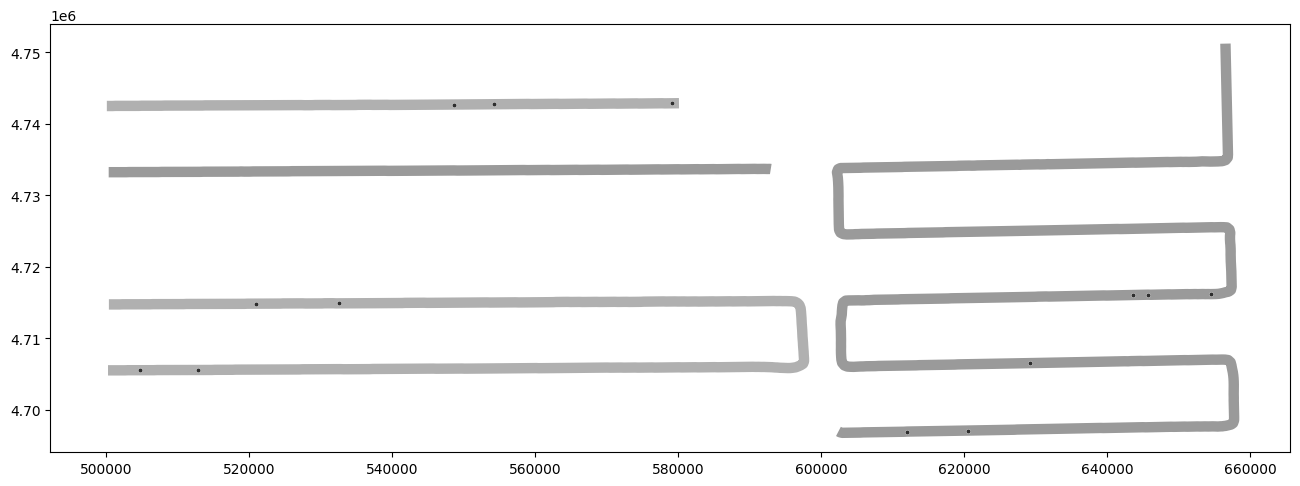

In [15]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_sightings.plot(sections=u_sections)

In [16]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


In [17]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    datetime_format='%Y-%m-%d %H:%M:%S',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00',
    section_id_col='section_id'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


In [18]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sections = Sections.from_datapoints(
    datapoints=u_trackpoints,
    cols={'bss': 'mean', 'season': 'first', 'datetime': 'first'},
    sortby='datetime')

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


In [19]:
u_sections.name

'sections-trackpoints'

In [20]:
u_sections.parameters

{'sections_filepath': './import/trackpoints.csv (via datapoints)',
 'sections_crs': 'EPSG:32619',
 'sections_tz': 'UTC-05:00'}

In [21]:
u_sections.sections

,section_id,geometry,datetime,bss,season
0,s001,"LINESTRING (580092.757 4742883.408, 579997.135...",2019-01-25 10:18:13-05:00,2.398058,winter
1,s002,"LINESTRING (592927.566 4733678.432, 592818.466...",2019-01-30 14:32:57-05:00,3.000000,winter
2,s003,"LINESTRING (500383.195 4714750.316, 500765.569...",2019-03-02 12:43:27-05:00,1.537864,spring
3,s004,"LINESTRING (656499.299 4751214.73, 656509.418 ...",2019-03-05 11:21:16-05:00,1.280872,spring


In [22]:
u_sections.save(
    folder=export_folder, 
    crs_export='EPSG:4326', 
    tz_export='UTC-05:00')

Success: reprojected to CRS "EPSG:4326"
Note: conversion of column "datetime" to timezone "UTC-05:00" not necessary as already in timezone "UTC-05:00".


In [23]:
u_sections = Sections.open(
    export_folder, 
    basename='sections-trackpoints', 
    crs_working='EPSG:32619',
    tz_working='UTC-06:00')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Note: the inherent (contained within the datetimes) timezone of column "datetime" is "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


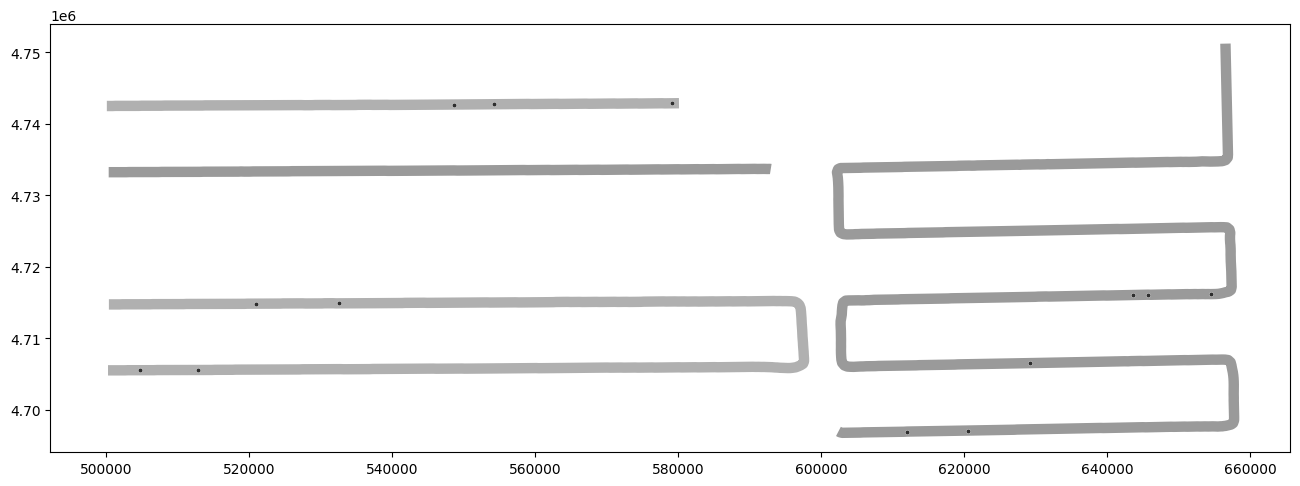

In [24]:
u_sightings = DataPoints.from_file(filepath=import_folder+'sightings.gpkg', crs_working='EPSG:32619')
u_sections.plot(datapoints=u_sightings)

### Periods

#### ```Periods.delimit```

##### Custom extent

In [25]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-03-03 14:32:57'], 'UTC-05:00'),
    unit='day',
    num=8)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-05:00,2019-01-29 00:00:00-05:00,2019-02-01 00:00:00-05:00
1,p2019-02-02-8d,2019-02-02 00:00:00-05:00,2019-02-06 00:00:00-05:00,2019-02-09 00:00:00-05:00
2,p2019-02-10-8d,2019-02-10 00:00:00-05:00,2019-02-14 00:00:00-05:00,2019-02-17 00:00:00-05:00
3,p2019-02-18-8d,2019-02-18 00:00:00-05:00,2019-02-22 00:00:00-05:00,2019-02-25 00:00:00-05:00
4,p2019-02-26-8d,2019-02-26 00:00:00-05:00,2019-03-02 00:00:00-05:00,2019-03-05 00:00:00-05:00


In [26]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-10-03 14:32:57'], 'UTC-05:00'),
    unit='month',
    num=2)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-2m,2019-01-01 00:00:00-05:00,2019-01-30 00:00:00-05:00,2019-02-28 00:00:00-05:00
1,p2019-03-01-2m,2019-03-01 00:00:00-05:00,2019-03-31 00:00:00-05:00,2019-04-30 00:00:00-05:00
2,p2019-05-01-2m,2019-05-01 00:00:00-05:00,2019-05-31 00:00:00-05:00,2019-06-30 00:00:00-05:00
3,p2019-07-01-2m,2019-07-01 00:00:00-05:00,2019-08-01 00:00:00-05:00,2019-08-31 00:00:00-05:00
4,p2019-09-01-2m,2019-09-01 00:00:00-05:00,2019-10-01 00:00:00-05:00,2019-10-31 00:00:00-05:00


In [27]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2023-10-03 14:32:57'], 'UTC-05:00'),
    unit='year',
    num=1)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-1y,2019-01-01 00:00:00-05:00,2019-07-02 00:00:00-05:00,2019-12-31 00:00:00-05:00
1,p2020-01-01-1y,2020-01-01 00:00:00-05:00,2020-07-02 00:00:00-05:00,2020-12-31 00:00:00-05:00
2,p2021-01-01-1y,2021-01-01 00:00:00-05:00,2021-07-02 00:00:00-05:00,2021-12-31 00:00:00-05:00
3,p2022-01-01-1y,2022-01-01 00:00:00-05:00,2022-07-02 00:00:00-05:00,2022-12-31 00:00:00-05:00
4,p2023-01-01-1y,2023-01-01 00:00:00-05:00,2023-07-02 00:00:00-05:00,2023-12-31 00:00:00-05:00


In [28]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-03-03 14:32:57'], None),
    unit='day',
    num=8)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Note: timezone of column "datetime" was not set as no timezone was specified.


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25,2019-01-29,2019-02-01
1,p2019-02-02-8d,2019-02-02,2019-02-06,2019-02-09
2,p2019-02-10-8d,2019-02-10,2019-02-14,2019-02-17
3,p2019-02-18-8d,2019-02-18,2019-02-22,2019-02-25
4,p2019-02-26-8d,2019-02-26,2019-03-02,2019-03-05


In [29]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-10-03 14:32:57'], None),
    unit='month',
    num=2)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Note: timezone of column "datetime" was not set as no timezone was specified.


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-2m,2019-01-01,2019-01-30,2019-02-28
1,p2019-03-01-2m,2019-03-01,2019-03-31,2019-04-30
2,p2019-05-01-2m,2019-05-01,2019-05-31,2019-06-30
3,p2019-07-01-2m,2019-07-01,2019-08-01,2019-08-31
4,p2019-09-01-2m,2019-09-01,2019-10-01,2019-10-31


In [30]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2023-10-03 14:32:57'], None),
    unit='year',
    num=1)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Note: timezone of column "datetime" was not set as no timezone was specified.


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-1y,2019-01-01,2019-07-02,2019-12-31
1,p2020-01-01-1y,2020-01-01,2020-07-02,2020-12-31
2,p2021-01-01-1y,2021-01-01,2021-07-02,2021-12-31
3,p2022-01-01-1y,2022-01-01,2022-07-02,2022-12-31
4,p2023-01-01-1y,2023-01-01,2023-07-02,2023-12-31


##### Extent based on DataPoints

In [31]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00'
)
u_periods = Periods.delimit(
    extent=u_trackpoints,
    unit='day',
    num=8)
u_periods.periods

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"
Success: datapoint IDs generated.


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-06:00,2019-01-29 00:00:00-06:00,2019-02-01 00:00:00-06:00
1,p2019-02-02-8d,2019-02-02 00:00:00-06:00,2019-02-06 00:00:00-06:00,2019-02-09 00:00:00-06:00
2,p2019-02-10-8d,2019-02-10 00:00:00-06:00,2019-02-14 00:00:00-06:00,2019-02-17 00:00:00-06:00
3,p2019-02-18-8d,2019-02-18 00:00:00-06:00,2019-02-22 00:00:00-06:00,2019-02-25 00:00:00-06:00
4,p2019-02-26-8d,2019-02-26 00:00:00-06:00,2019-03-02 00:00:00-06:00,2019-03-05 00:00:00-06:00


##### Extent based on Sections

In [32]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00',
)
u_periods = Periods.delimit(
    extent=u_sections,
    unit='day',
    num=8)
u_periods.periods

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"
Success: section IDs generated.


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-06:00,2019-01-29 00:00:00-06:00,2019-02-01 00:00:00-06:00
1,p2019-02-02-8d,2019-02-02 00:00:00-06:00,2019-02-06 00:00:00-06:00,2019-02-09 00:00:00-06:00
2,p2019-02-10-8d,2019-02-10 00:00:00-06:00,2019-02-14 00:00:00-06:00,2019-02-17 00:00:00-06:00
3,p2019-02-18-8d,2019-02-18 00:00:00-06:00,2019-02-22 00:00:00-06:00,2019-02-25 00:00:00-06:00
4,p2019-02-26-8d,2019-02-26 00:00:00-06:00,2019-03-02 00:00:00-06:00,2019-03-05 00:00:00-06:00


#### Periods attributes

In [33]:
u_periods.name

'periods-8d'

In [34]:
u_periods.parameters

{'periods_tz': 'UTC-06:00',
 'periods_extent': '2019-01-25-2019-03-05',
 'periods_extent_source': 'Sections - sections-sections',
 'periods_number': 8,
 'periods_unit': 'day'}

In [35]:
u_periods.periods

,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-06:00,2019-01-29 00:00:00-06:00,2019-02-01 00:00:00-06:00
1,p2019-02-02-8d,2019-02-02 00:00:00-06:00,2019-02-06 00:00:00-06:00,2019-02-09 00:00:00-06:00
2,p2019-02-10-8d,2019-02-10 00:00:00-06:00,2019-02-14 00:00:00-06:00,2019-02-17 00:00:00-06:00
3,p2019-02-18-8d,2019-02-18 00:00:00-06:00,2019-02-22 00:00:00-06:00,2019-02-25 00:00:00-06:00
4,p2019-02-26-8d,2019-02-26 00:00:00-06:00,2019-03-02 00:00:00-06:00,2019-03-05 00:00:00-06:00


#### ```Periods.save```

In [36]:
u_periods.save(folder=export_folder)

#### ```Periods.open```

In [37]:
u_periods = Periods.open(
    export_folder, 
    basename='periods-8d')  

Success: file opened.
Success: file opened.


### Cells

#### ```Cells.delimit```

##### Custom extent

In [38]:
from pyproj import CRS
u_cells = Cells.delimit(
    extent=([500095.61955057, 4696798.08683991, 657711.42048071, 4751214.73038492], CRS('EPSG:32619')),
    var='hexagonal',
    side=5000)
u_cells.cells

,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


In [39]:
from pyproj import CRS
u_cells = Cells.delimit(
    extent=([500095.61955057, 4696798.08683991, 657711.42048071, 4751214.73038492], CRS('EPSG:32619')),
    var='rectangular',
    side=5000,
    buffer=2000)
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((498095.62 4694798.087, 503095.62 469...",POINT (500595.62 4697298.087)
1,c002-r5000m,"POLYGON ((503095.62 4694798.087, 508095.62 469...",POINT (505595.62 4697298.087)
2,c003-r5000m,"POLYGON ((508095.62 4694798.087, 513095.62 469...",POINT (510595.62 4697298.087)
3,c004-r5000m,"POLYGON ((513095.62 4694798.087, 518095.62 469...",POINT (515595.62 4697298.087)
4,c005-r5000m,"POLYGON ((518095.62 4694798.087, 523095.62 469...",POINT (520595.62 4697298.087)
...,...,...,...
391,c392-r5000m,"POLYGON ((638095.62 4749798.087, 643095.62 474...",POINT (640595.62 4752298.087)
392,c393-r5000m,"POLYGON ((643095.62 4749798.087, 648095.62 474...",POINT (645595.62 4752298.087)
393,c394-r5000m,"POLYGON ((648095.62 4749798.087, 653095.62 474...",POINT (650595.62 4752298.087)
394,c395-r5000m,"POLYGON ((653095.62 4749798.087, 658095.62 474...",POINT (655595.62 4752298.087)


##### Extent based on polygon

In [40]:
import geopandas as gpd  # import geopandas package
study_area = gpd.read_file(import_folder + 'study_area.gpkg')  # import the GeoPackage as a GeoDataFrame
u_cells = Cells.delimit(
    extent=study_area,
    var='hexagonal',
    side=5000)
u_cells.cells

,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


##### Extent based on DataPoints

In [41]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    geometry_col='geometry',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    section_id_col='section_id'
)
u_cells = Cells.delimit(
    extent=u_trackpoints,
    var='hexagonal',
    side=5000)
u_cells.cells

Success: file opened.
Success: geometries parsed.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


##### Extent based on Sections

In [42]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_cells = Cells.delimit(
    extent=u_sections,
    var='hexagonal',
    side=5000)
u_cells.cells

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


##### Extent based on polygon with coarse

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


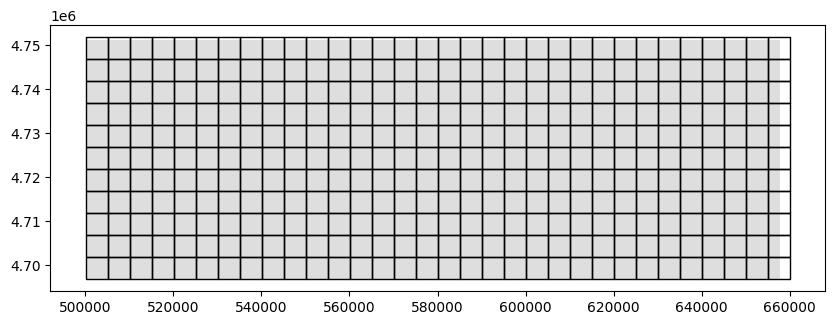

In [43]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    coarse=5,
    select='intersects')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

##### Extent based on polygon with select options

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


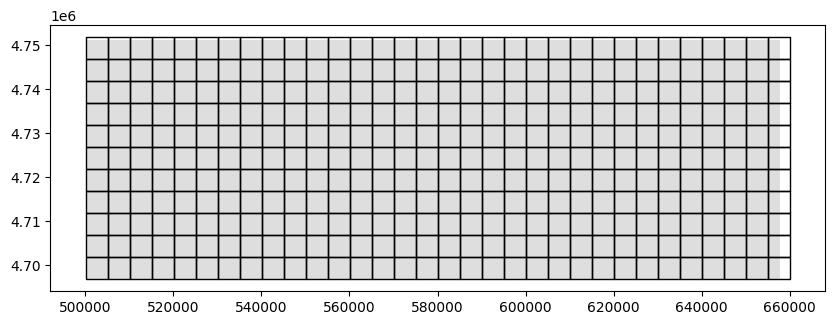

In [44]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    select='intersects')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
305,c306-r5000m,"POLYGON ((630095.62 4741798.087, 635095.62 474...",POINT (632595.62 4744298.087)
306,c307-r5000m,"POLYGON ((635095.62 4741798.087, 640095.62 474...",POINT (637595.62 4744298.087)
307,c308-r5000m,"POLYGON ((640095.62 4741798.087, 645095.62 474...",POINT (642595.62 4744298.087)
308,c309-r5000m,"POLYGON ((645095.62 4741798.087, 650095.62 474...",POINT (647595.62 4744298.087)


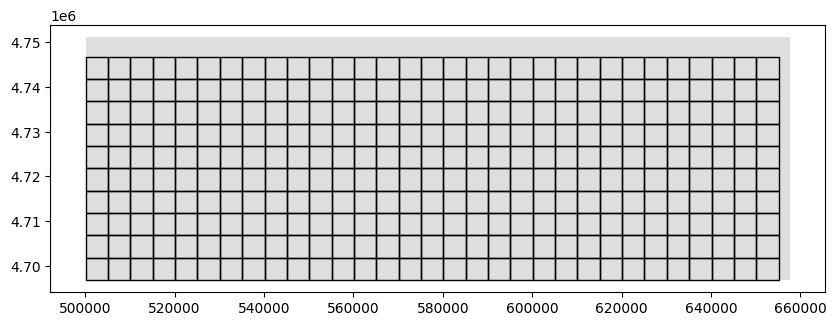

In [45]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    select='within')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


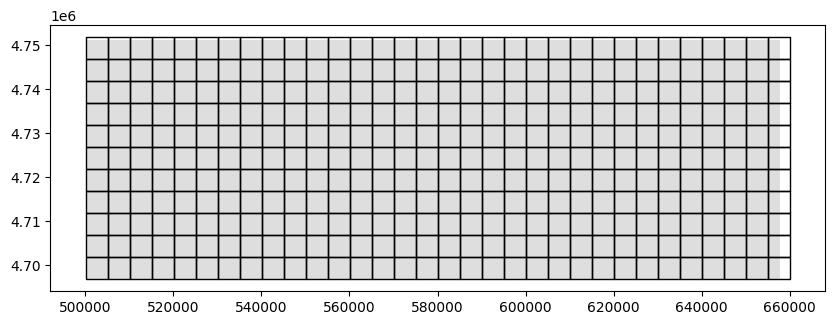

In [46]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    select='centroid')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

#### Cells attributes

In [47]:
u_cells.name

'cells-r5000m'

In [48]:
u_cells.parameters

{'cells_crs': 'EPSG:32619',
 'cells_extent': '500095.6195505685, 4696798.086839909, 660095.6195505685, 4751798.086839909',
 'cells_extent_source': 'GeoDataFrame',
 'cells_var': 'rectangular',
 'cells_side': 5000,
 'cells_unit': 'metre',
 'cells_buffer': None}

In [49]:
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


#### ```Cells.save```

In [50]:
u_cells.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: additional geometry column "centroid" reprojected to CRS "EPSG:4326"
Success: reprojected to CRS "EPSG:4326"


#### ```Cells.open```

In [52]:
u_cells = Cells.open(
    export_folder, 
    basename='cells-r5000m', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: file opened.
Success: additional geometry column "centroid" reprojected to CRS "EPSG:32619"
Success: reprojected to CRS "EPSG:32619"


#### ```Cells.plot```

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


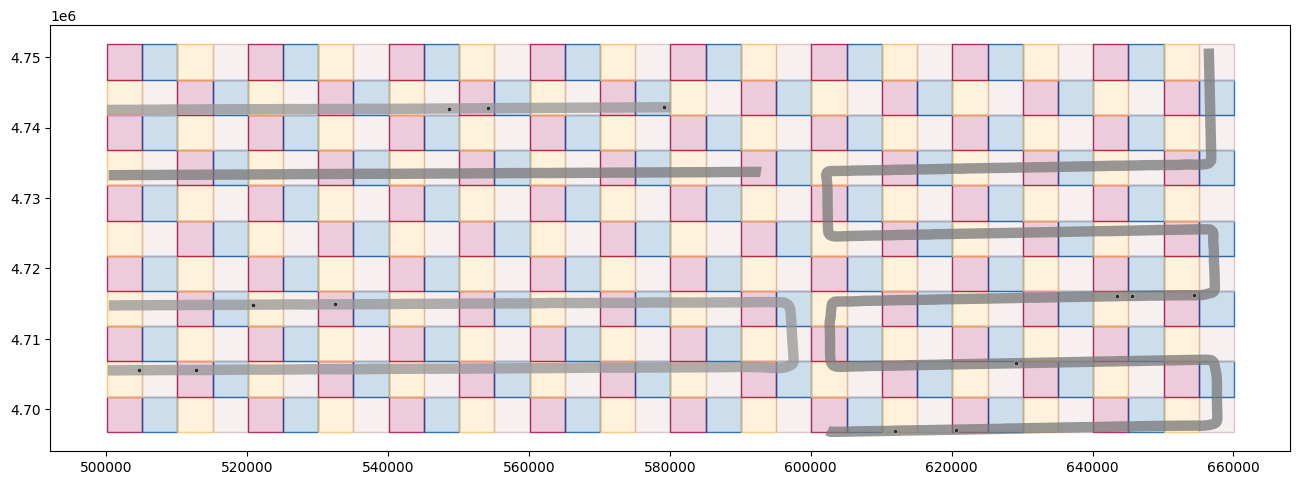

In [54]:
u_sightings = DataPoints.from_file(filepath=import_folder+'sightings.gpkg', crs_working='EPSG:32619')
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_cells.plot(datapoints=u_sightings, sections=u_sections)

### Segments

#### ```Segments.delimit```

##### Simple variation - not randomised

In [55]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='simple',
    target=10000)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-s10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.311 4742845.962),None,s1,0.0,10000.000000
1,s02-s10000m,"LINESTRING (570094.222 4742829.916, 569917.081...",POINT (565094.73 4742799.725),None,s1,10000.0,20000.000000
2,s03-s10000m,"LINESTRING (560095.148 4742773.163, 559864.339...",POINT (555095.521 4742749.119),None,s1,20000.0,30000.000000
3,s04-s10000m,"LINESTRING (550095.667 4742710.935, 549838.842...",POINT (545095.787 4742676.383),None,s1,30000.0,40000.000000
4,s05-s10000m,"LINESTRING (540095.882 4742645.456, 539704.822...",POINT (535096.832 4742648.569),None,s1,40000.0,50000.000000
...,...,...,...,...,...,...,...
68,s69-s10000m,"LINESTRING (646445.51 4697592.665, 646369.277 ...",POINT (641446.66 4697508.557),None,s4,280000.0,290000.000000
69,s70-s10000m,"LINESTRING (636447.691 4697428.025, 636124.889...",POINT (631448.609 4697332.185),None,s4,290000.0,300000.000000
70,s71-s10000m,"LINESTRING (626450.303 4697221.055, 626265.927...",POINT (621451.09 4697132.369),None,s4,300000.0,310000.000000
71,s72-s10000m,"LINESTRING (616451.814 4697047.259, 616228.106...",POINT (611453.214 4696946.859),None,s4,310000.0,320000.000000


##### Simple variation - randomised

In [56]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='simple',
    target=10000,
    rand=True)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-s10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.311 4742845.962),None,s1,0.000000,10000.000000
1,s02-s10000m,"LINESTRING (570094.222 4742829.916, 569917.081...",POINT (565094.73 4742799.725),None,s1,10000.000000,20000.000000
2,s03-s10000m,"LINESTRING (560095.148 4742773.163, 559864.339...",POINT (555095.521 4742749.119),None,s1,20000.000000,30000.000000
3,s04-s10000m,"LINESTRING (550095.667 4742710.935, 549838.842...",POINT (545095.787 4742676.383),None,s1,30000.000000,40000.000000
4,s05-s10000m,"LINESTRING (540095.882 4742645.456, 539704.822...",POINT (535096.832 4742648.569),None,s1,40000.000000,50000.000000
...,...,...,...,...,...,...,...
68,s69-s10000m,"LINESTRING (652338.76 4697682.02, 652197.878 4...",POINT (647339.987 4697611.472),None,s4,274105.324868,284105.324868
69,s70-s10000m,"LINESTRING (642341.15 4697526.723, 641994.147 ...",POINT (637342.194 4697445.552),None,s4,284105.324868,294105.324868
70,s71-s10000m,"LINESTRING (632343.125 4697349.07, 632326.134 ...",POINT (627344.065 4697254.461),None,s4,294105.324868,304105.324868
71,s72-s10000m,"LINESTRING (622345.629 4697147.973, 622000.67 ...",POINT (617346.364 4697062.225),None,s4,304105.324868,314105.324868


##### Joining variation

In [57]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='joining',
    target=10000,
    rand=True)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-j10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.311 4742845.962),None,s1,0.000000,10000.000000
1,s02-j10000m,"LINESTRING (570094.222 4742829.916, 569917.081...",POINT (565094.73 4742799.725),None,s1,10000.000000,20000.000000
2,s03-j10000m,"LINESTRING (560095.148 4742773.163, 559864.339...",POINT (555095.521 4742749.119),None,s1,20000.000000,30000.000000
3,s04-j10000m,"LINESTRING (550095.667 4742710.935, 549838.842...",POINT (545095.787 4742676.383),None,s1,30000.000000,40000.000000
4,s05-j10000m,"LINESTRING (540095.882 4742645.456, 539704.822...",POINT (535094.514 4742648.446),None,s1,40000.000000,50004.642260
...,...,...,...,...,...,...,...
64,s65-j10000m,"LINESTRING (652338.76 4697682.02, 652197.878 4...",POINT (647339.987 4697611.472),None,s4,274105.324868,284105.324868
65,s66-j10000m,"LINESTRING (642341.15 4697526.723, 641994.147 ...",POINT (637342.194 4697445.552),None,s4,284105.324868,294105.324868
66,s67-j10000m,"LINESTRING (632343.125 4697349.07, 632326.134 ...",POINT (627344.065 4697254.461),None,s4,294105.324868,304105.324868
67,s68-j10000m,"LINESTRING (622345.629 4697147.973, 622000.67 ...",POINT (617346.364 4697062.225),None,s4,304105.324868,314105.324868


##### Redistribution variation

In [58]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='redistribution',
    target=10000)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),None,s1,0.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),None,s1,10000.580283,20001.160565
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),None,s1,20001.160565,30001.740848
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),None,s1,30001.740848,40002.321130
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),None,s1,40002.321130,50002.901413
...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),None,s4,273463.867857,283592.159259
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),None,s4,283592.159259,293720.450662
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),None,s4,293720.450662,303848.742064
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),None,s4,303848.742064,313977.033466


#### ```Segments.datetimes```

In [59]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sections = Sections.from_datapoints(datapoints=u_trackpoints)
u_segments = Segments.delimit(
    sections=u_sections,
    var='redistribution',
    target=10000)
u_segments.datetimes(datapoints=u_trackpoints)
u_segments.segments

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


,segment_id,line,midpoint,date,datetime_beg,datetime_mid,datetime_end,section_id,dfbsec_beg,dfbsec_end
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),2019-01-25,2019-01-25 10:18:13-05:00,2019-01-25 10:19:55-05:00,2019-01-25 10:21:38-05:00,s001,0.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),2019-01-25,2019-01-25 10:21:38-05:00,2019-01-25 10:23:17-05:00,2019-01-25 10:24:57-05:00,s001,10000.580283,20001.160565
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),2019-01-25,2019-01-25 10:24:57-05:00,2019-01-25 10:26:37-05:00,2019-01-25 10:28:17-05:00,s001,20001.160565,30001.740848
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),2019-01-25,2019-01-25 10:28:17-05:00,2019-01-25 10:29:56-05:00,2019-01-25 10:31:35-05:00,s001,30001.740848,40002.321130
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),2019-01-25,2019-01-25 10:31:35-05:00,2019-01-25 10:33:14-05:00,2019-01-25 10:34:53-05:00,s001,40002.321130,50002.901413
...,...,...,...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),2019-03-05,2019-03-05 12:51:07-05:00,2019-03-05 12:52:58-05:00,2019-03-05 12:54:50-05:00,s004,273463.867857,283592.159259
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),2019-03-05,2019-03-05 12:54:50-05:00,2019-03-05 12:56:39-05:00,2019-03-05 12:58:29-05:00,s004,283592.159259,293720.450662
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),2019-03-05,2019-03-05 12:58:29-05:00,2019-03-05 13:00:21-05:00,2019-03-05 13:02:14-05:00,s004,293720.450662,303848.742064
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),2019-03-05,2019-03-05 13:02:14-05:00,2019-03-05 13:04:07-05:00,2019-03-05 13:06:00-05:00,s004,303848.742064,313977.033466


#### Segments attributes

In [60]:
u_segments.name

'segments-r10000m'

In [61]:
u_segments.parameters

{'sections_name': 'sections-trackpoints',
 'segments_crs': 'EPSG:32619',
 'segments_var': 'redistribution',
 'segments_rand': False,
 'segments_target': 10000,
 'segments_unit': 'metre'}

In [62]:
u_segments.segments

,segment_id,line,midpoint,date,datetime_beg,datetime_mid,datetime_end,section_id,dfbsec_beg,dfbsec_end
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),2019-01-25,2019-01-25 10:18:13-05:00,2019-01-25 10:19:55-05:00,2019-01-25 10:21:38-05:00,s001,0.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),2019-01-25,2019-01-25 10:21:38-05:00,2019-01-25 10:23:17-05:00,2019-01-25 10:24:57-05:00,s001,10000.580283,20001.160565
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),2019-01-25,2019-01-25 10:24:57-05:00,2019-01-25 10:26:37-05:00,2019-01-25 10:28:17-05:00,s001,20001.160565,30001.740848
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),2019-01-25,2019-01-25 10:28:17-05:00,2019-01-25 10:29:56-05:00,2019-01-25 10:31:35-05:00,s001,30001.740848,40002.321130
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),2019-01-25,2019-01-25 10:31:35-05:00,2019-01-25 10:33:14-05:00,2019-01-25 10:34:53-05:00,s001,40002.321130,50002.901413
...,...,...,...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),2019-03-05,2019-03-05 12:51:07-05:00,2019-03-05 12:52:58-05:00,2019-03-05 12:54:50-05:00,s004,273463.867857,283592.159259
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),2019-03-05,2019-03-05 12:54:50-05:00,2019-03-05 12:56:39-05:00,2019-03-05 12:58:29-05:00,s004,283592.159259,293720.450662
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),2019-03-05,2019-03-05 12:58:29-05:00,2019-03-05 13:00:21-05:00,2019-03-05 13:02:14-05:00,s004,293720.450662,303848.742064
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),2019-03-05,2019-03-05 13:02:14-05:00,2019-03-05 13:04:07-05:00,2019-03-05 13:06:00-05:00,s004,303848.742064,313977.033466


#### ```Segments.save```

In [63]:
u_segments.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: additional geometry column "midpoint" reprojected to CRS "EPSG:4326"
Success: reprojected to CRS "EPSG:4326"


#### ```Segments.open```

In [64]:
u_segments = Segments.open(
    export_folder, 
    basename='segments-r10000m', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: file opened.
Success: additional geometry column "midpoint" reprojected to CRS "EPSG:32619"
Success: reprojected to CRS "EPSG:32619"


#### ```Segments.plot```

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


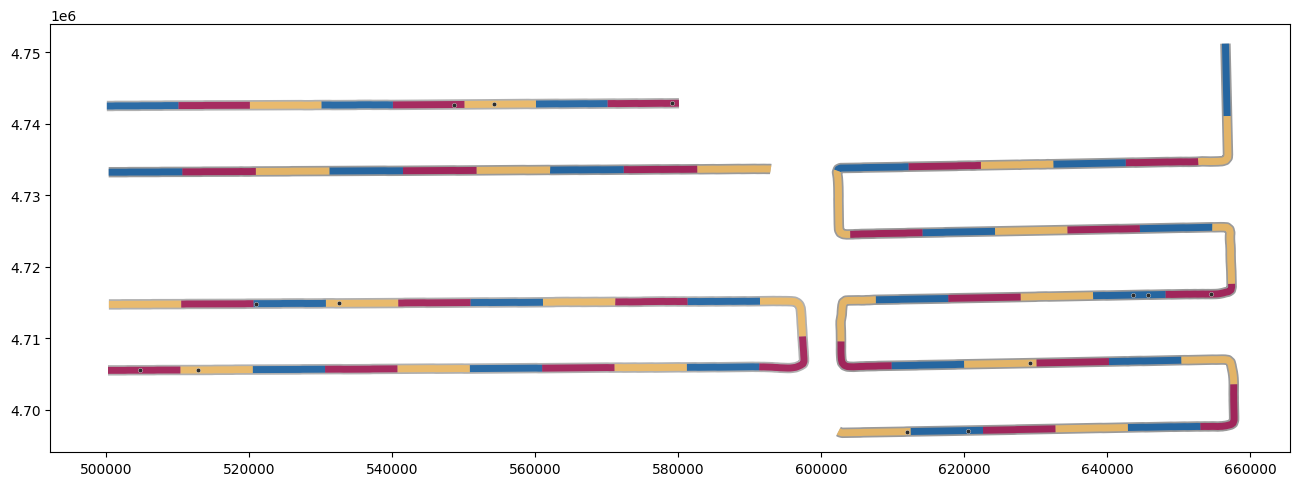

In [65]:
u_sightings = DataPoints.from_file(filepath=import_folder+'sightings.gpkg', crs_working='EPSG:32619')
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments.plot(datapoints=u_sightings, sections=u_sections)

### Presences

#### ```Presences.delimit```

In [66]:
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals')
u_presences.presences

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


,point_id,point,date,datapoint_id
0,p01,POINT (579166.78 4742872.701),2019-01-25,d01
1,p02,POINT (554184.217 4742741.886),2019-01-25,d02
2,p03,POINT (548599.876 4742700.214),2019-01-25,d03
3,p04,POINT (520909.741 4714855.058),2019-03-02,d04
4,p05,POINT (532548.249 4714899.835),2019-03-02,d05
5,p06,POINT (512817.407 4705582.465),2019-03-02,d06
6,p07,POINT (504710.41 4705553.392),2019-03-02,d07
7,p08,POINT (654449.136 4716189.584),2019-03-05,d08
8,p09,POINT (645666.237 4716110.937),2019-03-05,d09
9,p10,POINT (643532.681 4716066.52),2019-03-05,d10


In [67]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals',
    block='season')
u_presences.presences

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


,point_id,point,date,datapoint_id,season
0,p01,POINT (579166.78 4742872.701),2019-01-25,d01,winter
1,p02,POINT (554184.217 4742741.886),2019-01-25,d02,winter
2,p03,POINT (548599.876 4742700.214),2019-01-25,d03,winter
3,p04,POINT (520909.741 4714855.058),2019-03-02,d04,spring
4,p05,POINT (532548.249 4714899.835),2019-03-02,d05,spring
5,p06,POINT (512817.407 4705582.465),2019-03-02,d06,spring
6,p07,POINT (504710.41 4705553.392),2019-03-02,d07,spring
7,p08,POINT (654449.136 4716189.584),2019-03-05,d08,spring
8,p09,POINT (645666.237 4716110.937),2019-03-05,d09,spring
9,p10,POINT (643532.681 4716066.52),2019-03-05,d10,spring


#### Presences attributes

In [68]:
u_presences.name

'presences-sightings'

In [69]:
u_presences.parameters

{'presences_crs': 'EPSG:32619'}

In [70]:
u_presences.presences

,point_id,point,date,datapoint_id,season
0,p01,POINT (579166.78 4742872.701),2019-01-25,d01,winter
1,p02,POINT (554184.217 4742741.886),2019-01-25,d02,winter
2,p03,POINT (548599.876 4742700.214),2019-01-25,d03,winter
3,p04,POINT (520909.741 4714855.058),2019-03-02,d04,spring
4,p05,POINT (532548.249 4714899.835),2019-03-02,d05,spring
5,p06,POINT (512817.407 4705582.465),2019-03-02,d06,spring
6,p07,POINT (504710.41 4705553.392),2019-03-02,d07,spring
7,p08,POINT (654449.136 4716189.584),2019-03-05,d08,spring
8,p09,POINT (645666.237 4716110.937),2019-03-05,d09,spring
9,p10,POINT (643532.681 4716066.52),2019-03-05,d10,spring


#### ```Presences.save```

In [71]:
u_presences.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: reprojected to CRS "EPSG:4326"


#### ```Presences.open```

In [72]:
u_presences = Presences.open(
    export_folder, 
    basename='presences-sightings', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"


#### ```Presences.plot```

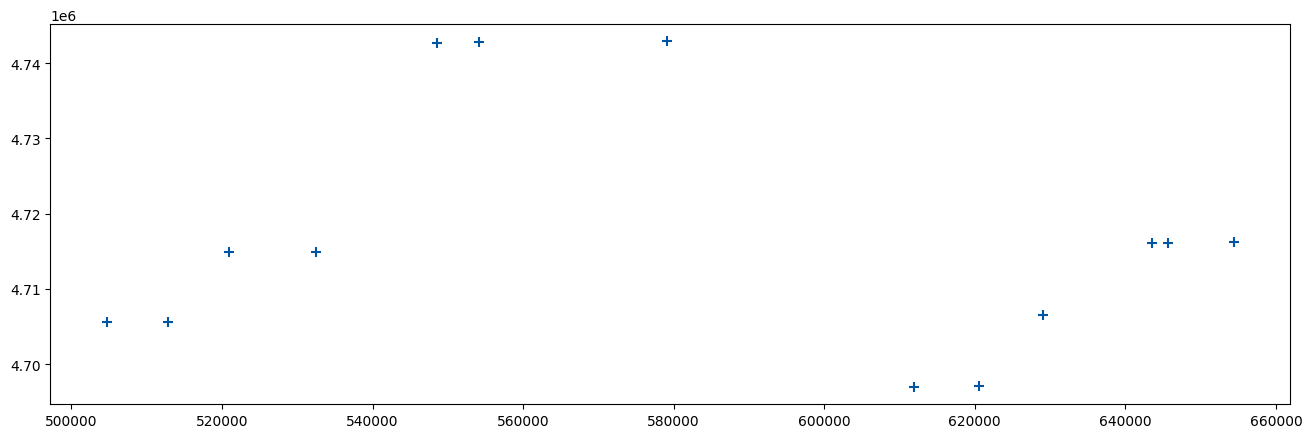

In [73]:
u_presences.plot()

### PresenceZones

#### ```PresenceZones.delimit```

##### Setup

In [74]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals')

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


##### Without temporal threshold

In [75]:
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000
)
u_presencezones.presencezones

,section_id,presencezones
0,all,"MULTIPOLYGON (((506661.313 4695745.539, 505690..."


##### With temporal threshold

In [76]:
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000,
    tm_threshold=0,
    tm_unit='day',
)
u_presencezones.presencezones

,section_id,presencezones
0,s001,"MULTIPOLYGON (((550550.779 4732892.362, 549580..."
1,s002,None
2,s003,"POLYGON ((507613.256 4695983.989, 506661.313 4..."
3,s004,"POLYGON ((614879.704 4687404.708, 613927.76 46..."


#### PresenceZones attributes

In [77]:
u_presencezones.name

'presencezones-10000m-0day'

In [78]:
u_presencezones.parameters

{'presencezones_crs': 'EPSG:32619',
 'presencezones_sp_threshold': 10000,
 'presencezones_tm_threshold': 0,
 'presencezones_tm_unit': 'day'}

In [79]:
u_presencezones.presencezones

,section_id,presencezones
0,s001,"MULTIPOLYGON (((550550.779 4732892.362, 549580..."
1,s002,None
2,s003,"POLYGON ((507613.256 4695983.989, 506661.313 4..."
3,s004,"POLYGON ((614879.704 4687404.708, 613927.76 46..."


#### ```PresenceZones.save```

In [80]:
u_presencezones.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: reprojected to CRS "EPSG:4326"


#### ```PresenceZones.open```

In [83]:
u_presencezones = PresenceZones.open(
    export_folder, 
    basename='presencezones-10000m-0day', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"


#### ```PresenceZones.plot```

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


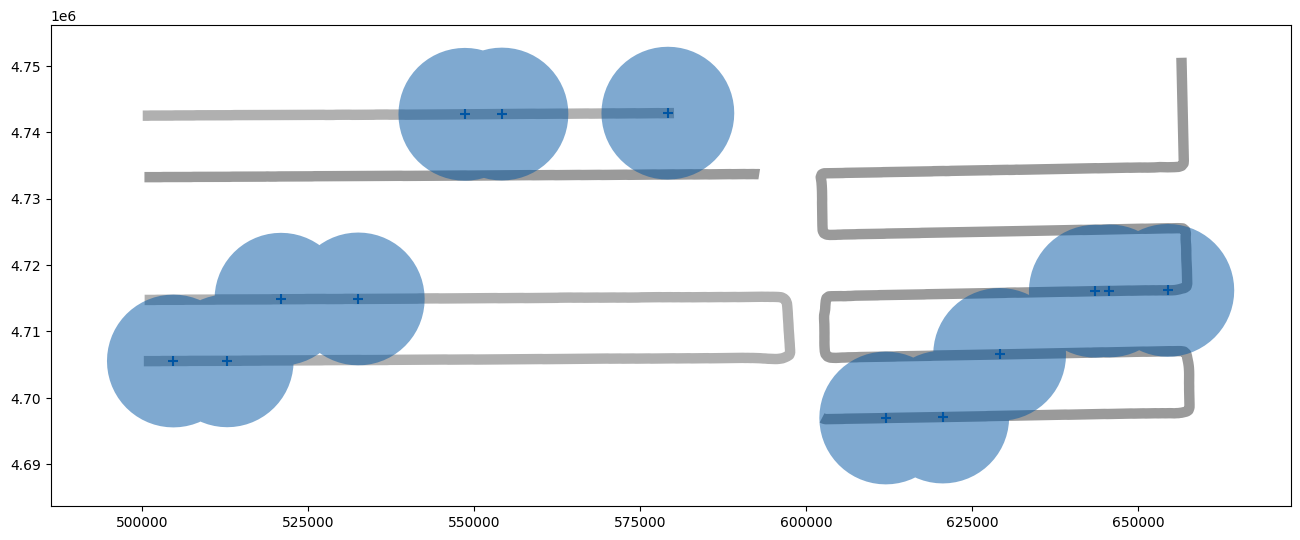

In [84]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_presencezones.plot(sections=u_sections, presences=u_presences)

### Absences

#### ```Absences.delimit```

##### Setup

In [85]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sections = Sections.from_datapoints(
    datapoints=u_trackpoints,
    cols={'season': 'first'})
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals',
    block='season')
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000,
    tm_threshold=0,
    tm_unit='day'
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


##### Along-the-line variation

###### Without blocks

In [86]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=20,
    limit=2)
u_absences.absences

Target: 20 | Attempts: 28 | Successes: 20


,point_id,point,date,section_id,dfbs
0,a01,POINT (564494.988 4742794.082),2019-01-25,s001,15599.768860
1,a02,POINT (523288.592 4742605.87),2019-01-25,s001,56809.894674
2,a03,POINT (505498.128 4742530.935),2019-01-25,s001,74601.282102
3,a04,POINT (583645.414 4733651.969),2019-01-30,s002,89289.606658
4,a05,POINT (563174.956 4733545.452),2019-01-30,s002,109762.298992
5,a06,POINT (558500.862 4733538.296),2019-01-30,s002,114436.988269
6,a07,POINT (524676.008 4733356.14),2019-01-30,s002,148263.595981
7,a08,POINT (568770.345 4715100.629),2019-03-02,s003,240982.477712
8,a09,POINT (594920.639 4705867.802),2019-03-02,s003,280247.974154
9,a10,POINT (593666.392 4705932.586),2019-03-02,s003,281504.369578


###### With blocks, ```how='target'```

In [87]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=5,
    block='season',
    how='target')
u_absences.absences


Block: winter
Target: 5 | Attempts: 6 | Successes: 5

Block: spring
Target: 5 | Attempts: 5 | Successes: 5


,point_id,point,date,section_id,dfbs,season
0,a01,POINT (566165.911 4742809.934),2019-01-25,s001,13928.770017,winter
1,a02,POINT (591258.62 4733692.835),2019-01-30,s002,81675.232229,winter
2,a03,POINT (590818.862 4733699.55),2019-01-30,s002,82115.173606,winter
3,a04,POINT (548577.622 4733482.888),2019-01-30,s002,124360.815074,winter
4,a05,POINT (522164.569 4733347.624),2019-01-30,s002,150775.049790,winter
5,a06,POINT (556084.679 4715032.205),2019-03-02,s003,55706.928776,spring
6,a07,POINT (538600.991 4705733.125),2019-03-02,s003,163989.642701,spring
7,a08,POINT (647634.56 4734650.118),2019-03-05,s004,227641.979017,spring
8,a09,POINT (629944.525 4725074.51),2019-03-05,s004,309274.431825,spring
9,a10,POINT (657677.086 4700524.609),2019-03-05,s004,468722.356668,spring


###### With blocks, ```how='average'```

In [88]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=10,
    block='season',
    how='average')
u_absences.absences


Block: winter
Target: 5 | Attempts: 5 | Successes: 5

Block: spring
Target: 5 | Attempts: 7 | Successes: 5


,point_id,point,date,section_id,dfbs,season
0,a01,POINT (524532.809 4742610.188),2019-01-25,s001,55565.669695,winter
1,a02,POINT (515212.52 4742583.296),2019-01-25,s001,64885.998528,winter
2,a03,POINT (572673.993 4733602.223),2019-01-30,s002,100262.436072,winter
3,a04,POINT (569487 4733569.425),2019-01-30,s002,103449.597350,winter
4,a05,POINT (502812.968 4733239.494),2019-01-30,s002,170129.220543,winter
5,a06,POINT (550836.217 4705775.008),2019-03-02,s003,151753.524008,spring
6,a07,POINT (656515.934 4750484.449),2019-03-05,s004,203063.889367,spring
7,a08,POINT (618048.523 4734098.777),2019-03-05,s004,257237.709011,spring
8,a09,POINT (617969.86 4734097.433),2019-03-05,s004,257316.383606,spring
9,a10,POINT (617348.686 4734086.848),2019-03-05,s004,257937.648107,spring


###### With blocks, ```how='effort'```

In [89]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=100,
    block='season',
    how='effort')
lengths = u_sections.sections.copy()
lengths['length'] = lengths.length
lengths = lengths.groupby('season').agg({'length': 'sum'})
lengths['length_percentage'] = lengths['length'] / sum(lengths['length']) * 100
print('\n', lengths['length_percentage'], '\n')
u_absences.absences


Block: winter
Target: 25 | Attempts: 27 | Successes: 25

Block: spring
Target: 76 | Attempts: 115 | Successes: 76

 season
spring    75.310261
winter    24.689739
Name: length_percentage, dtype: float64 



,point_id,point,date,section_id,dfbs,season
0,a001,POINT (537918.266 4742652.001),2019-01-25,s001,42177.979080,winter
1,a002,POINT (536414.745 4742662.765),2019-01-25,s001,43681.856203,winter
2,a003,POINT (536067.473 4742660.936),2019-01-25,s001,44029.132416,winter
3,a004,POINT (535910.971 4742660.12),2019-01-25,s001,44185.636375,winter
4,a005,POINT (535690.297 4742658.971),2019-01-25,s001,44406.314143,winter
...,...,...,...,...,...,...
96,a097,POINT (657017.763 4697887.49),2019-03-05,s004,471739.165211,spring
97,a098,POINT (654542.636 4697693.762),2019-03-05,s004,474234.323806,spring
98,a099,POINT (654203.383 4697686.264),2019-03-05,s004,474573.660031,spring
99,a100,POINT (645878.835 4697580.809),2019-03-05,s004,482900.216884,spring


###### With blocks, ```how='presences'```

In [90]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=2,
    block='season',
    how='presences',
    presences=u_presences)
print('\n', u_presences.presences['season'].value_counts(), '\n')
u_absences.absences


Block: winter
Target: 6 | Attempts: 7 | Successes: 6

Block: spring
Target: 20 | Attempts: 32 | Successes: 20

 season
spring    10
winter     3
Name: count, dtype: int64 



,point_id,point,date,section_id,dfbs,season
0,a01,POINT (536273.807 4742662.023),2019-01-25,s001,43822.795496,winter
1,a02,POINT (528121.905 4742605.029),2019-01-25,s001,51976.171900,winter
2,a03,POINT (585558.137 4733657.628),2019-01-30,s002,87376.608425,winter
3,a04,POINT (572406.491 4733599.41),2019-01-30,s002,100529.952890,winter
4,a05,POINT (534787.593 4733418.544),2019-01-30,s002,138151.411513,winter
5,a06,POINT (533740.505 4733413.352),2019-01-30,s002,139198.511504,winter
6,a07,POINT (593026.757 4715224.321),2019-03-02,s003,92655.310879,spring
7,a08,POINT (595131.812 4715210.627),2019-03-02,s003,94760.984281,spring
8,a09,POINT (583566.186 4705960.761),2019-03-02,s003,119020.161022,spring
9,a10,POINT (548530.71 4705776.333),2019-03-02,s003,154059.406448,spring


##### From-the-line variation

In [91]:
from sampley.functions import generate_dfls
from math import exp
def detection_func(x): return exp((-x**2) / (2*500**2))
number = 100000
esw = 2000
interval = 1
dfls = generate_dfls(number=number, esw=esw, interval=interval, dfunc=detection_func)
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='from',
    target=20,
    dfls=dfls)

Target: 20 | Attempts: 25 | Successes: 20


###### Additional test of distribution of distances from the line

Target: 10000 | Attempts: 14919 | Successes: 10000


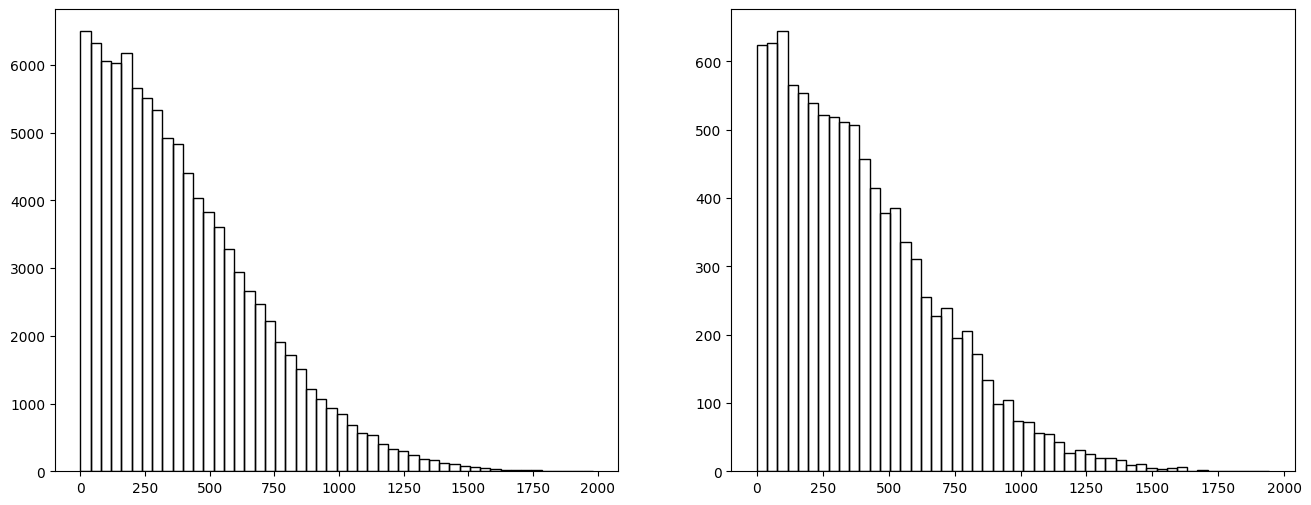

In [92]:
import matplotlib.pyplot as plt
dfls_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='from',
    target=10000,
    dfls=dfls).absences.distance(u_sections.sections.dissolve().geometry[0])
fig, ax = plt.subplots(figsize=(16, 6), ncols=2)
ax[0].hist(dfls, bins=50, facecolor='none', edgecolor='black');
ax[1].hist(dfls_absences, bins=50, facecolor='none', edgecolor='black');

#### Absences attributes

In [93]:
u_absences.name

'absences-fs-10000m-0day'

In [94]:
u_absences.parameters

{'absences_var': 'from',
 'absences_target': 20,
 'presencezones_crs': 'EPSG:32619',
 'presencezones_sp_threshold': 10000,
 'presencezones_tm_threshold': 0,
 'presencezones_tm_unit': 'day'}

In [95]:
u_absences.absences

,point_id,point,date,section_id,dfbs,point_al
0,a01,POINT (580572.957 4732930.274),2019-01-30,s002,92370.665884,POINT (580564.7415217689 4733634.226481636)
1,a02,POINT (580214.339 4734670.744),2019-01-30,s002,92752.430371,POINT (580183.1003570489 4733640.217643569)
2,a03,POINT (570482.26 4733119.484),2019-01-30,s002,102458.975386,POINT (570477.571491954 4733579.460322583)
3,a04,POINT (554523.303 4733694.501),2019-01-30,s002,118413.264166,POINT (554524.7590169455 4733509.5062997565)
4,a05,POINT (505613.424 4733753.823),2019-01-30,s002,167327.993330,POINT (505613.81706692796 4733258.8226984395)
5,a06,POINT (584202.224 4715004.278),2019-03-02,s003,256415.358824,POINT (584200.2482376593 4715167.266486259)
6,a07,POINT (597075.096 4708002.424),2019-03-02,s003,276006.922874,POINT (597520.672064865 4708021.858035013)
7,a08,POINT (570597.435 4706102.469),2019-03-02,s003,304576.804655,POINT (570599.3922275376 4705909.479063264)
8,a09,POINT (568763.737 4705608.984),2019-03-02,s003,306415.792407,POINT (568760.770091593 4705909.969352817)
9,a10,POINT (567436.901 4705798.023),2019-03-02,s003,307740.684839,POINT (567435.940961092 4705897.018399759)


#### ```Absences.save```

In [96]:
u_absences.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: reprojected to CRS "EPSG:4326"


#### ```Absences.open```

In [97]:
u_absences = Absences.open(
    export_folder, 
    basename='absences-fs-10000m-0day', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"


#### ```Absences.plot```

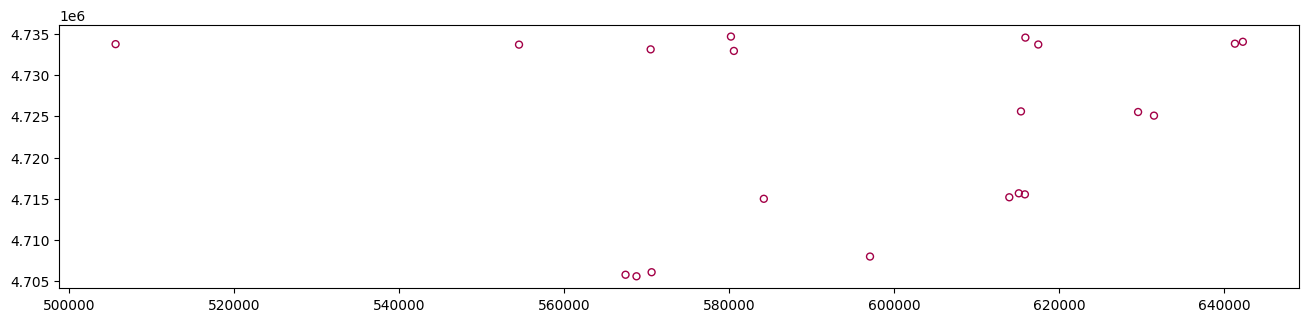

In [98]:
u_absences.plot()